# 02 - Anomaly Type Classification (Step 2)

**Purpose:** this notebook produces falsifiable, testable criteria for what a
point, contextual, and collective/temporal anomaly should look like in each
of the three µEMA sensor channels (`pressure`, `precipitation`,
`luminous_intensity`) — it is **not** a final classification of any actual
anomaly. No emergency-alert or other label data exists for this project (see
recap below), so there is nothing to validate a verdict against yet. Instead,
each criterion below is written as an explicit prediction of the form "a
point-only method (Z-score) should catch cases where X, and should *not* be
the one catching cases where Y" — falsifiable once the five detectors (Step 6,
not built yet) are run and their actual agreement/disagreement patterns can be
checked against these predictions in Step 7. The illustrative episodes pulled
from raw data later in this notebook are provisional examples of the
criteria, for intuition only — not proof the criteria are correct.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from uema.audit import build_coverage_table, station_recommendation
from uema.io import discover_raw_files
from uema.silver import analysis_stations, consolidate_stations, fill_gaps
from uema.style import PALETTE, PALETTE_ORDER, apply_style, pretty_label

apply_style()

pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 100)

REPORT_DIR = Path("..") / "reports" / "data_audit"
CORR_DIR = Path("..") / "reports" / "variable_correlation"


## Recap — scope and feature strategy from Steps 0-1

Pulled from the saved Step 0/1 outputs, not recomputed here.


In [2]:
recommendation = pd.read_csv(REPORT_DIR / "station_recommendation.csv", index_col="station")
recommendation[["decision", "rationale", "joint_span_days"]]


,decision,rationale,joint_span_days
station,,,
recinto-esparza,GO,all sensors within coverage thresholds over the joint window,632.375000
recinto-guapiles,NO-GO,joint sensor overlap under 90 days — insufficient history to use,0.118056
recinto-santa-cruz,CONDITIONAL-GO,"usable with caveats on: pressure, luminous_intensity",611.291667
sede-atlantico_turrialba,GO,all sensors within coverage thresholds over the joint window,681.513889
sede-caribe_limon,CONDITIONAL-GO,"usable with caveats on: pressure, luminous_intensity",269.451389
sede-central_finca-1,GO,all sensors within coverage thresholds over the joint window,280.263889
sede-central_finca-2,CONDITIONAL-GO,"usable with caveats on: pressure, luminous_intensity",447.284722
sede-central_finca-3,CONDITIONAL-GO,"usable with caveats on: pressure, precipitation, luminous_intensity",611.326389
sede-central_losic-norte-1,CONDITIONAL-GO,"all sensors clean, but thin coverage for season(s): dry (<30d) — caution with seasonal conditioning",130.201389


**Step 0 go/no-go** (`reports/data_audit/README.md`, `station_recommendation.csv`):

- **NO-GO** (1): `recinto-guapiles` (sensors barely overlap — 0.1 days joint
  window).
- **GO** (3): `recinto-esparza`, `sede-atlantico_turrialba`,
  `sede-central_finca-1`.
- **CONDITIONAL-GO** (9, still in scope, used over full — sometimes gappy —
  joint span, no rescue-window clipping): `recinto-santa-cruz`,
  `sede-caribe_limon`, `sede-central_finca-2`, `sede-central_finca-3`,
  `sede-central_losic-norte-1`, `sede-central_losic-norte-2`,
  `sede-central_sabanilla`, `sede-guanacaste_liberia`, `sede-sur_golfito`.

12 of 13 stations are in scope here, via `uema.silver.analysis_stations` —
same as Step 1, no station list hardcoded.

**Step 1 feature-strategy conclusion** (`reports/variable_correlation/README.md`):
global (lag-0) correlation stays small everywhere (`|r| <= 0.14` for the
primary statistic, every station x pair) — treat the three sensors as
**independent, per-sensor series by default**. Two conditional exceptions
carried forward into the criteria below:

1. `pressure`-`luminous_intensity` has a lagged inverse coupling
   (`r = -0.24` to `-0.43`, peaking 3.3-4.5h lag) at the 5 stations under 5%
   post-fill missing, but mostly a weak/inconsistent/sign-flipped peak above
   ~11% missing — with one exception (`sede-caribe_limon`, `r = -0.28` at
   20.7% missing) retaining a peak as strong as the cleanest stations, so
   completeness alone doesn't fully gate this coupling's usability.
2. `precipitation`-`luminous_intensity` strengthens specifically during
   daylight hours (`r` -0.10 to -0.26 daytime vs `|r| <= 0.08` at night) at
   **all 12** in-scope stations regardless of completeness — the more robust
   of the two conditional effects.

**No label data exists in this project** — confirmed by searching `data/`
for any alert/label file; none found. This notebook's job is therefore
prediction, not verification.

---

## Anomaly-type criteria, per variable

Each block below states, per anomaly type, the concrete condition a
detector in that family should plausibly catch — phrased so it can be
checked later against real Step 6/7 detector output. "Point-only method"
below stands in for Z-score / modified Z-score (MAD-based); "sequence-aware
method" stands in for LSTM/GRU-AE (or, weaker, a rolling-window statistic
long enough to span the pattern).

### `pressure`

- **Point.** Pressure is physically smooth (inertial system, no plausible
  instant jumps) — a single 10-minute reading that deviates from the
  station's own recent rolling mean (e.g. trailing 6h) by several robust
  (MAD-based) standard deviations, with the *immediately adjacent* bins back
  near the rolling mean, is a point-anomaly candidate independent of time
  context. **Prediction:** a point-only method (Z-score on raw values or on
  `diff()`) should flag isolated single-bin spikes/dropouts of this shape;
  it should *not* be the method that catches a slow multi-hour drift (see
  Collective below), since no single step in a drift is itself an outlier.
- **Contextual.** Step 1 did not find a strong pressure-specific
  time-of-day/season correlation on its own — the only conditioned signal
  involving pressure is its lagged coupling to `luminous_intensity`
  (finding 1 above), gated by station completeness. **Prediction:** at a
  station under ~5% post-fill missing, a pressure reading that sits inside
  its own normal marginal range but fails to show the expected ~3.3-4.5h
  inverse-lagged response to a preceding `luminous_intensity` swing is a
  contextual-anomaly candidate — normal for pressure alone, wrong given the
  lux context. This criterion is not usable (or trustworthy) at stations
  above ~11% missing per Step 1's own caveat, so it should not be applied
  station-wide without checking each station's completeness first.
- **Collective/temporal.** A sustained multi-hour monotonic trend (e.g. a
  slow decline over many hours) where every single 10-minute increment is
  small enough to be unremarkable on its own, but the cumulative
  rate-of-change over the sequence is atypical for the station's historical
  distribution of multi-hour trends — e.g. calibration drift, or a real
  frontal pressure drop steeper/longer than the station has shown before.
  **Prediction:** only a sequence-aware method should catch this; a
  point-only method run on the same window should show no flagged bins.

### `precipitation`

- **Point.** Precipitation is summed and unit-converted per 10-minute bin
  and is zero-inflated (most bins are exactly 0.0mm) — a single bin with an
  mm value far outside the station's own historical maximum, with no
  physically plausible sequence of building rain before/after it, is a
  point-anomaly candidate (most likely a sensor/tipping-bucket glitch, not a
  real cloudburst, since real rain builds and decays over multiple bins).
  **Prediction:** a point-only method should flag isolated implausible-spike
  bins; it should not be flagging the many ordinary small nonzero bins that
  make up a normal rain event.
- **Contextual.** Step 1 finding 2 (daytime-strengthened
  `precipitation`-`luminous_intensity` coupling, robust at all 11 stations)
  gives the sharpest per-variable contextual criterion in this project: a
  nonzero precipitation bin during daylight hours that is *not* accompanied
  by the expected simultaneous drop in `luminous_intensity` is contextually
  wrong given the daytime coupling, even though the mm value itself may be
  unremarkable in precipitation's own marginal distribution. At night, this
  same cross-check is much weaker (`|r| <= 0.08` at every station), so a
  nighttime rain bin cannot be sanity-checked against lux the same way —
  contextual anomalies in nighttime precipitation are harder to identify
  from this project's variable-correlation findings alone.
- **Collective/temporal.** A sustained run of many consecutive small nonzero
  bins (a steady trickle over hours) whose *duration* is atypical for the
  station's historical distribution of rain-event lengths, even though no
  single bin's mm value is an outlier. **Prediction:** only a sequence-aware
  method should flag the unusual duration; a point-only method sees only
  ordinary small values throughout.

### `luminous_intensity`

- **Point.** An isolated single-bin value that is an extreme outlier in the
  variable's full (24-hour-pooled) marginal distribution — e.g. a
  saturation-level spike, or a near-zero dropout in the middle of an
  otherwise-normal high-light run — with neighboring bins on both sides back
  near their prior level. Because the marginal distribution already pools
  day and night, a low value alone (common at night) is not sufficient; the
  candidate has to be extreme *and* isolated. **Prediction:** a point-only
  method run on raw values should catch this bin and not the bins around it.
- **Contextual.** This is the cleanest time-of-day contextual case in the
  project: a lux value that is unremarkable in the full 24-hour distribution
  (moderate values are common at dawn/dusk) but wrong for the *specific*
  hour it occurs at — e.g. a moderate-to-high reading in the middle of the
  night, or a very low reading at solar noon. **Prediction:** a contextual
  method (one conditioned on hour-of-day, per Step 1's day/night split)
  should flag this; a plain point-only method comparing against the full
  marginal distribution should largely miss it, since the value itself
  isn't extreme.
- **Collective/temporal.** A sustained flat/plateaued run over multiple
  hours — a stuck sensor holding a constant value across a period that
  should show the normal diurnal rise/fall envelope — where no individual
  reading is itself an outlier (the constant value may sit well within the
  normal range) but the *shape* of the sequence is wrong. **Prediction:**
  only a sequence-aware method should catch the missing diurnal shape; this
  is also the criterion most likely to overlap with Step 0's known
  `sede-central_finca-2` pre-2025-05-20 lux dead-sensor period and general
  pressure/lux shared-outage pattern noted there.


## Provisional examples for intuition, not validation

For each in-scope station, two candidate episodes are pulled directly from
its own raw, consolidated data using simple descriptive scans — **not** any
of the 5 detection methods (none are built yet):

- **Point candidate:** the single 10-minute step with the largest robust
  (MAD-based) z-score on the *second* difference (`diff().diff()`), for
  `pressure` and `luminous_intensity`. The second difference, not the first,
  is used deliberately: a first-difference scan is dominated by ordinary
  sunrise/sunset ramps in `luminous_intensity` (large single-step change,
  but smooth and expected, not a point anomaly by the criterion above) —
  the second difference stays small across a smooth ramp and only spikes
  for an isolated single-bin excursion that snaps back, which is what the
  point criterion actually describes.
- **Collective candidate:** the longest contiguous run where a 3-hour
  rolling standard deviation stays under 1% of the station's overall
  standard deviation for that sensor (a "stuck"/flat plateau), across all
  three sensors, or — for `precipitation` — the longest run of consecutive
  nonzero bins if that exceeds the plateau candidate's duration.

These are illustrations of the criteria above, chosen by simple magnitude/
duration ranking — not proof any of them is a genuine sensor fault, weather
transient, or artifact. That distinction is exactly what Step 7 exists to
adjudicate once the 5 detectors disagree (or agree) on them.


In [3]:
def robust_z(diff: pd.Series) -> pd.Series:
    clean = diff.dropna()
    med = clean.median()
    mad = (clean - med).abs().median()
    # A degenerate near-zero MAD (more than half the values sit exactly at
    # the median, e.g. long flat nighttime-zero stretches in
    # luminous_intensity) blows the z-score up numerically even though the
    # true spread of the series is not actually zero — fall back to the
    # standard deviation as the scale in that case rather than dividing by
    # (near) zero.
    scale = mad if mad > 1e-6 * clean.abs().max() else clean.std()
    if not scale:
        return pd.Series(0.0, index=diff.index)
    z = 0.6745 * (diff - med) / scale
    return z


def point_candidate(df: pd.DataFrame, column: str):
    # Second difference, not first: a smooth ramp (e.g. sunrise/sunset in
    # luminous_intensity) has small second differences even though its first
    # differences are large, while an isolated single-bin spike/dropout that
    # snaps back has a large second difference — this is what separates a
    # genuine point candidate from an ordinary diurnal transition.
    z = robust_z(df[column].diff().diff())
    if z.abs().max(skipna=True) == 0 or z.dropna().empty:
        return None
    ts = z.abs().idxmax()
    return {"column": column, "time": ts, "z": z.loc[ts]}


def longest_flat_run(series: pd.Series, rel_thresh: float = 0.01):
    overall_std = series.std(skipna=True)
    if not overall_std or np.isnan(overall_std):
        return None
    roll_std = series.rolling("3h", min_periods=6).std()
    flat = roll_std < (rel_thresh * overall_std)
    flat = flat.fillna(False)

    best = None
    run_start = None
    prev_t = None
    for t, is_flat in flat.items():
        if is_flat and run_start is None:
            run_start = t
        elif not is_flat and run_start is not None:
            duration = prev_t - run_start
            if best is None or duration > best[2]:
                best = (run_start, prev_t, duration)
            run_start = None
        prev_t = t
    if run_start is not None:
        duration = prev_t - run_start
        if best is None or duration > best[2]:
            best = (run_start, prev_t, duration)
    if best is None or best[2] < pd.Timedelta("3h"):
        return None
    return {"start": best[0], "end": best[1], "duration": best[2]}


def longest_nonzero_run(series: pd.Series):
    nonzero = (series.fillna(0) > 0)
    best = None
    run_start = None
    prev_t = None
    for t, is_nz in nonzero.items():
        if is_nz and run_start is None:
            run_start = t
        elif not is_nz and run_start is not None:
            duration = prev_t - run_start
            if best is None or duration > best[2]:
                best = (run_start, prev_t, duration)
            run_start = None
        prev_t = t
    if run_start is not None:
        duration = prev_t - run_start
        if best is None or duration > best[2]:
            best = (run_start, prev_t, duration)
    if best is None:
        return None
    return {"start": best[0], "end": best[1], "duration": best[2]}


In [4]:
station_frames = consolidate_stations(recommendation)
episodes = {}

for station, df in station_frames.items():
    df10 = fill_gaps(df.resample("10min").mean(), max_gap="6h")

    point_candidates = [c for c in (point_candidate(df10, col) for col in ("pressure", "luminous_intensity")) if c]
    best_point = max(point_candidates, key=lambda c: abs(c["z"])) if point_candidates else None

    flat_candidates = []
    for col in ("pressure", "luminous_intensity"):
        run = longest_flat_run(df10[col])
        if run:
            flat_candidates.append({"column": col, **run})
    precip_run = longest_nonzero_run(df10["precipitation"])
    if precip_run:
        flat_candidates.append({"column": "precipitation", **precip_run})
    best_collective = max(flat_candidates, key=lambda c: c["duration"]) if flat_candidates else None

    episodes[station] = {"point": best_point, "collective": best_collective, "frame": df10}

summary_rows = []
for station, ep in episodes.items():
    p, c = ep["point"], ep["collective"]
    summary_rows.append({
        "station": station,
        "point_column": p["column"] if p else None,
        "point_time": p["time"] if p else None,
        "point_abs_z": abs(p["z"]) if p else None,
        "collective_column": c["column"] if c else None,
        "collective_start": c["start"] if c else None,
        "collective_duration": c["duration"] if c else None,
    })
episode_summary = pd.DataFrame(summary_rows).set_index("station")
episode_summary


,point_column,point_time,point_abs_z,collective_column,collective_start,collective_duration
station,,,,,,
recinto-esparza,luminous_intensity,2025-06-24 11:10:00,1140.230201,luminous_intensity,2025-09-17 20:00:00,0 days 17:20:00
recinto-santa-cruz,pressure,2025-01-10 10:50:00,10560.758502,luminous_intensity,2025-03-31 12:40:00,37 days 02:40:00
sede-atlantico_turrialba,luminous_intensity,2024-10-04 12:30:00,586.493242,luminous_intensity,2024-10-29 19:10:00,0 days 10:20:00
sede-caribe_limon,luminous_intensity,2026-06-28 09:30:00,1148.363230,luminous_intensity,2025-12-30 20:00:00,0 days 11:40:00
sede-central_finca-1,luminous_intensity,2026-06-20 10:40:00,1012.549697,luminous_intensity,2025-12-02 20:00:00,0 days 15:40:00
sede-central_finca-2,pressure,2025-10-16 18:40:00,4503.722974,luminous_intensity,2025-11-18 20:10:00,0 days 17:00:00
sede-central_finca-3,luminous_intensity,2025-10-16 15:40:00,17175.401970,luminous_intensity,2024-12-16 19:40:00,2 days 12:00:00
sede-central_losic-norte-1,luminous_intensity,2026-05-14 11:00:00,235.959969,luminous_intensity,2026-05-27 19:50:00,0 days 09:30:00
sede-central_losic-norte-2,pressure,2025-10-17 21:30:00,22226.621444,luminous_intensity,2026-01-03 10:50:00,0 days 19:00:00


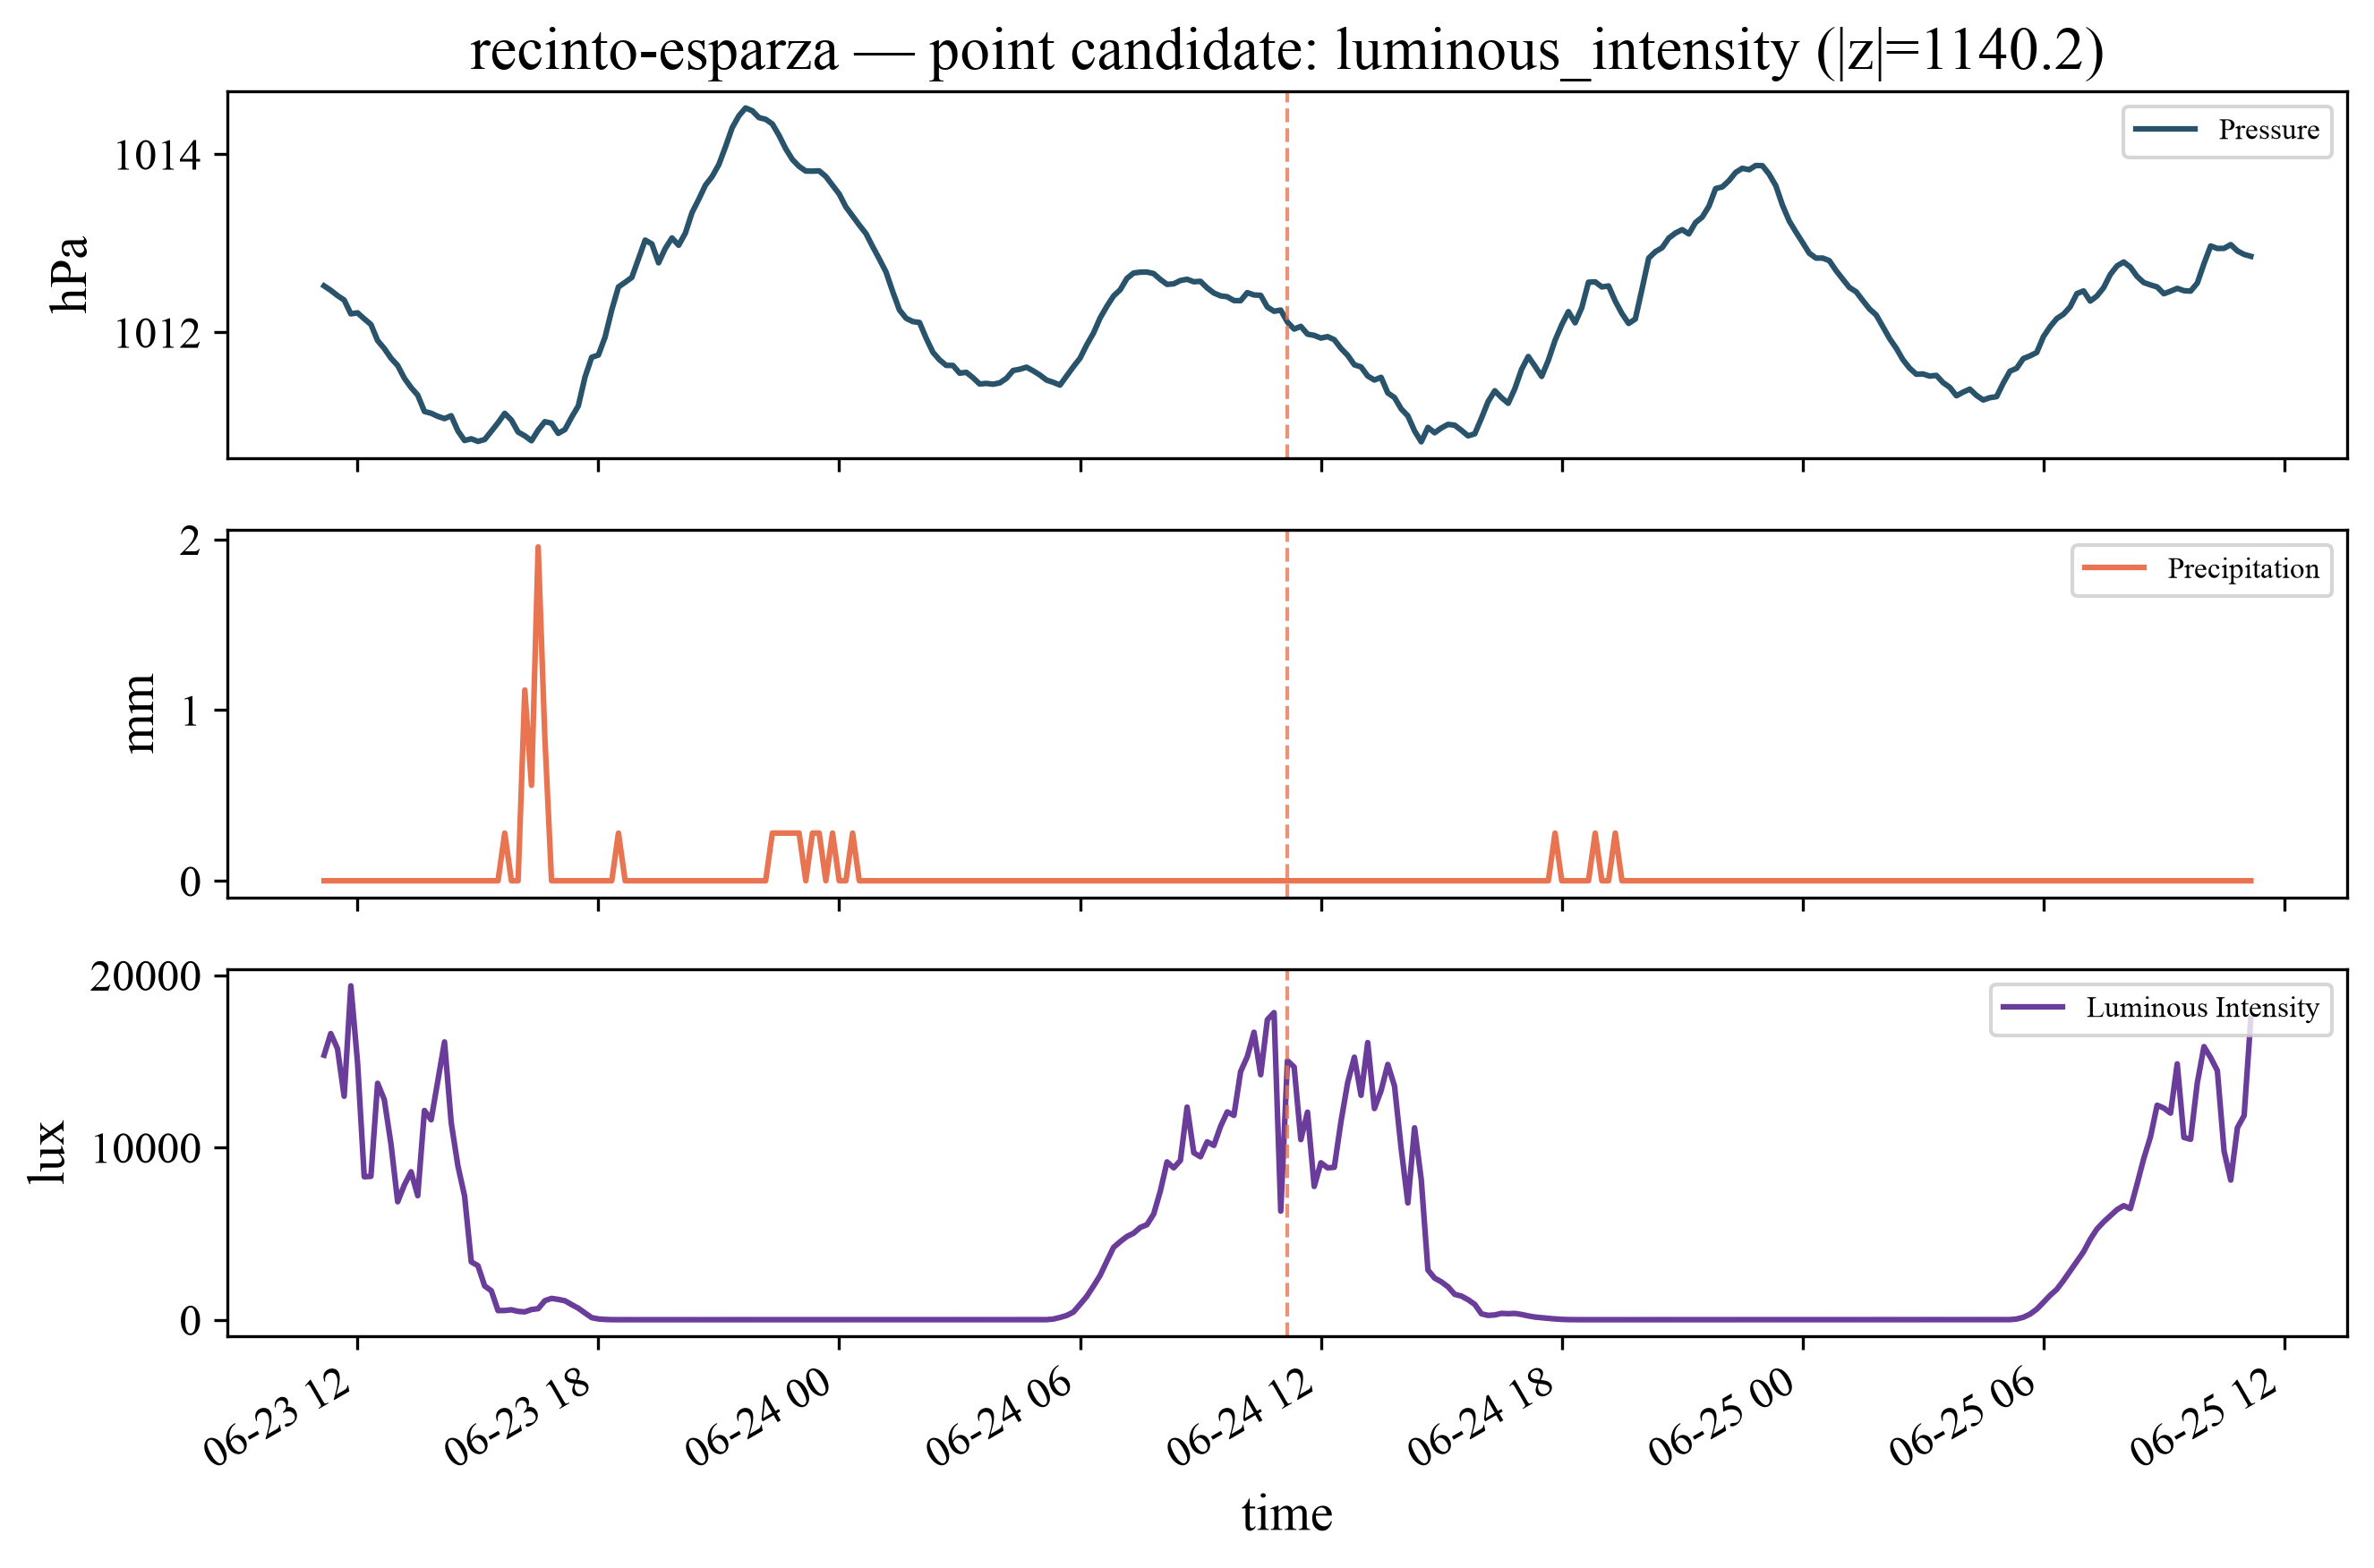

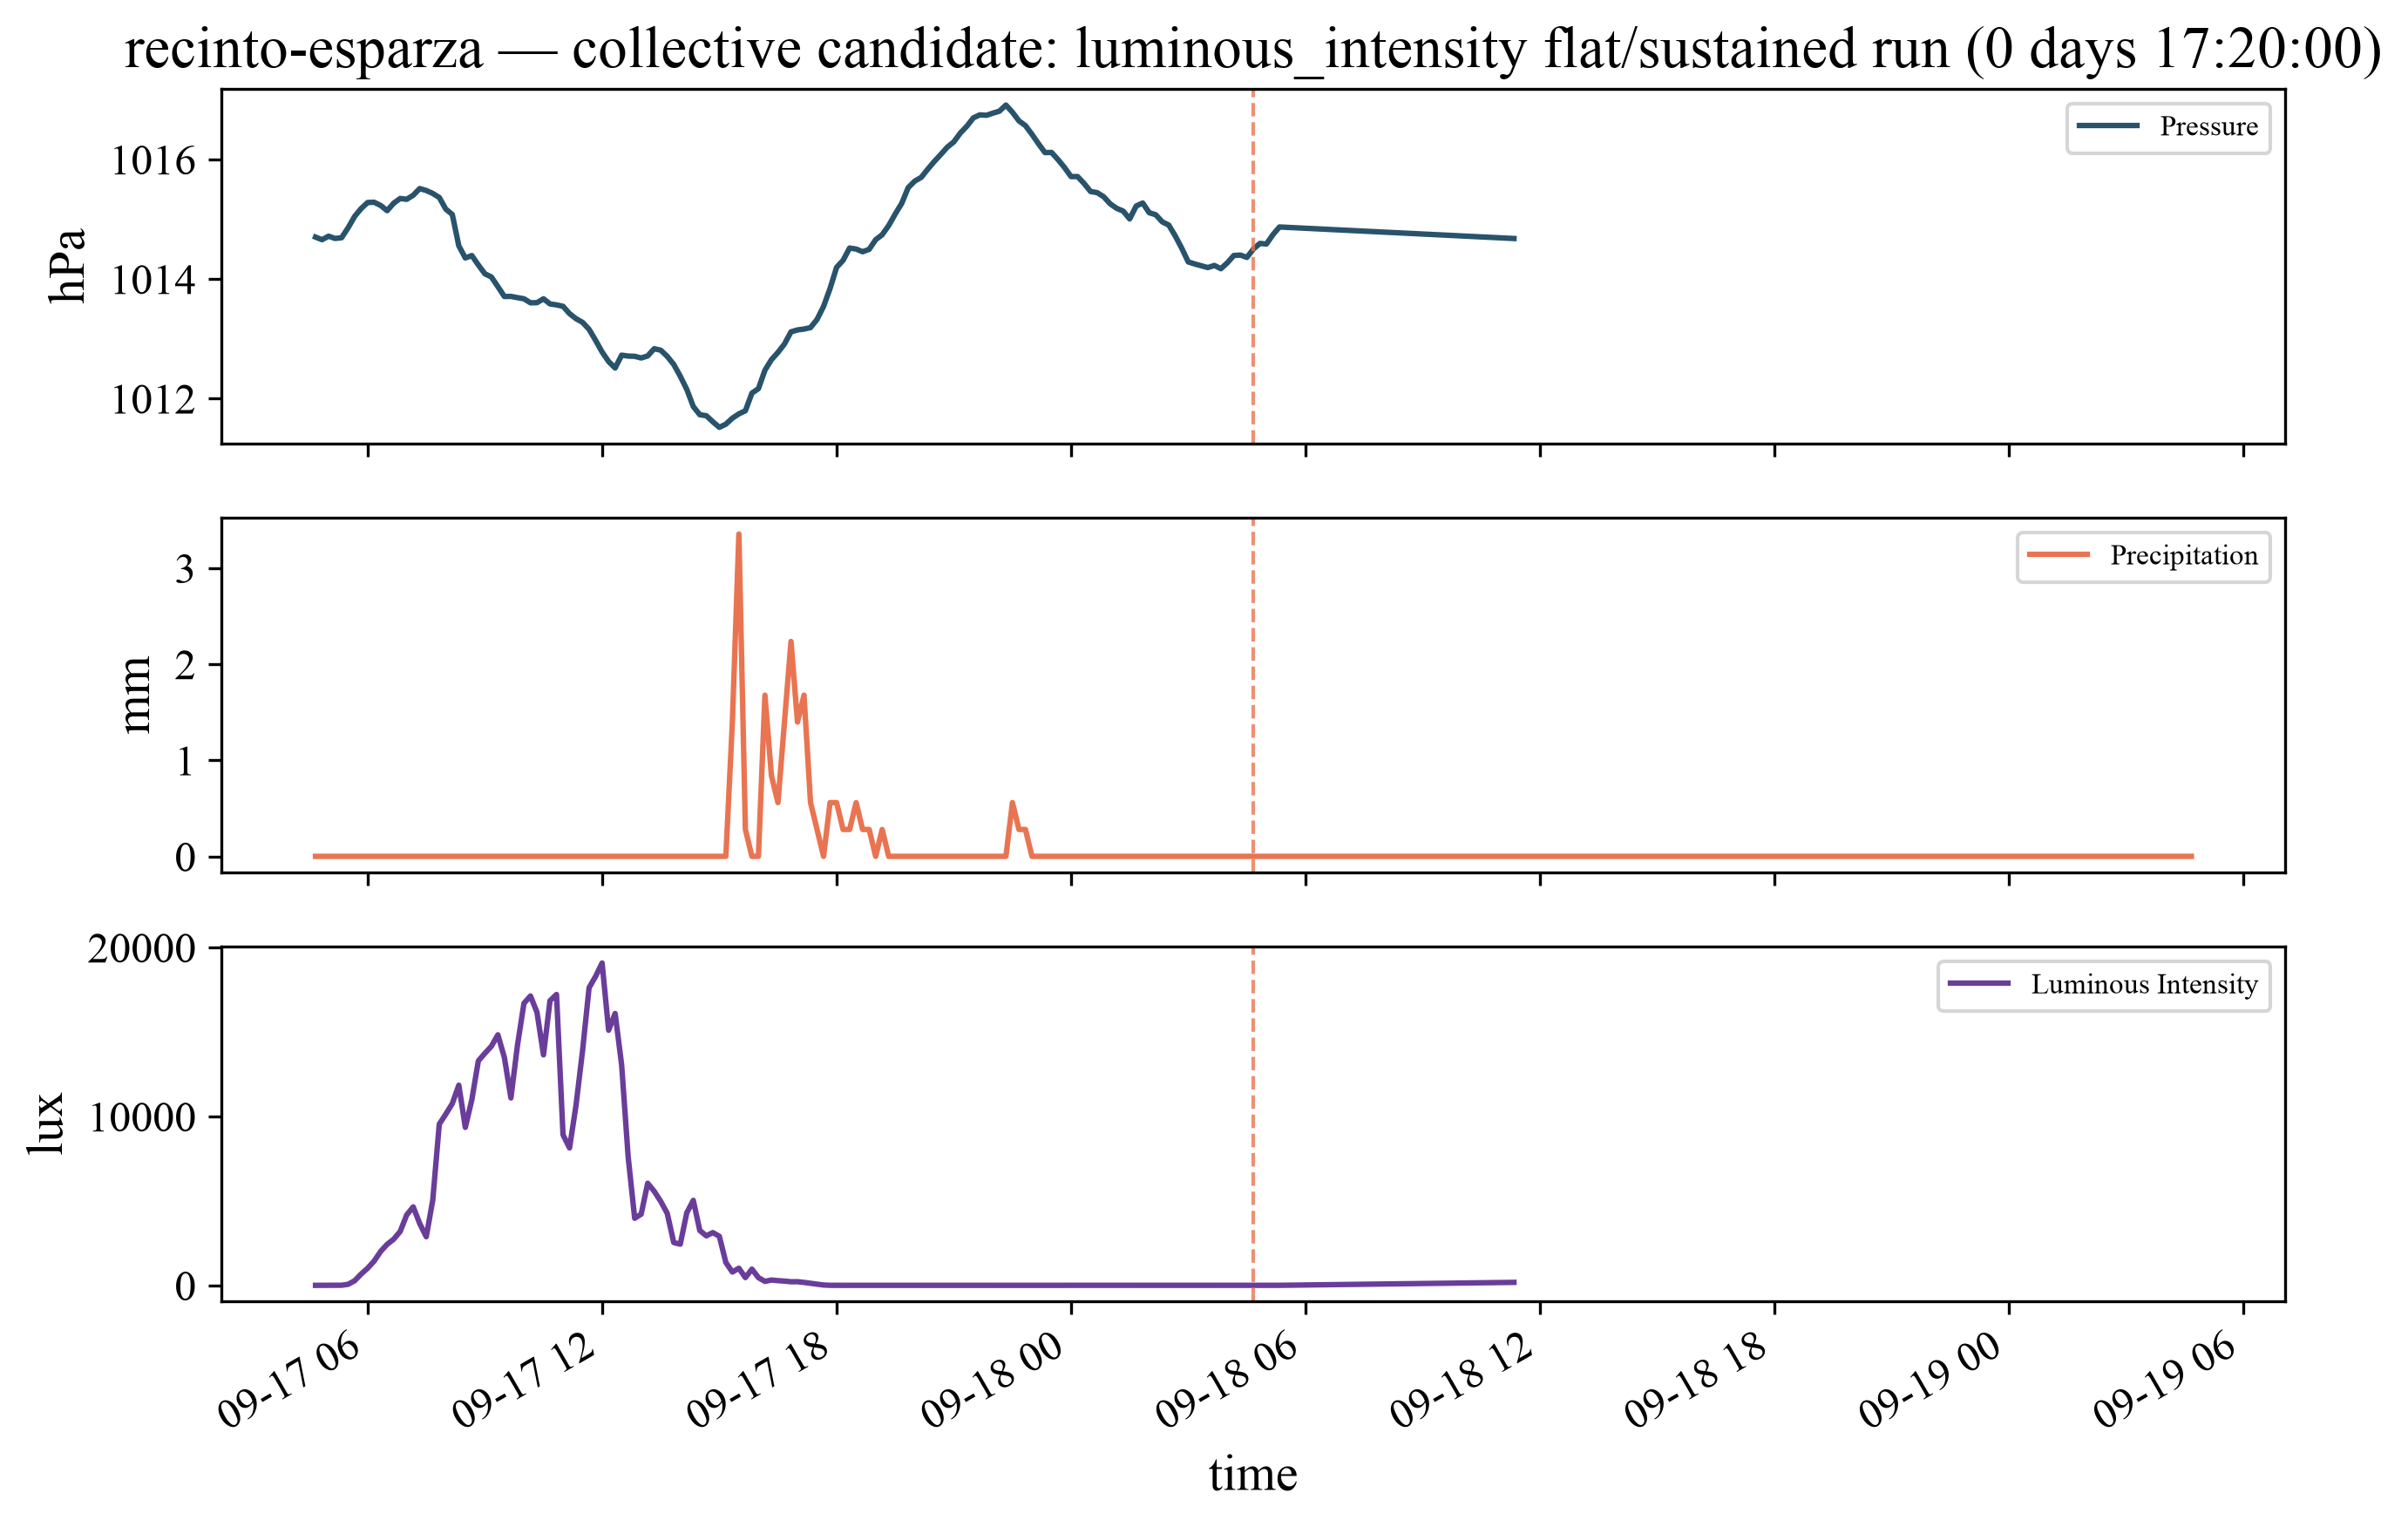

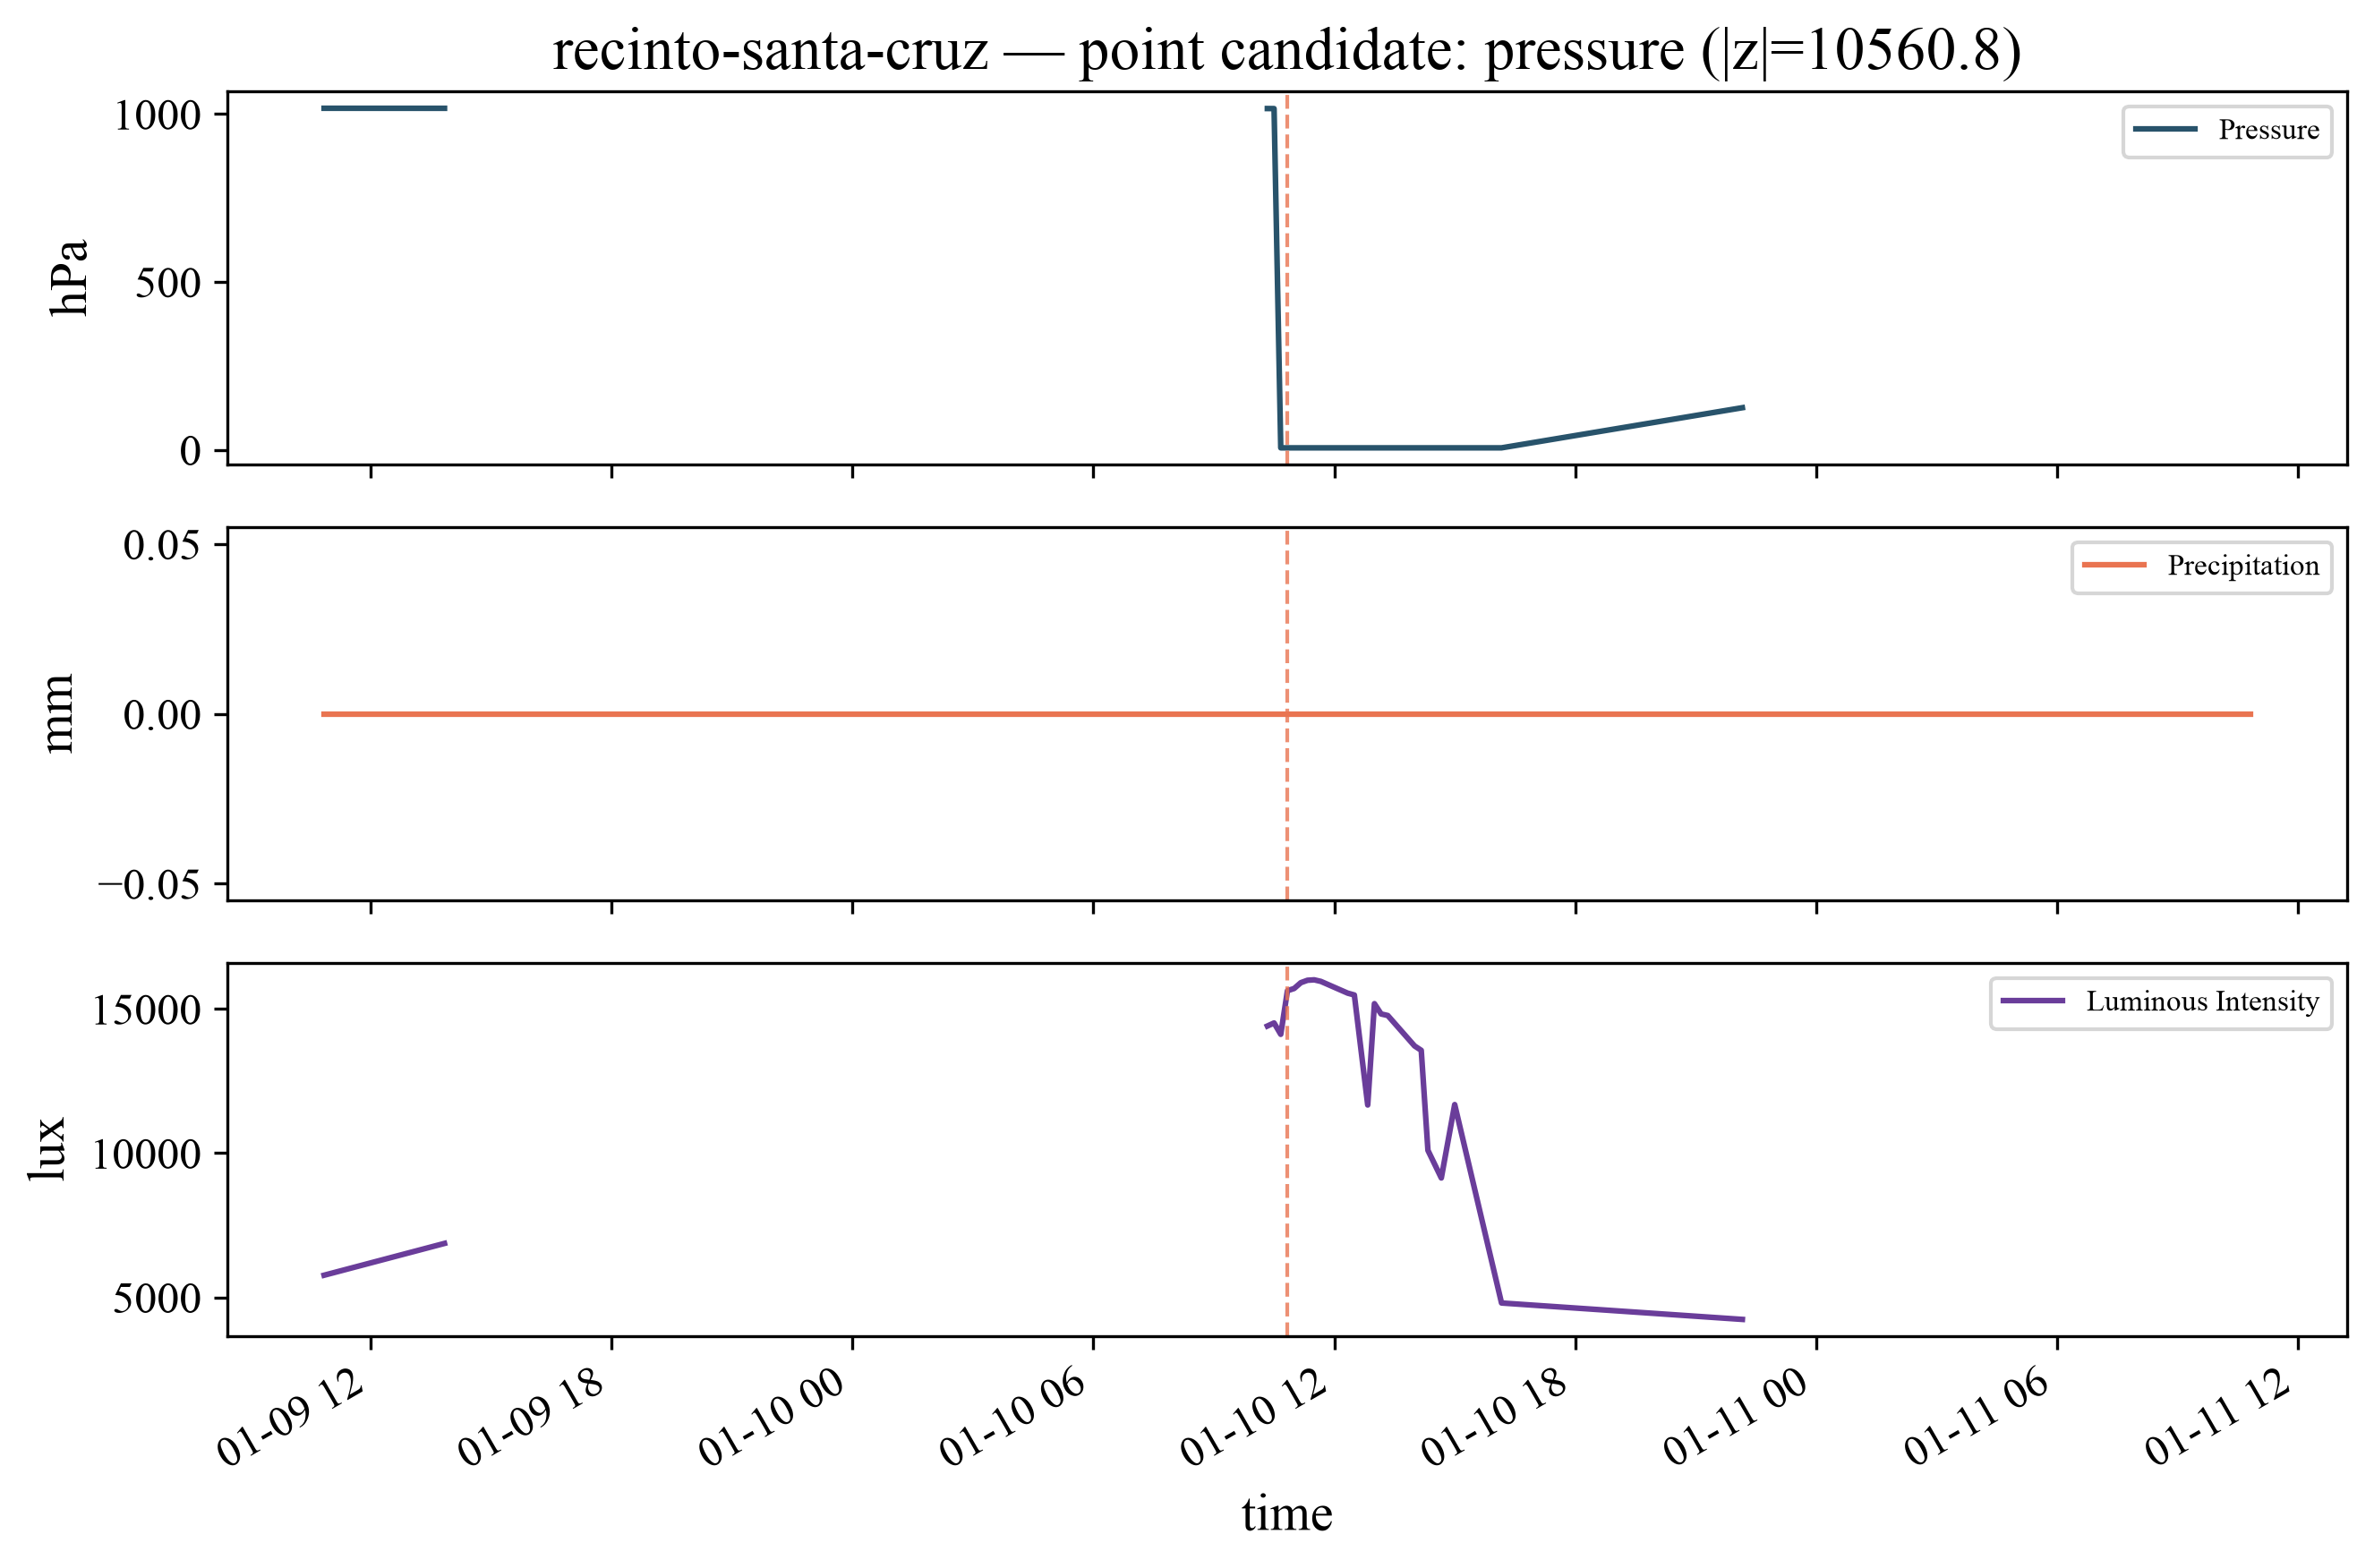

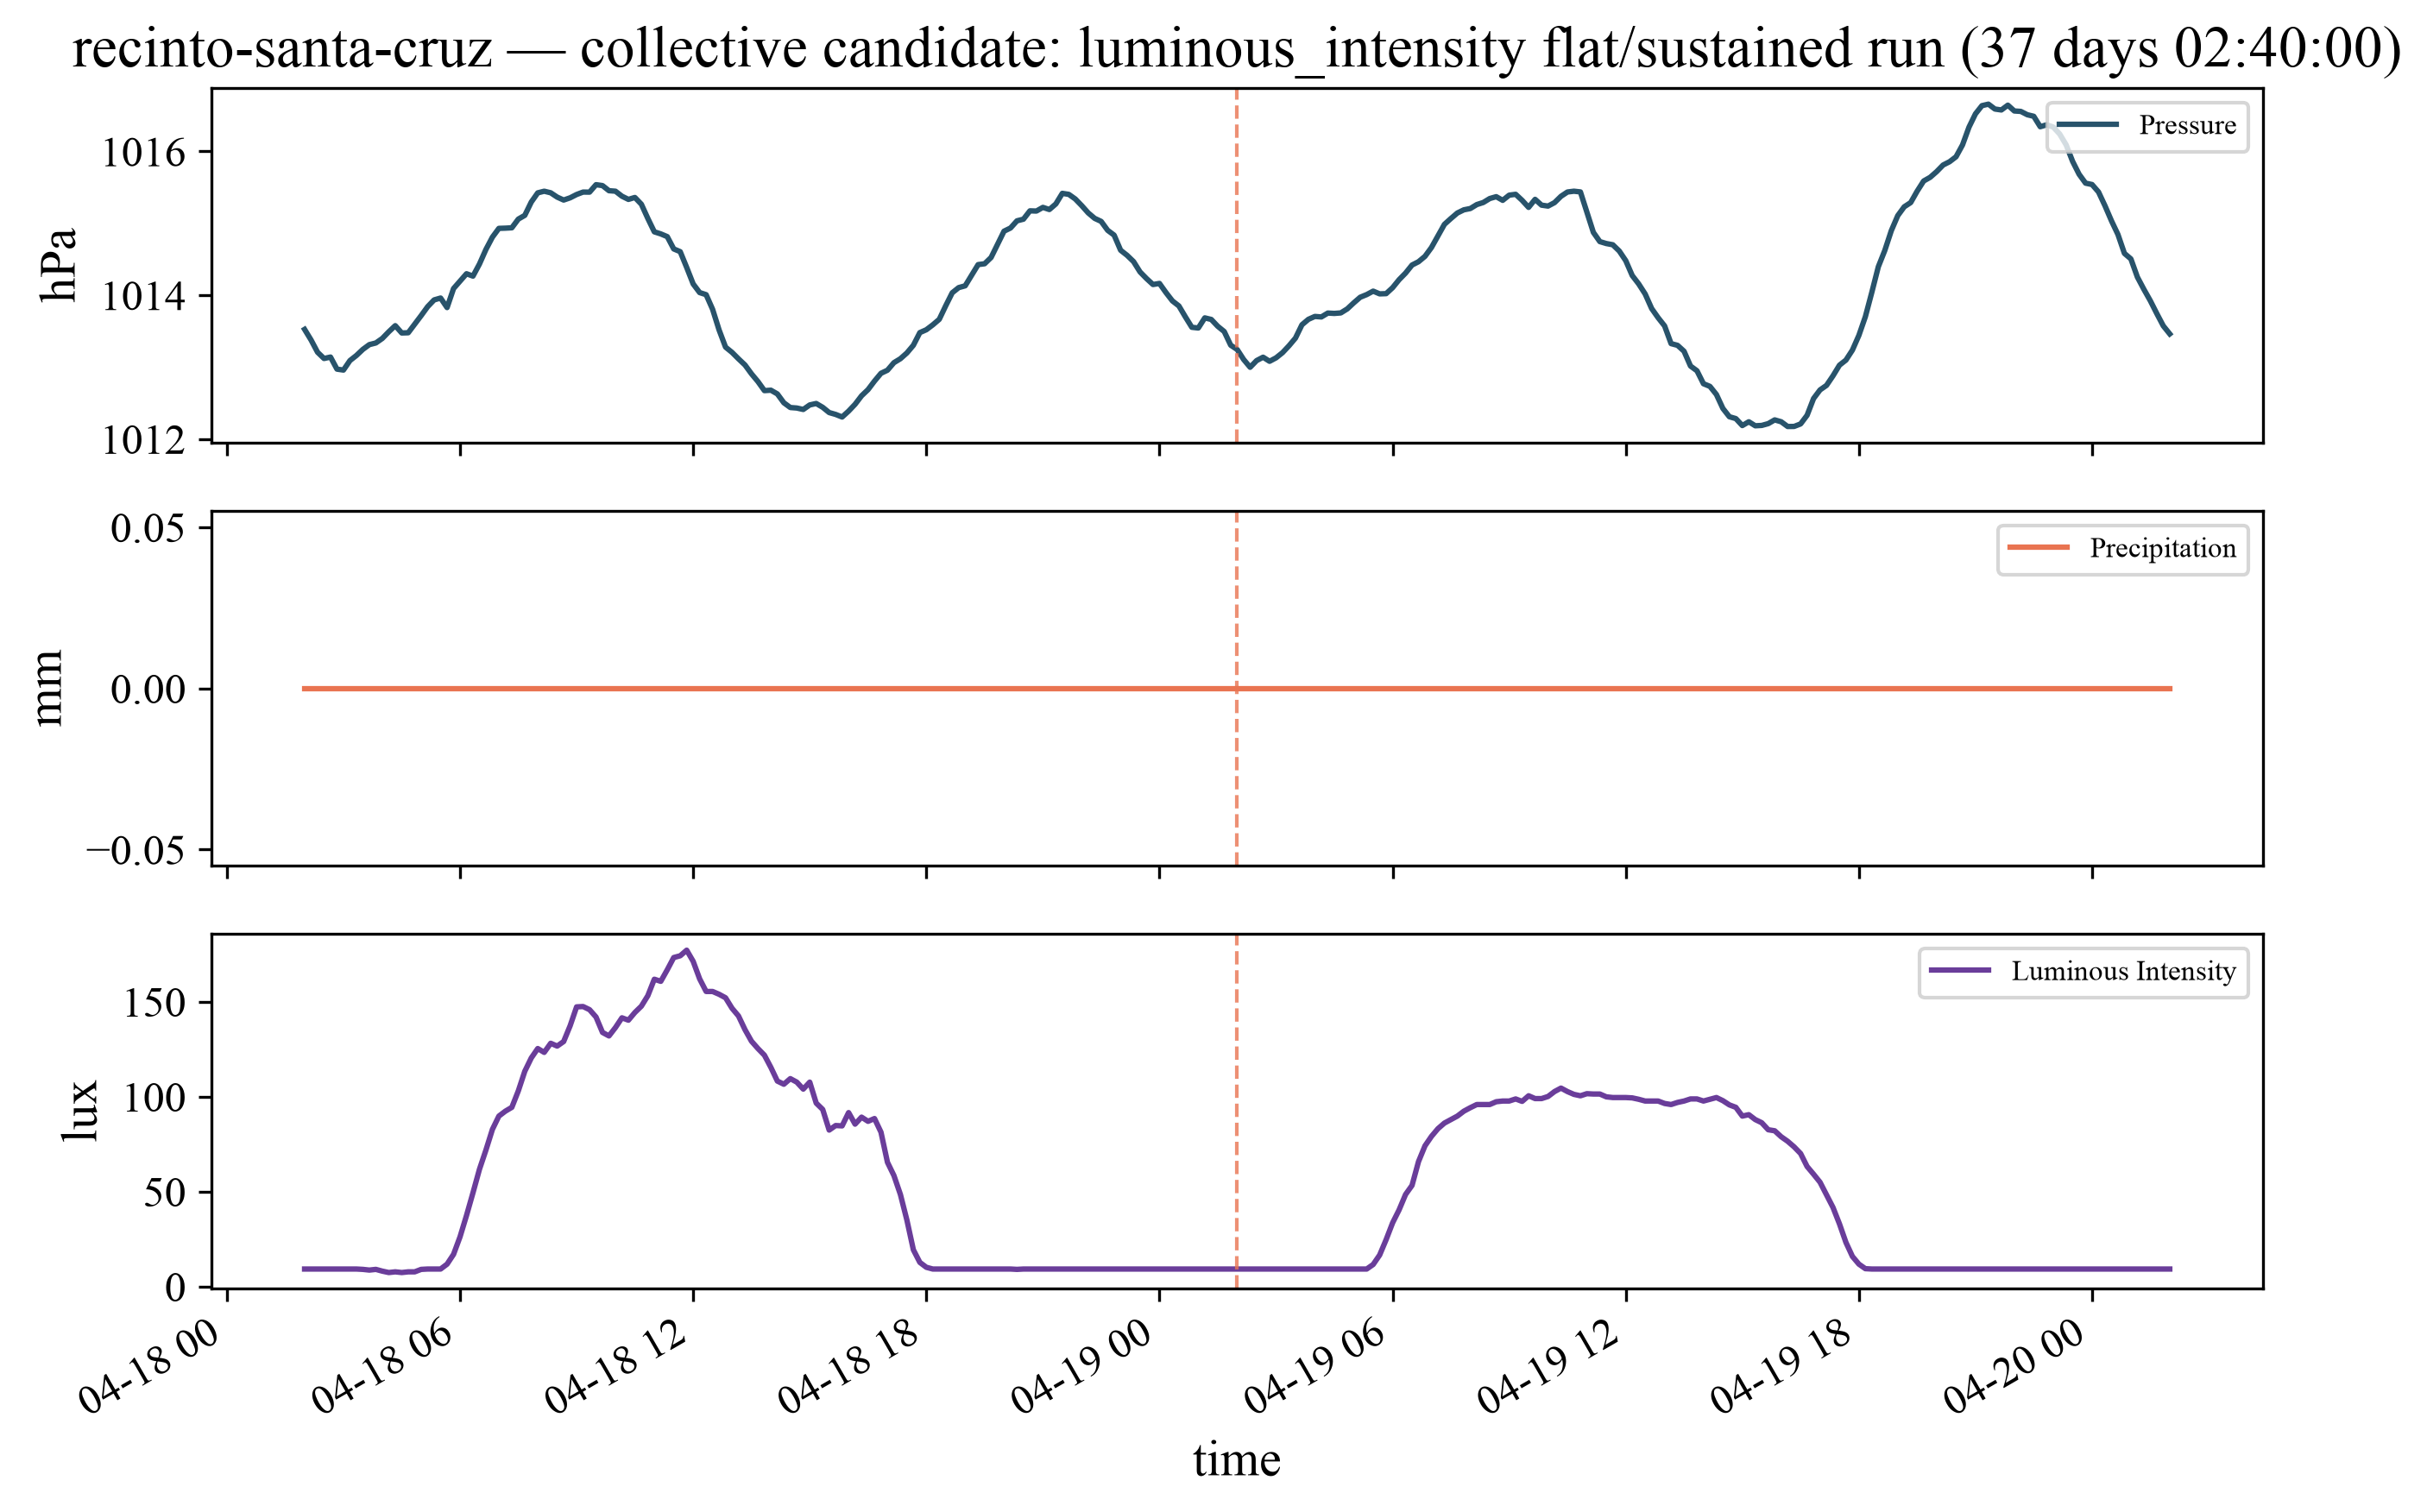

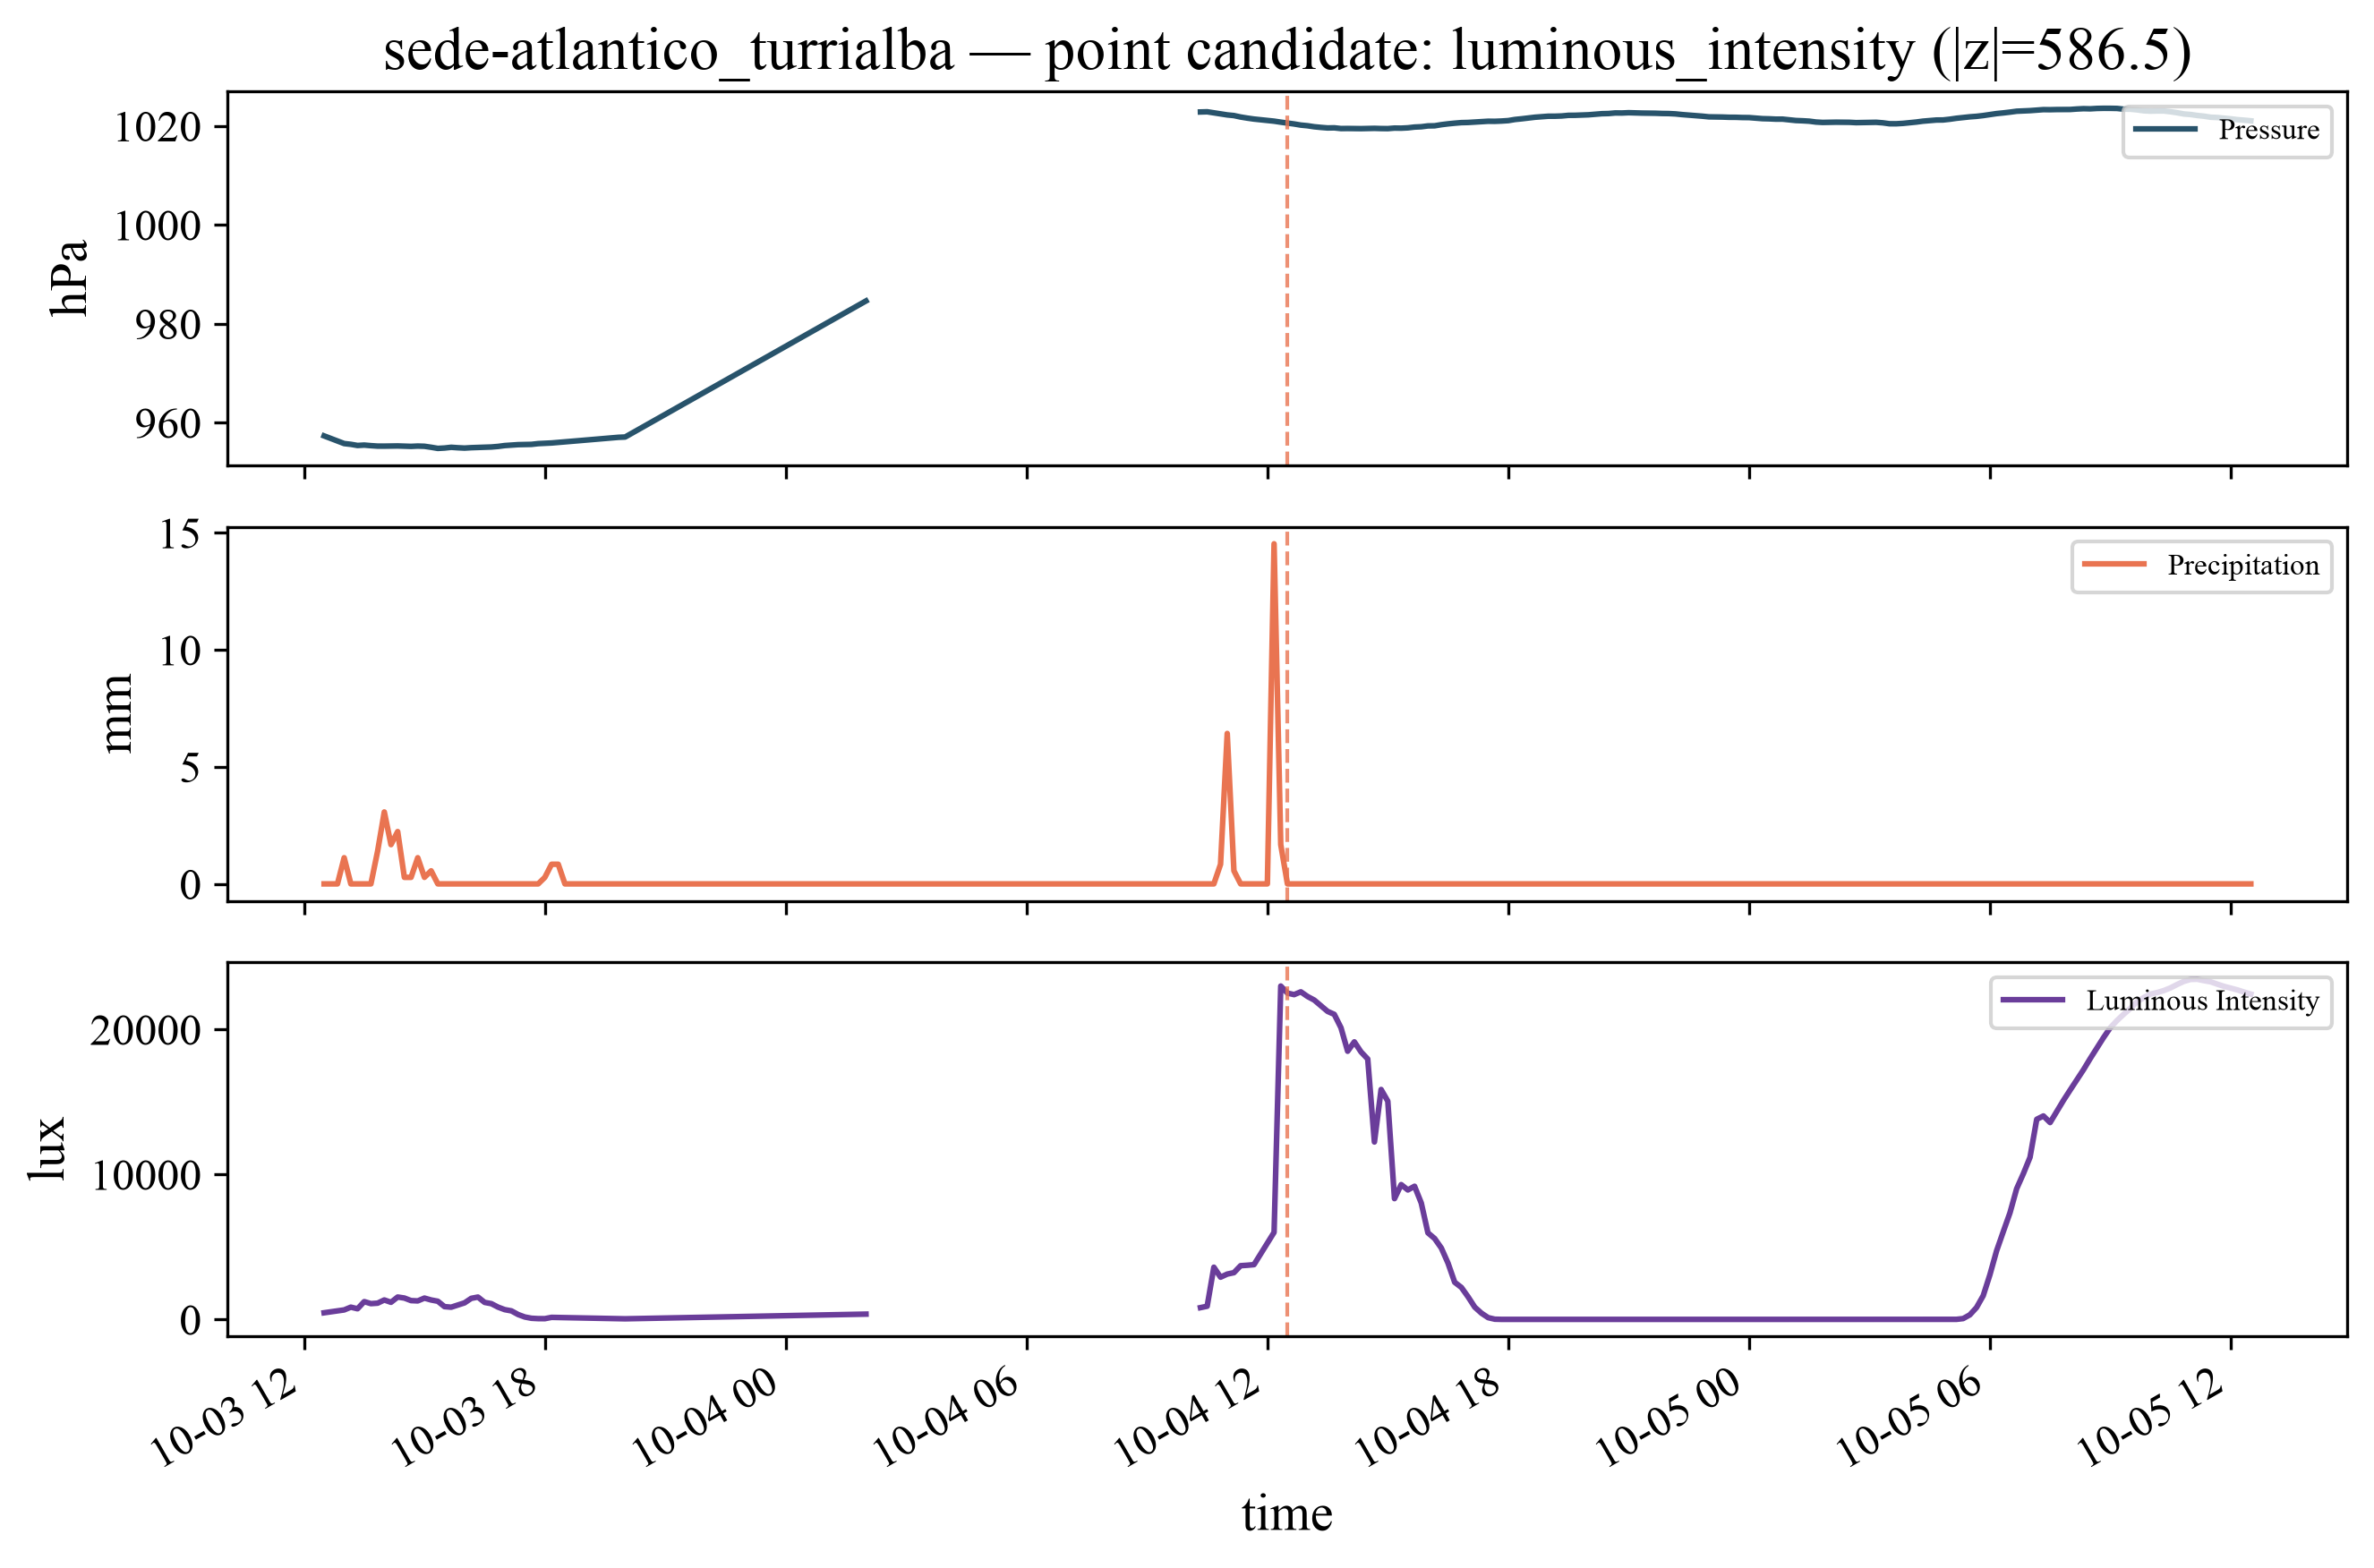

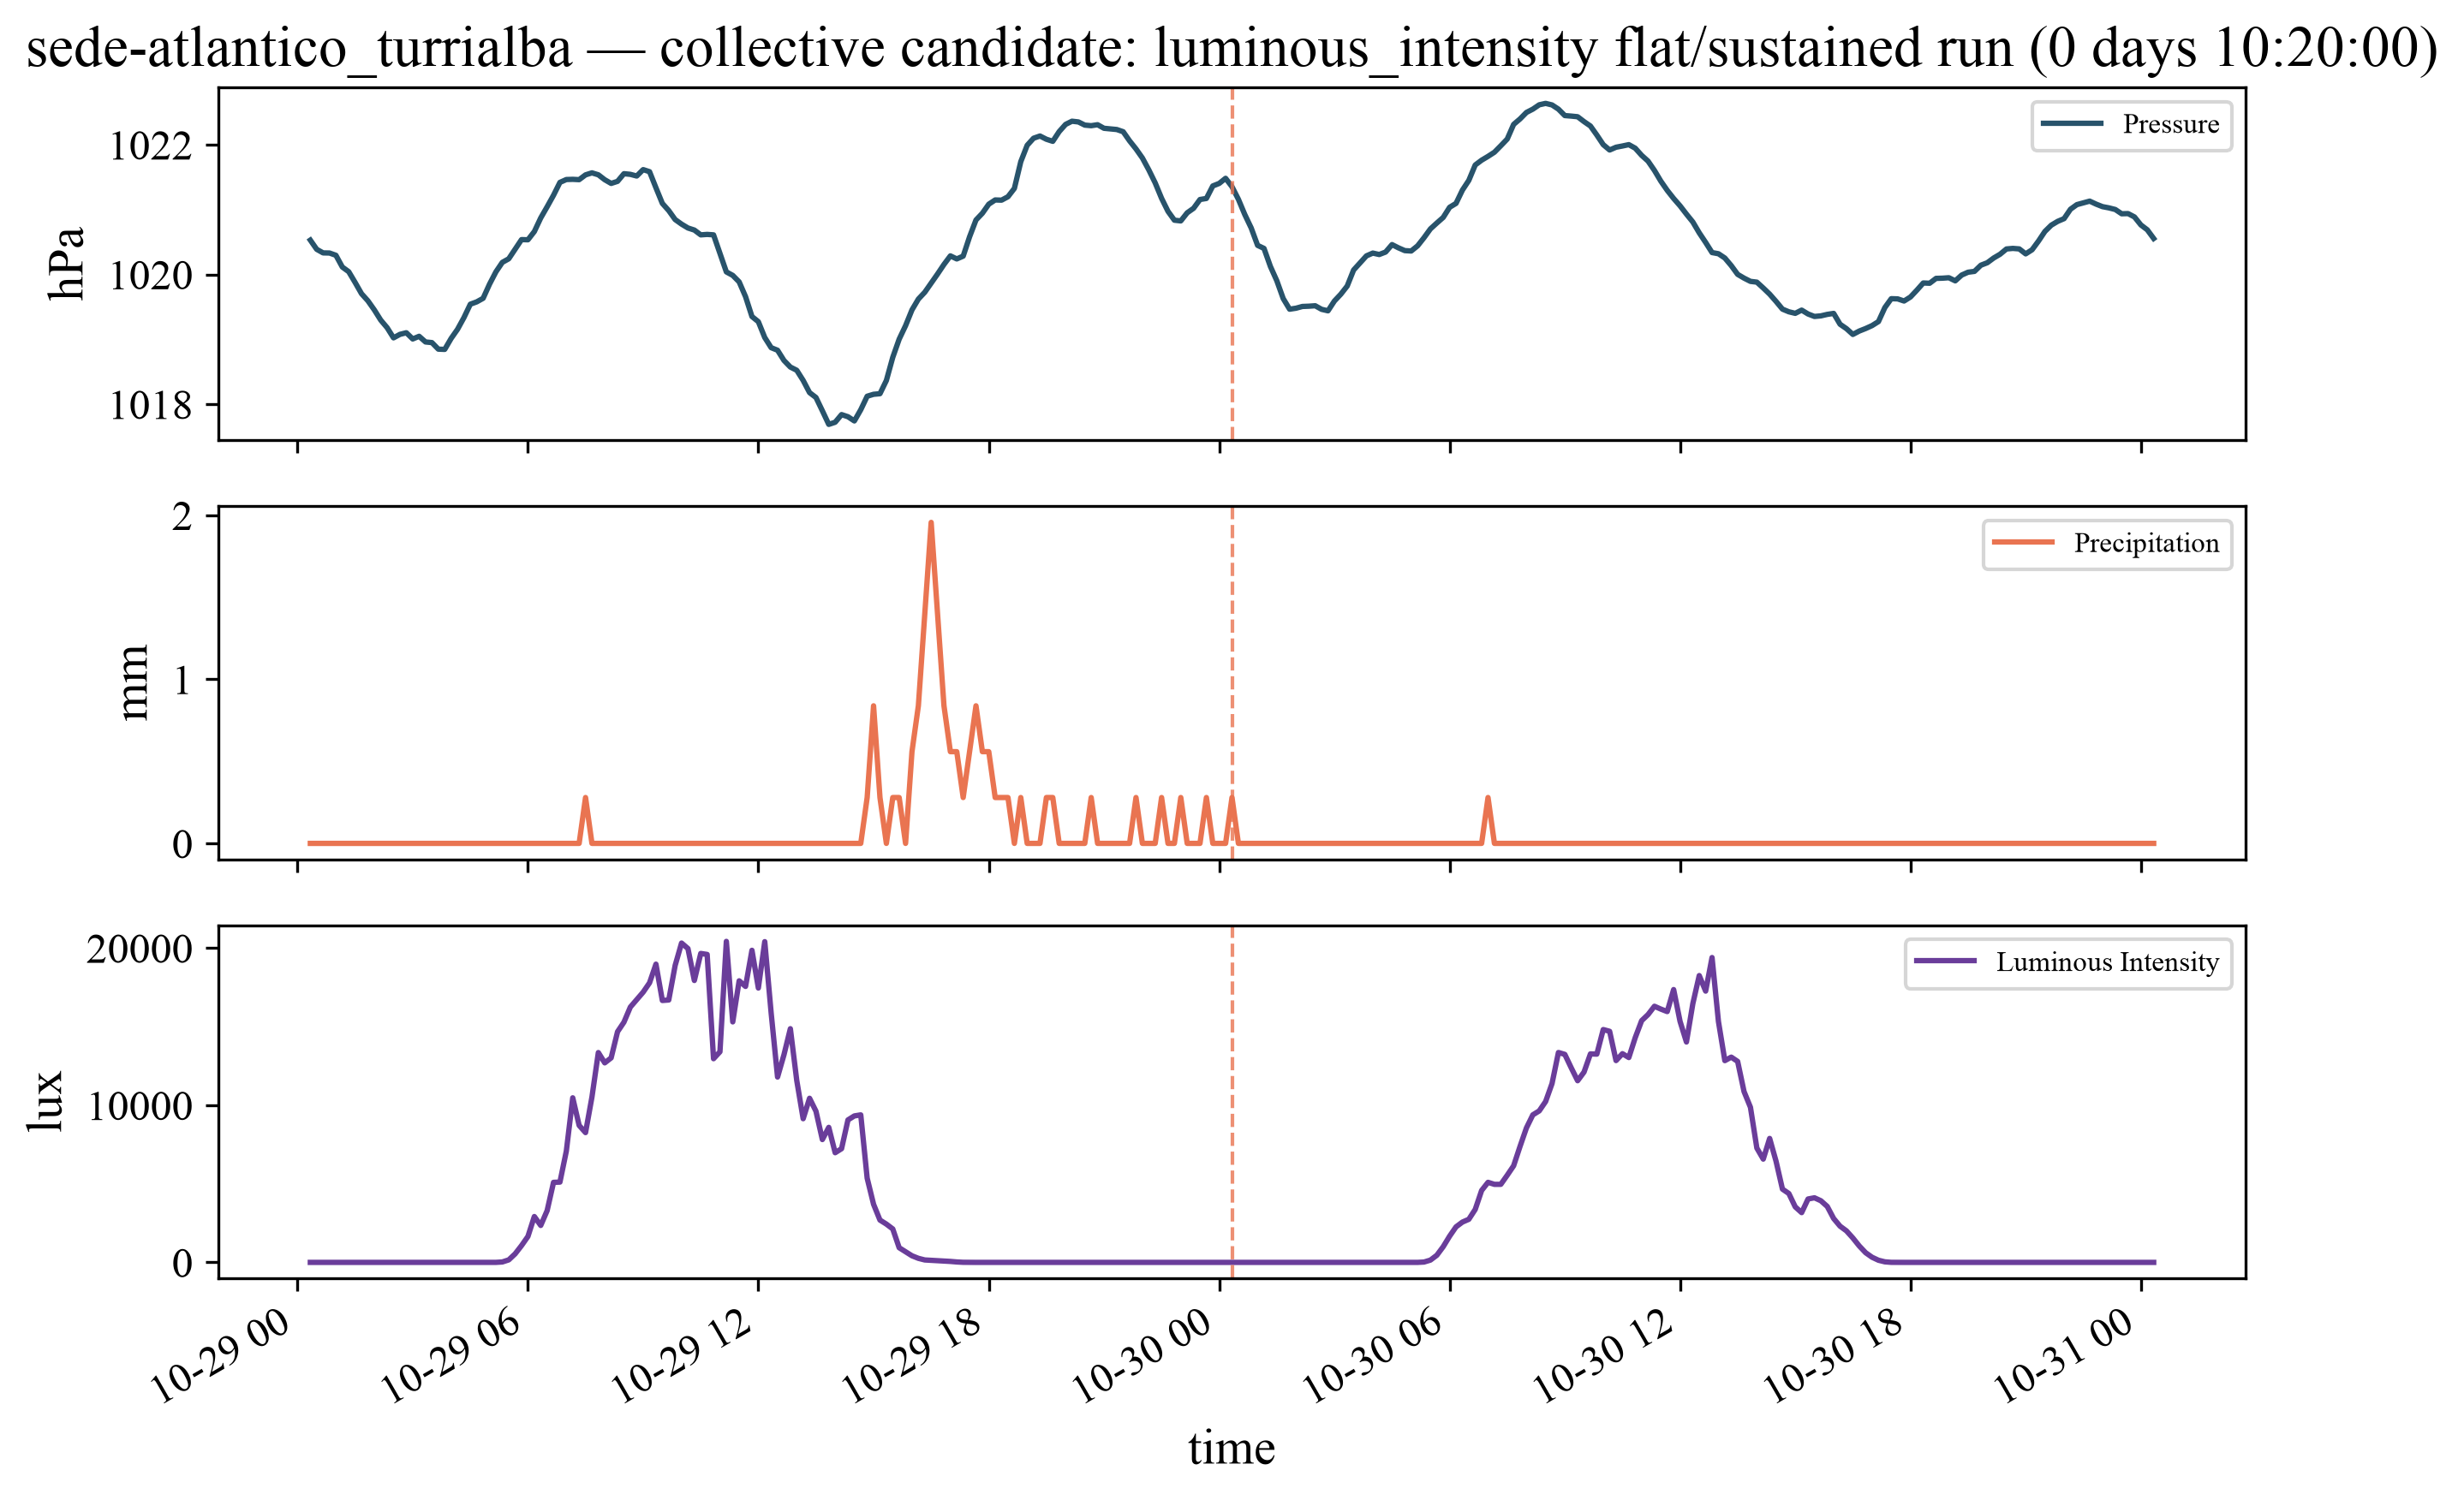

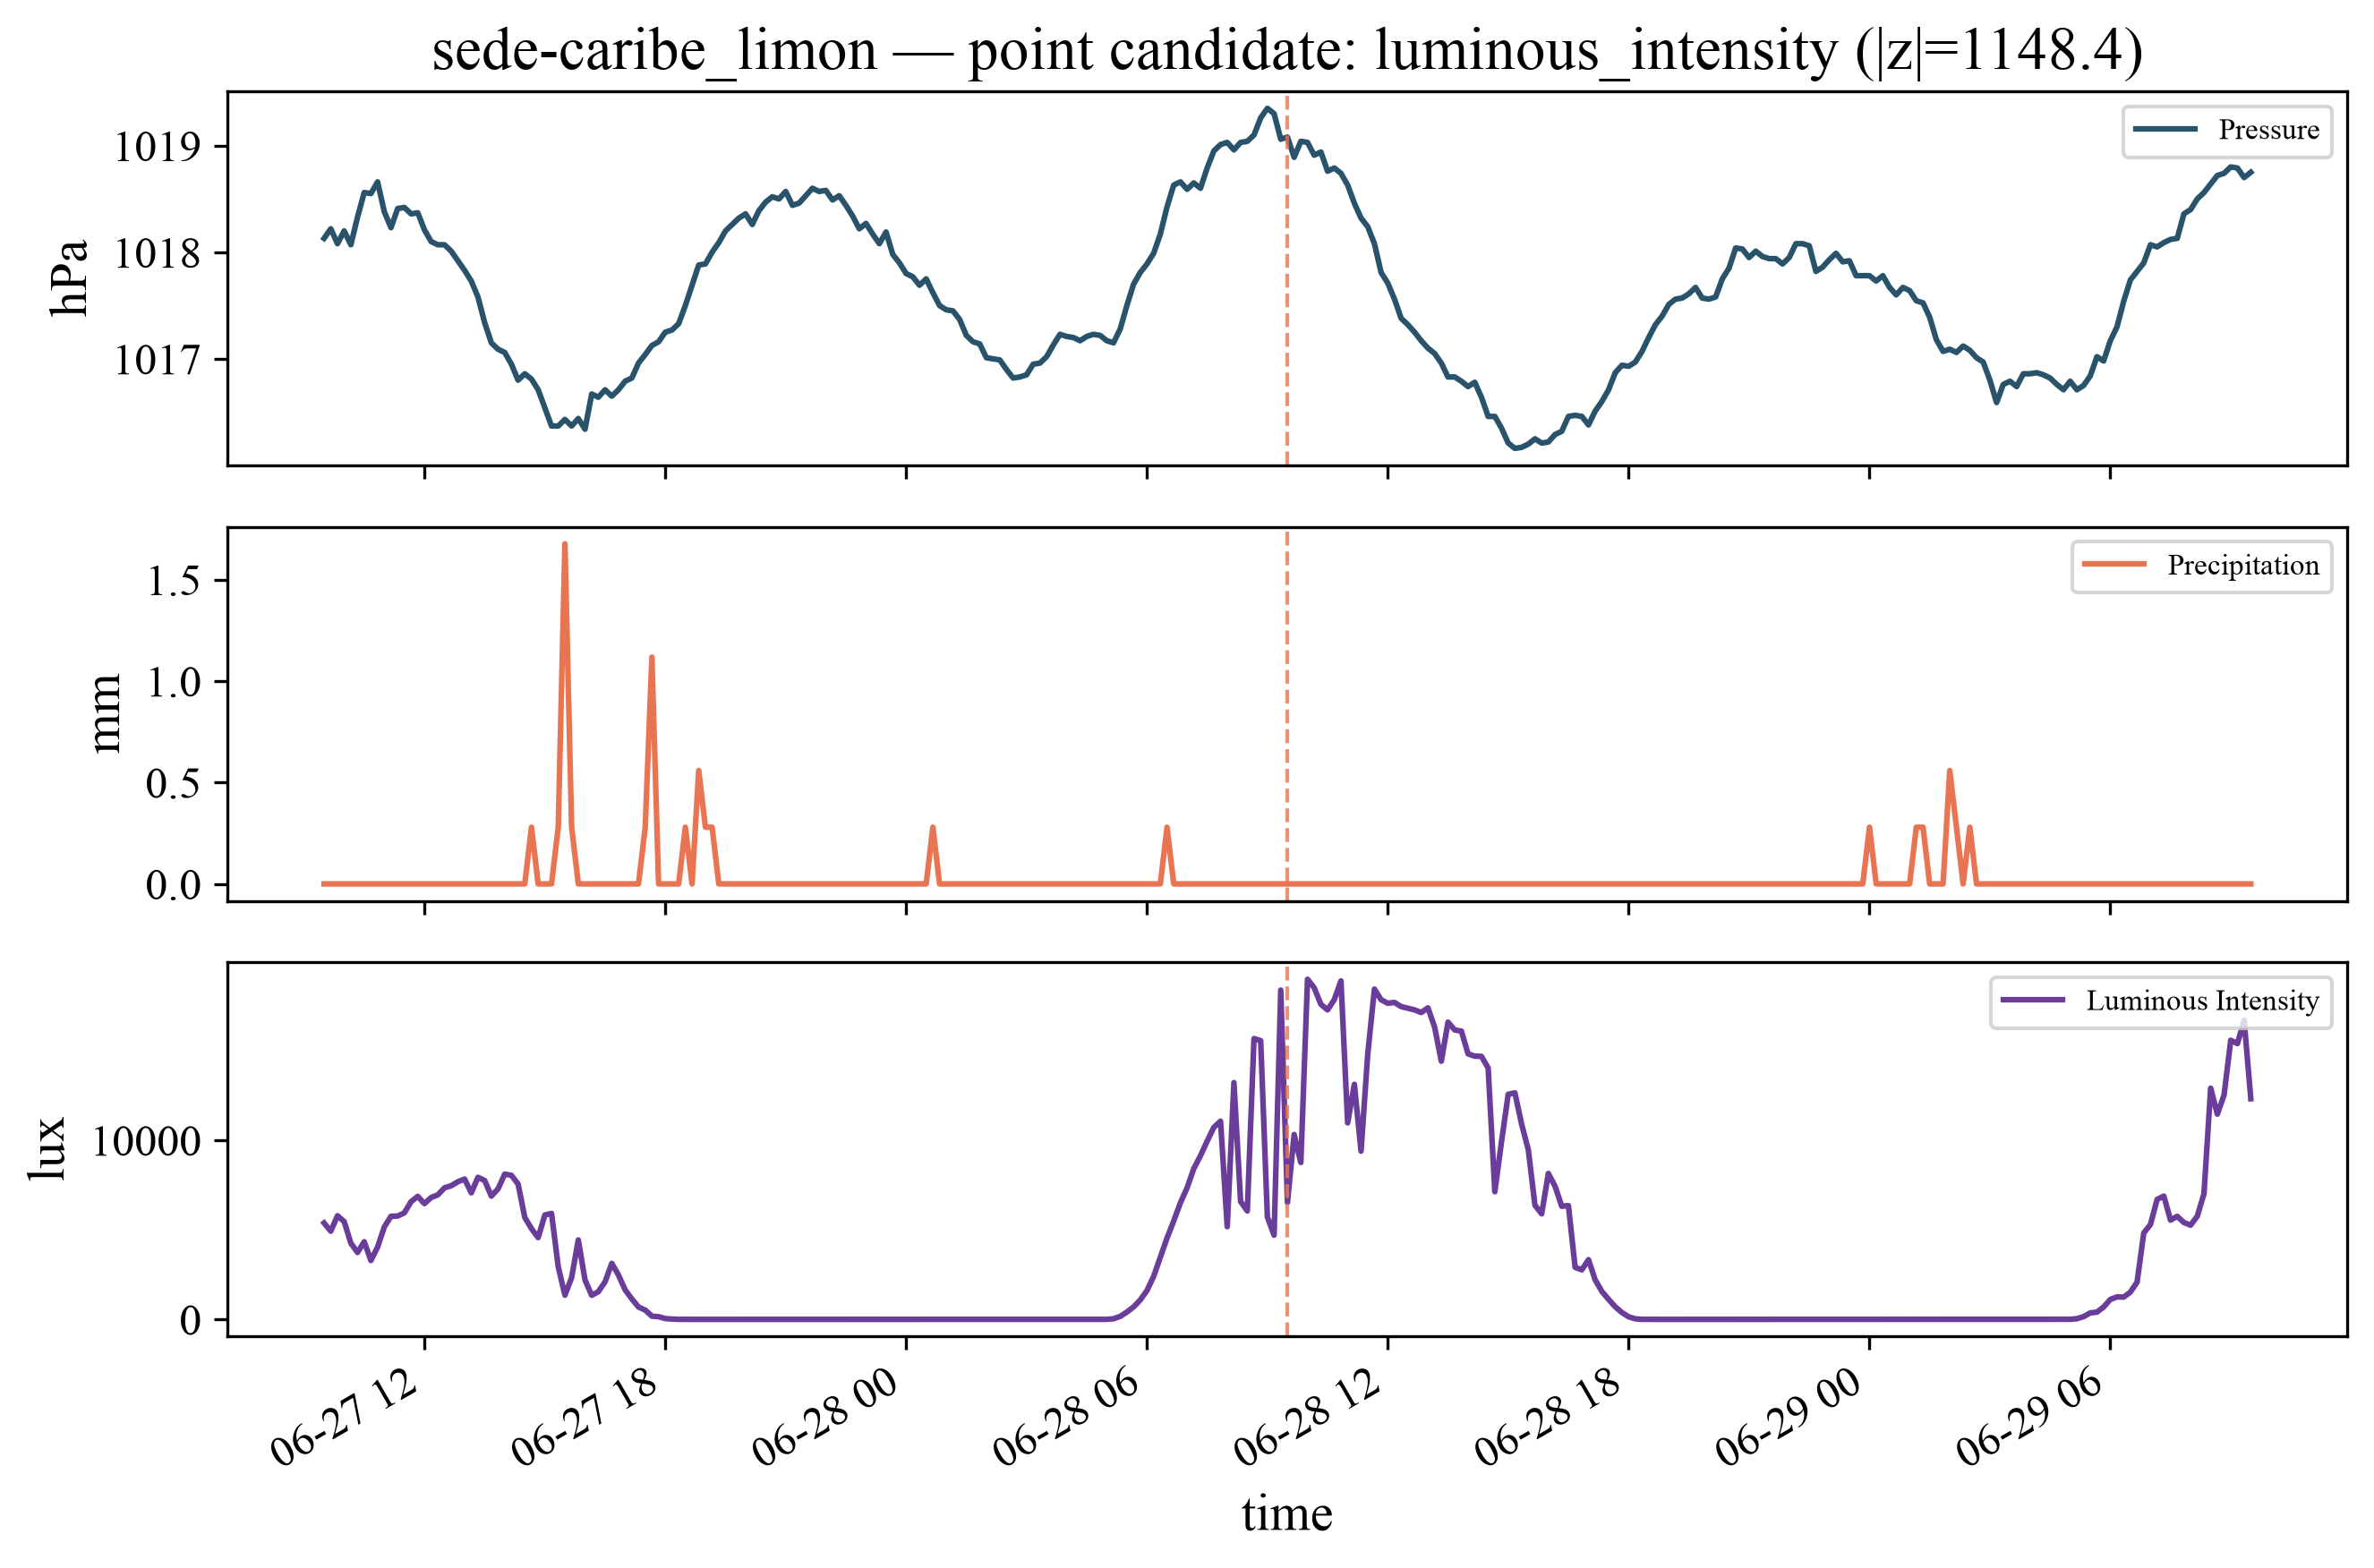

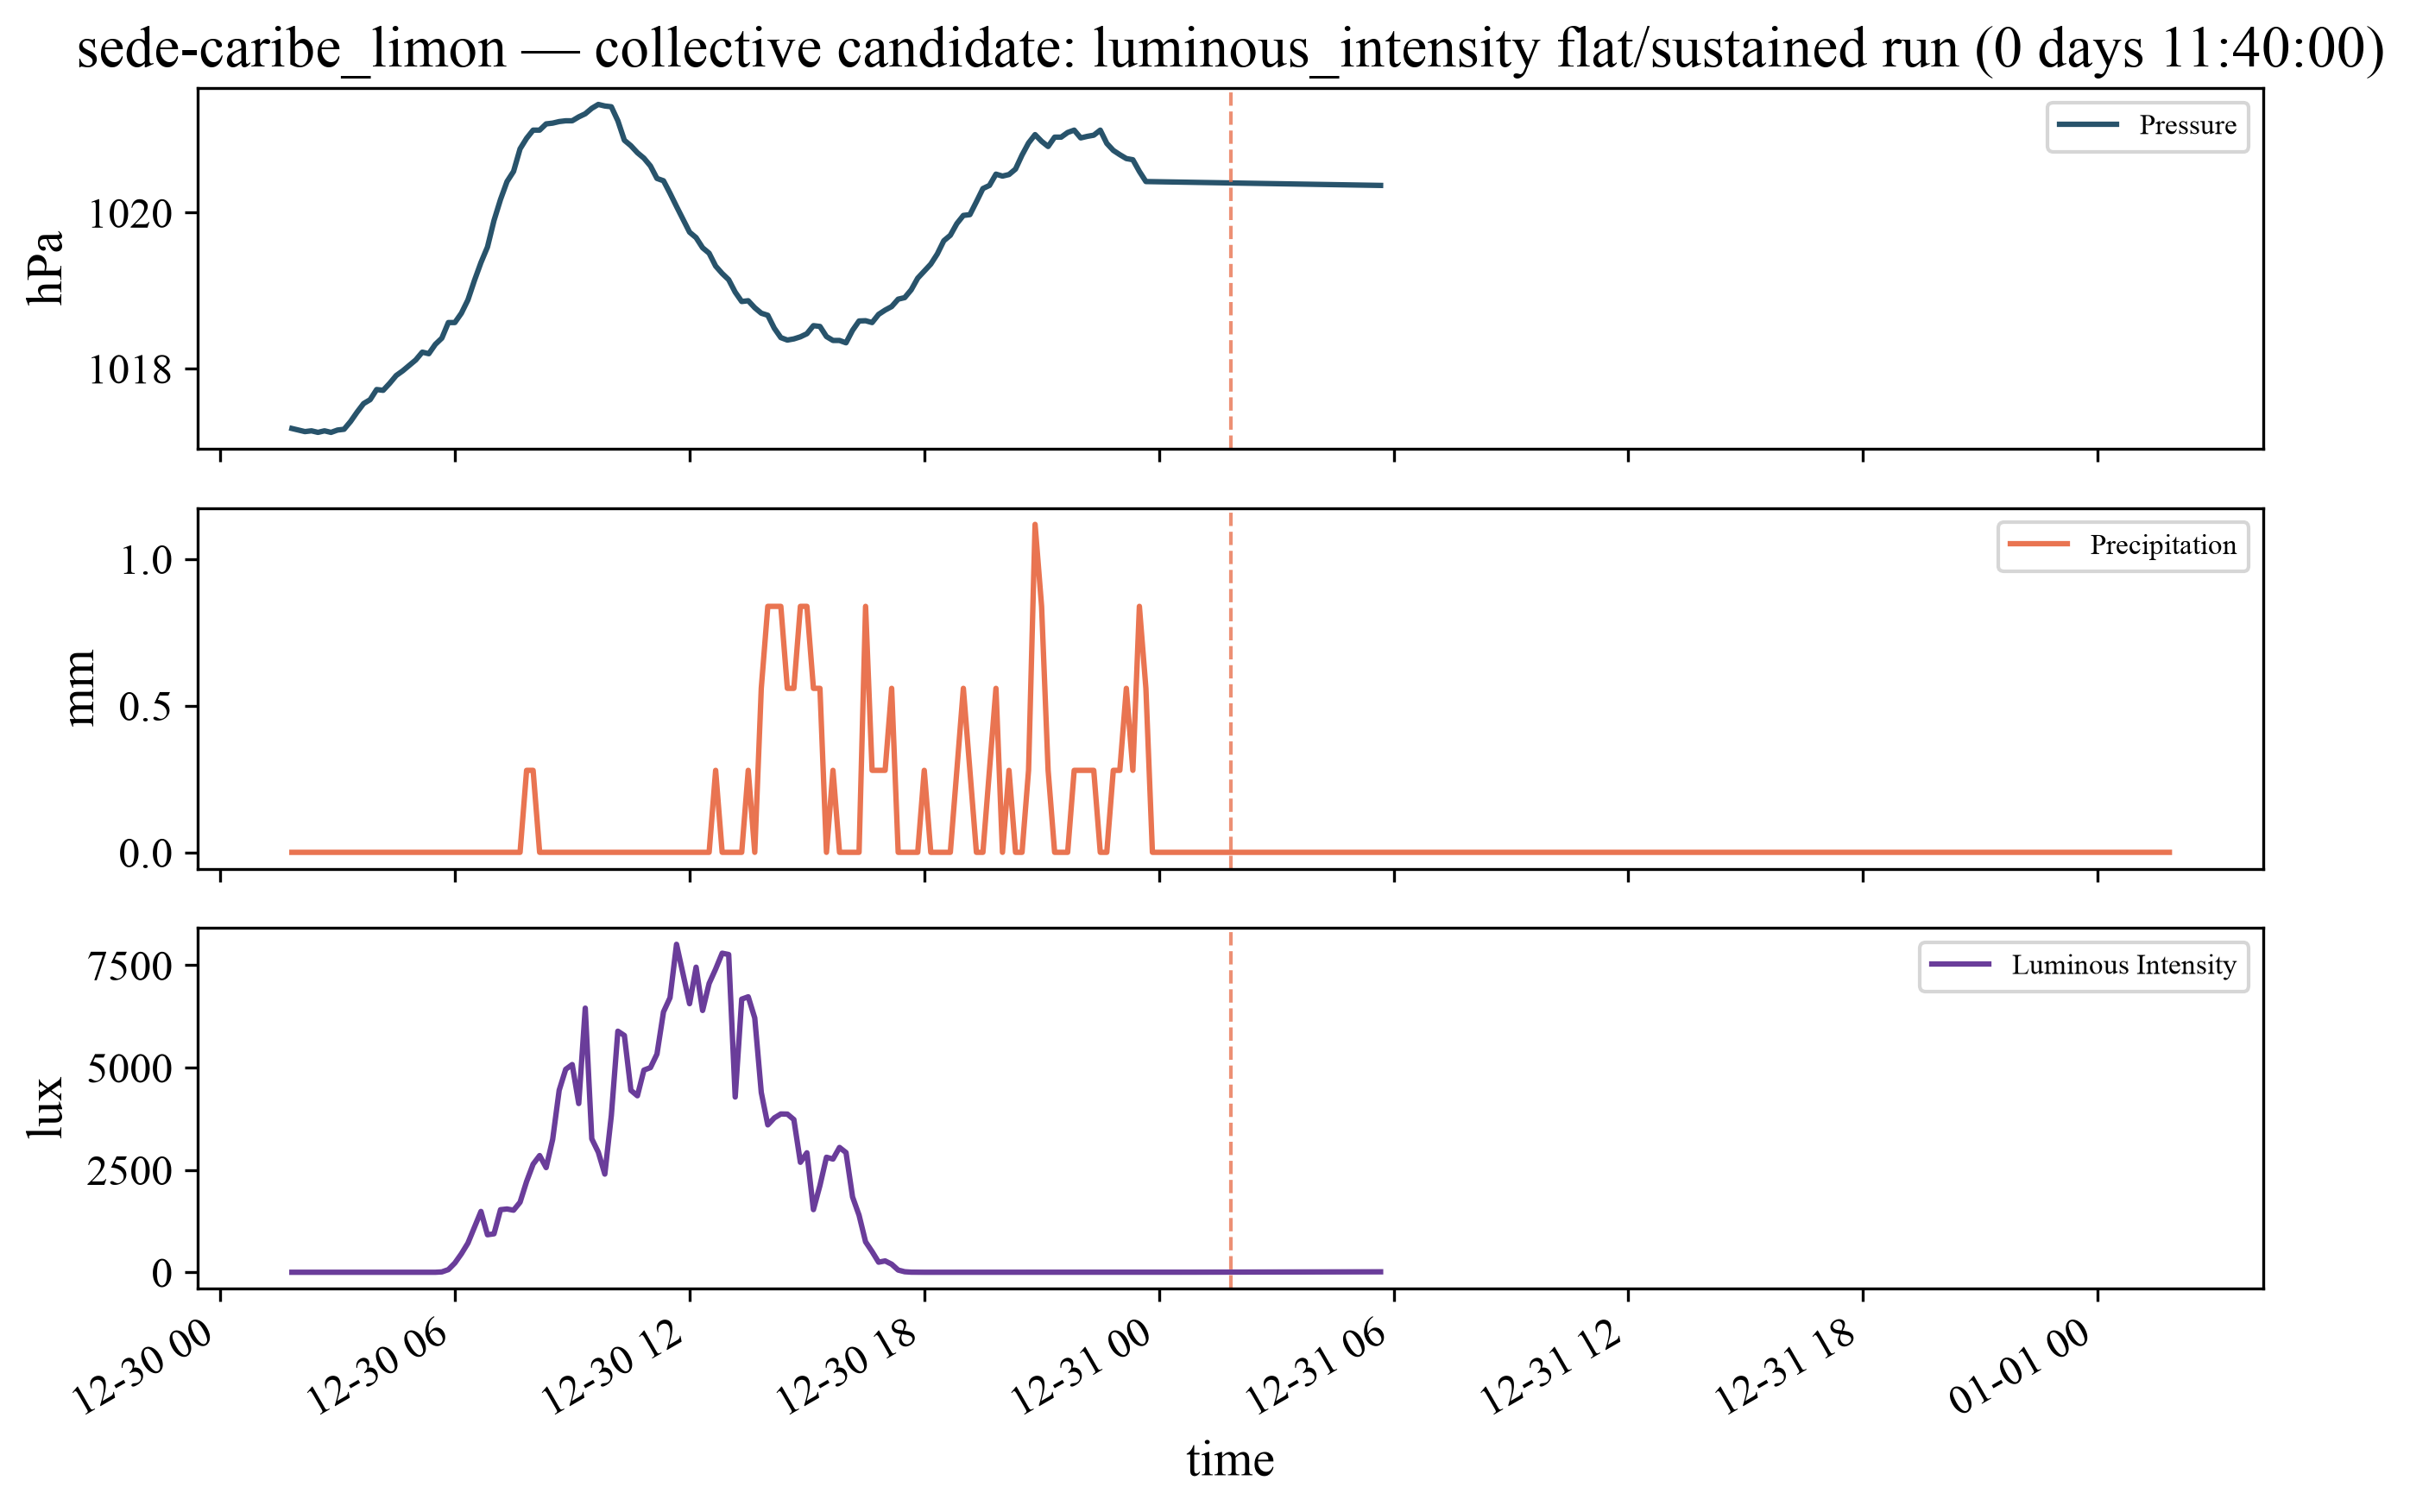

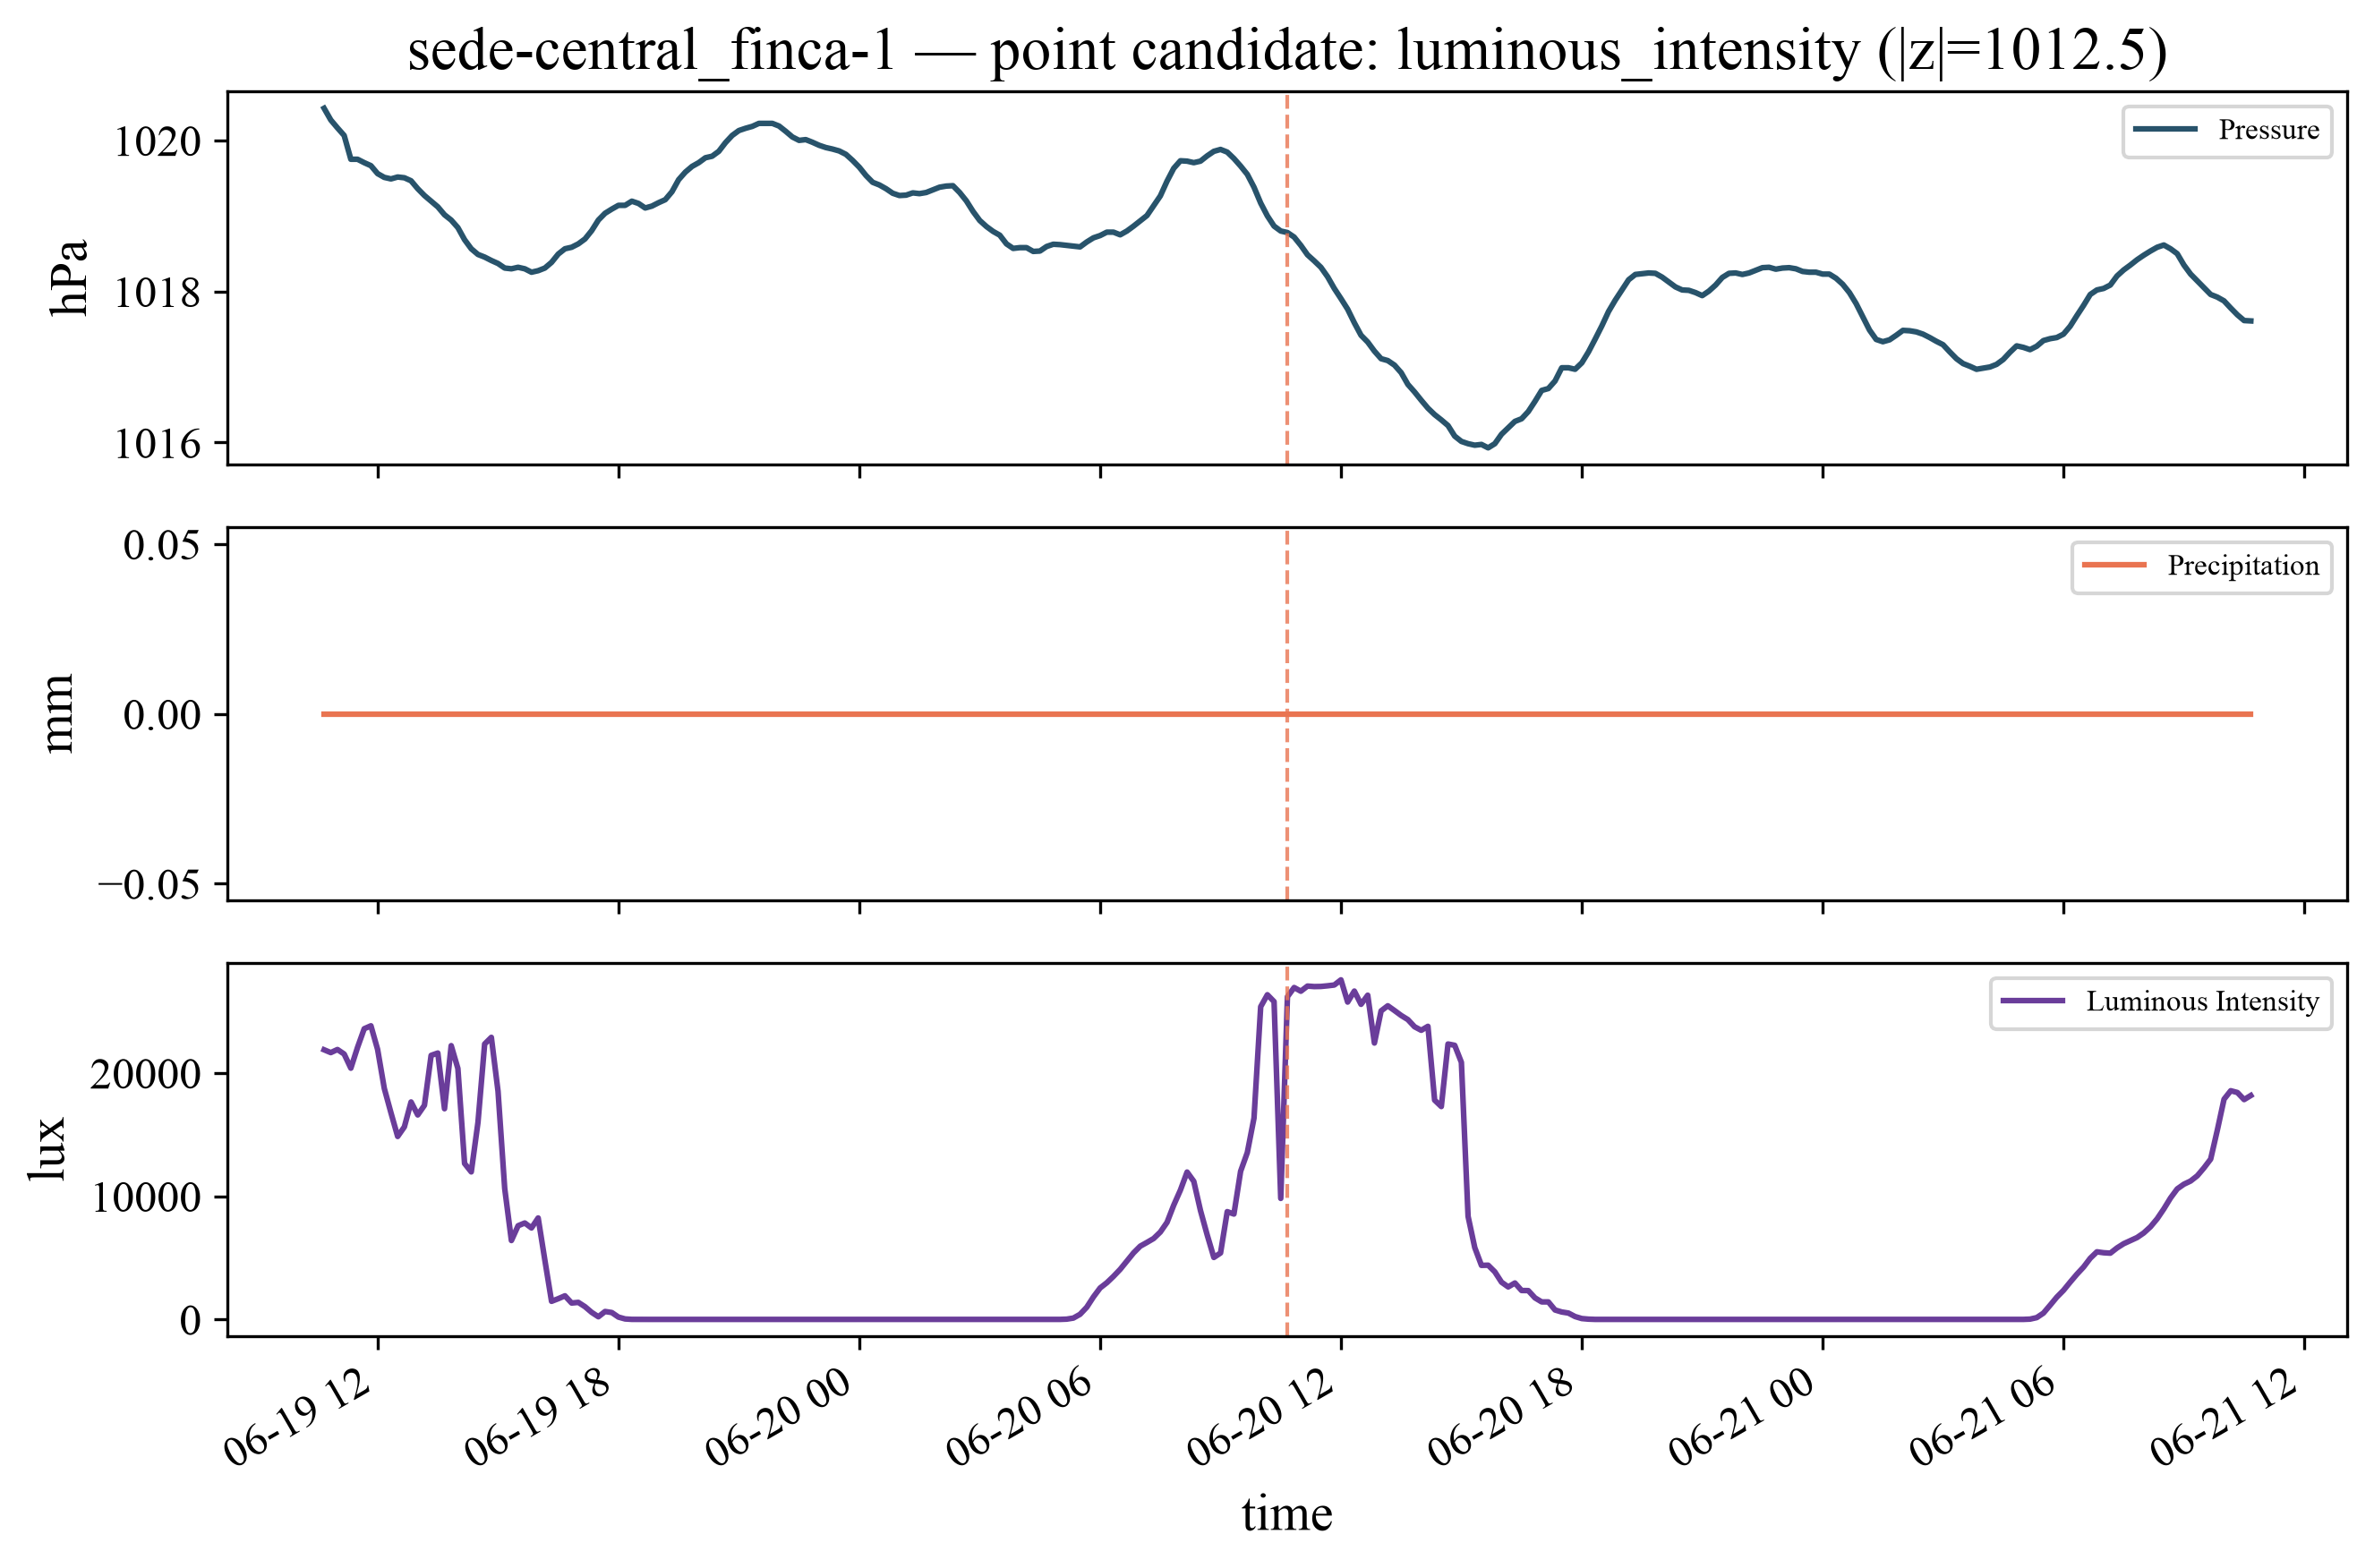

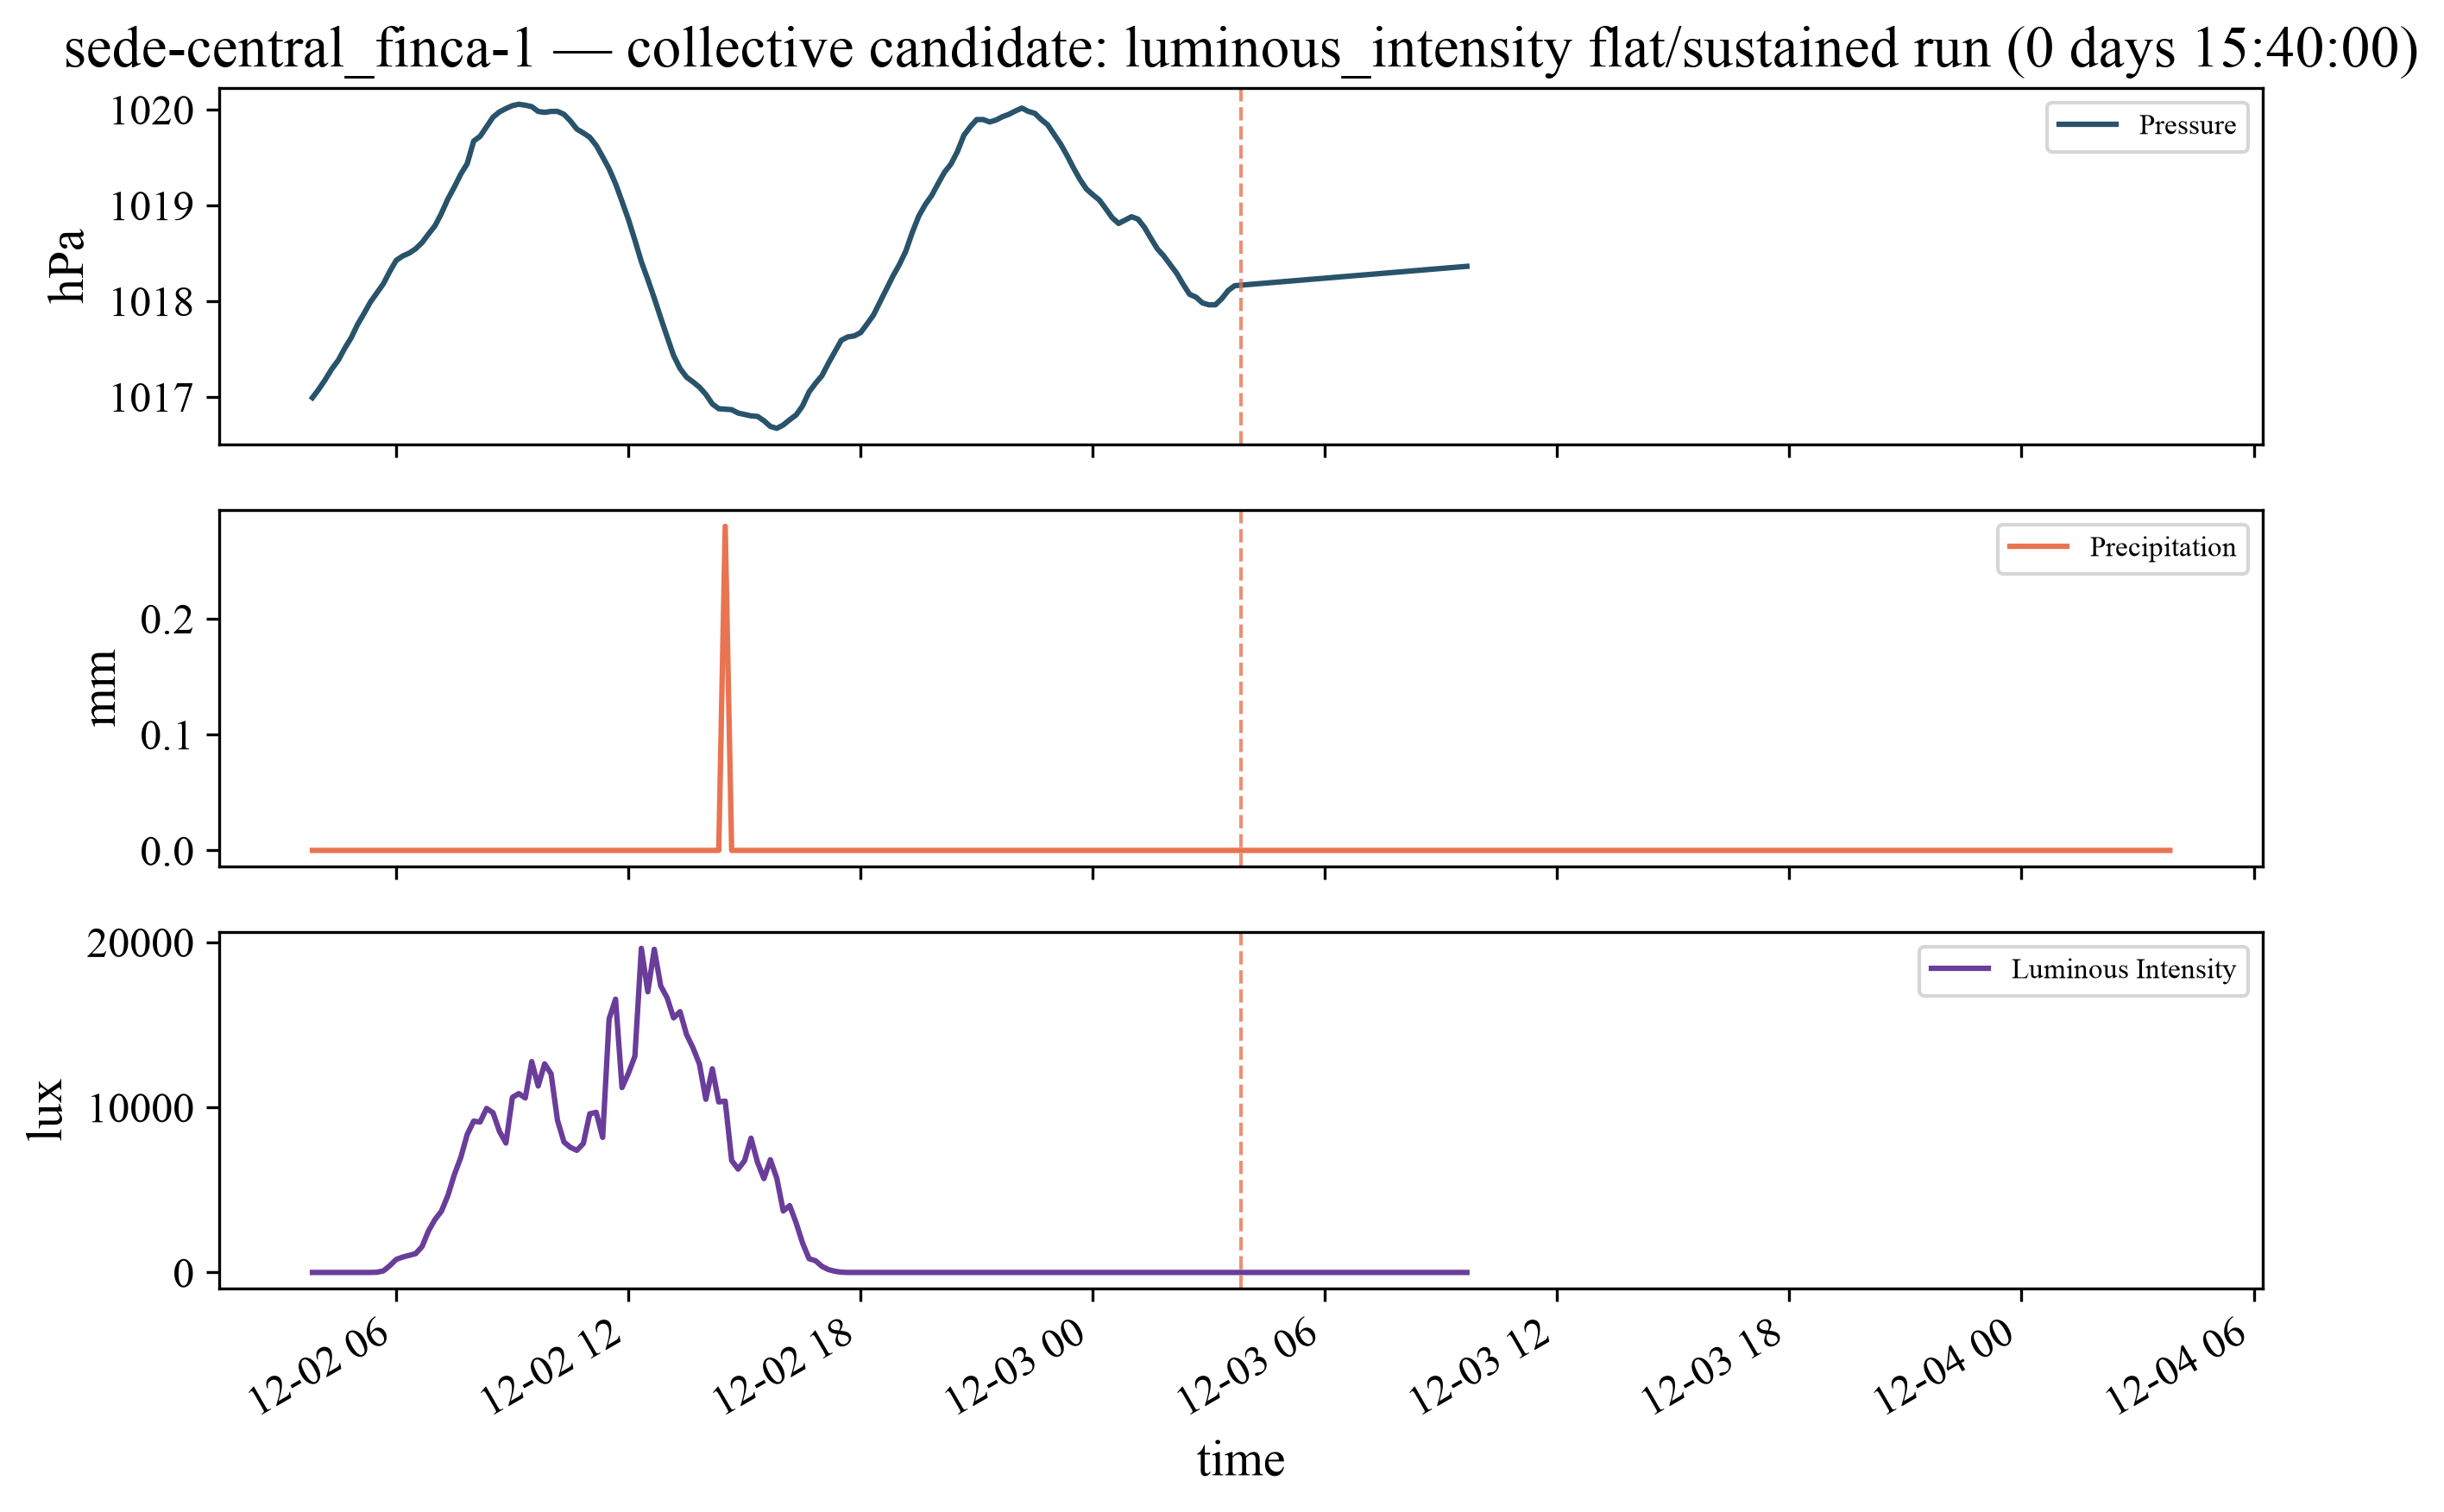

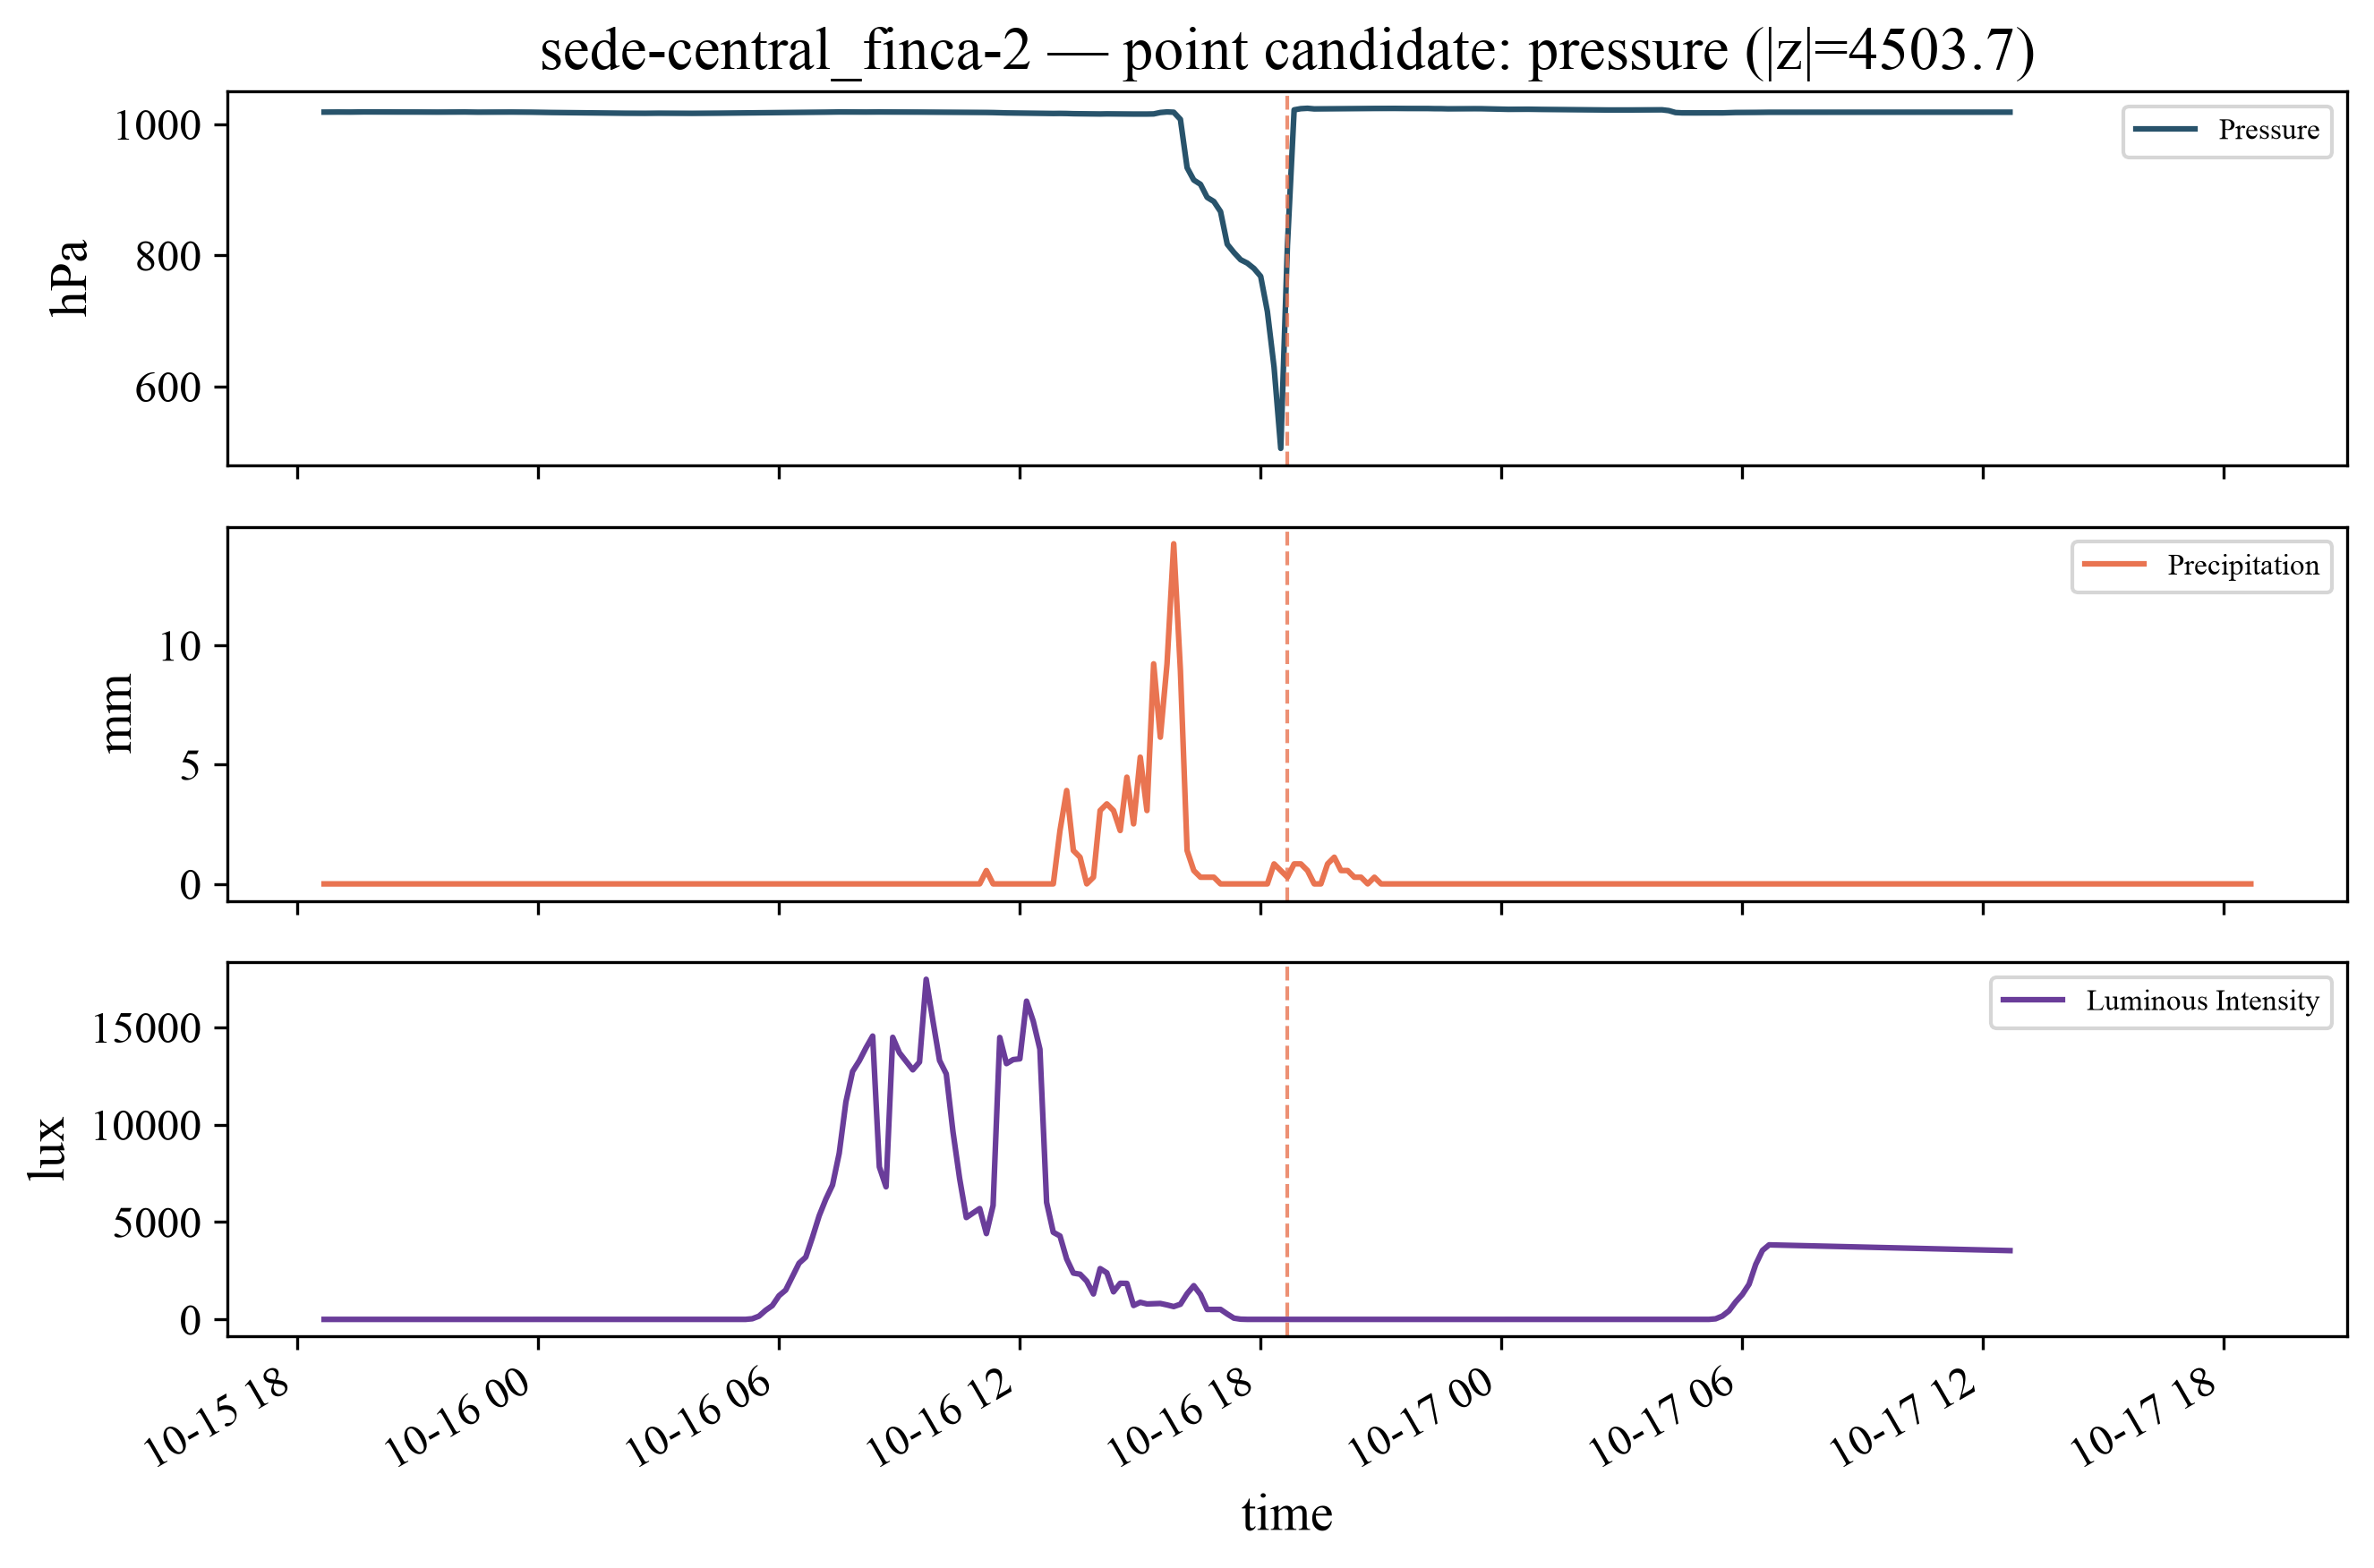

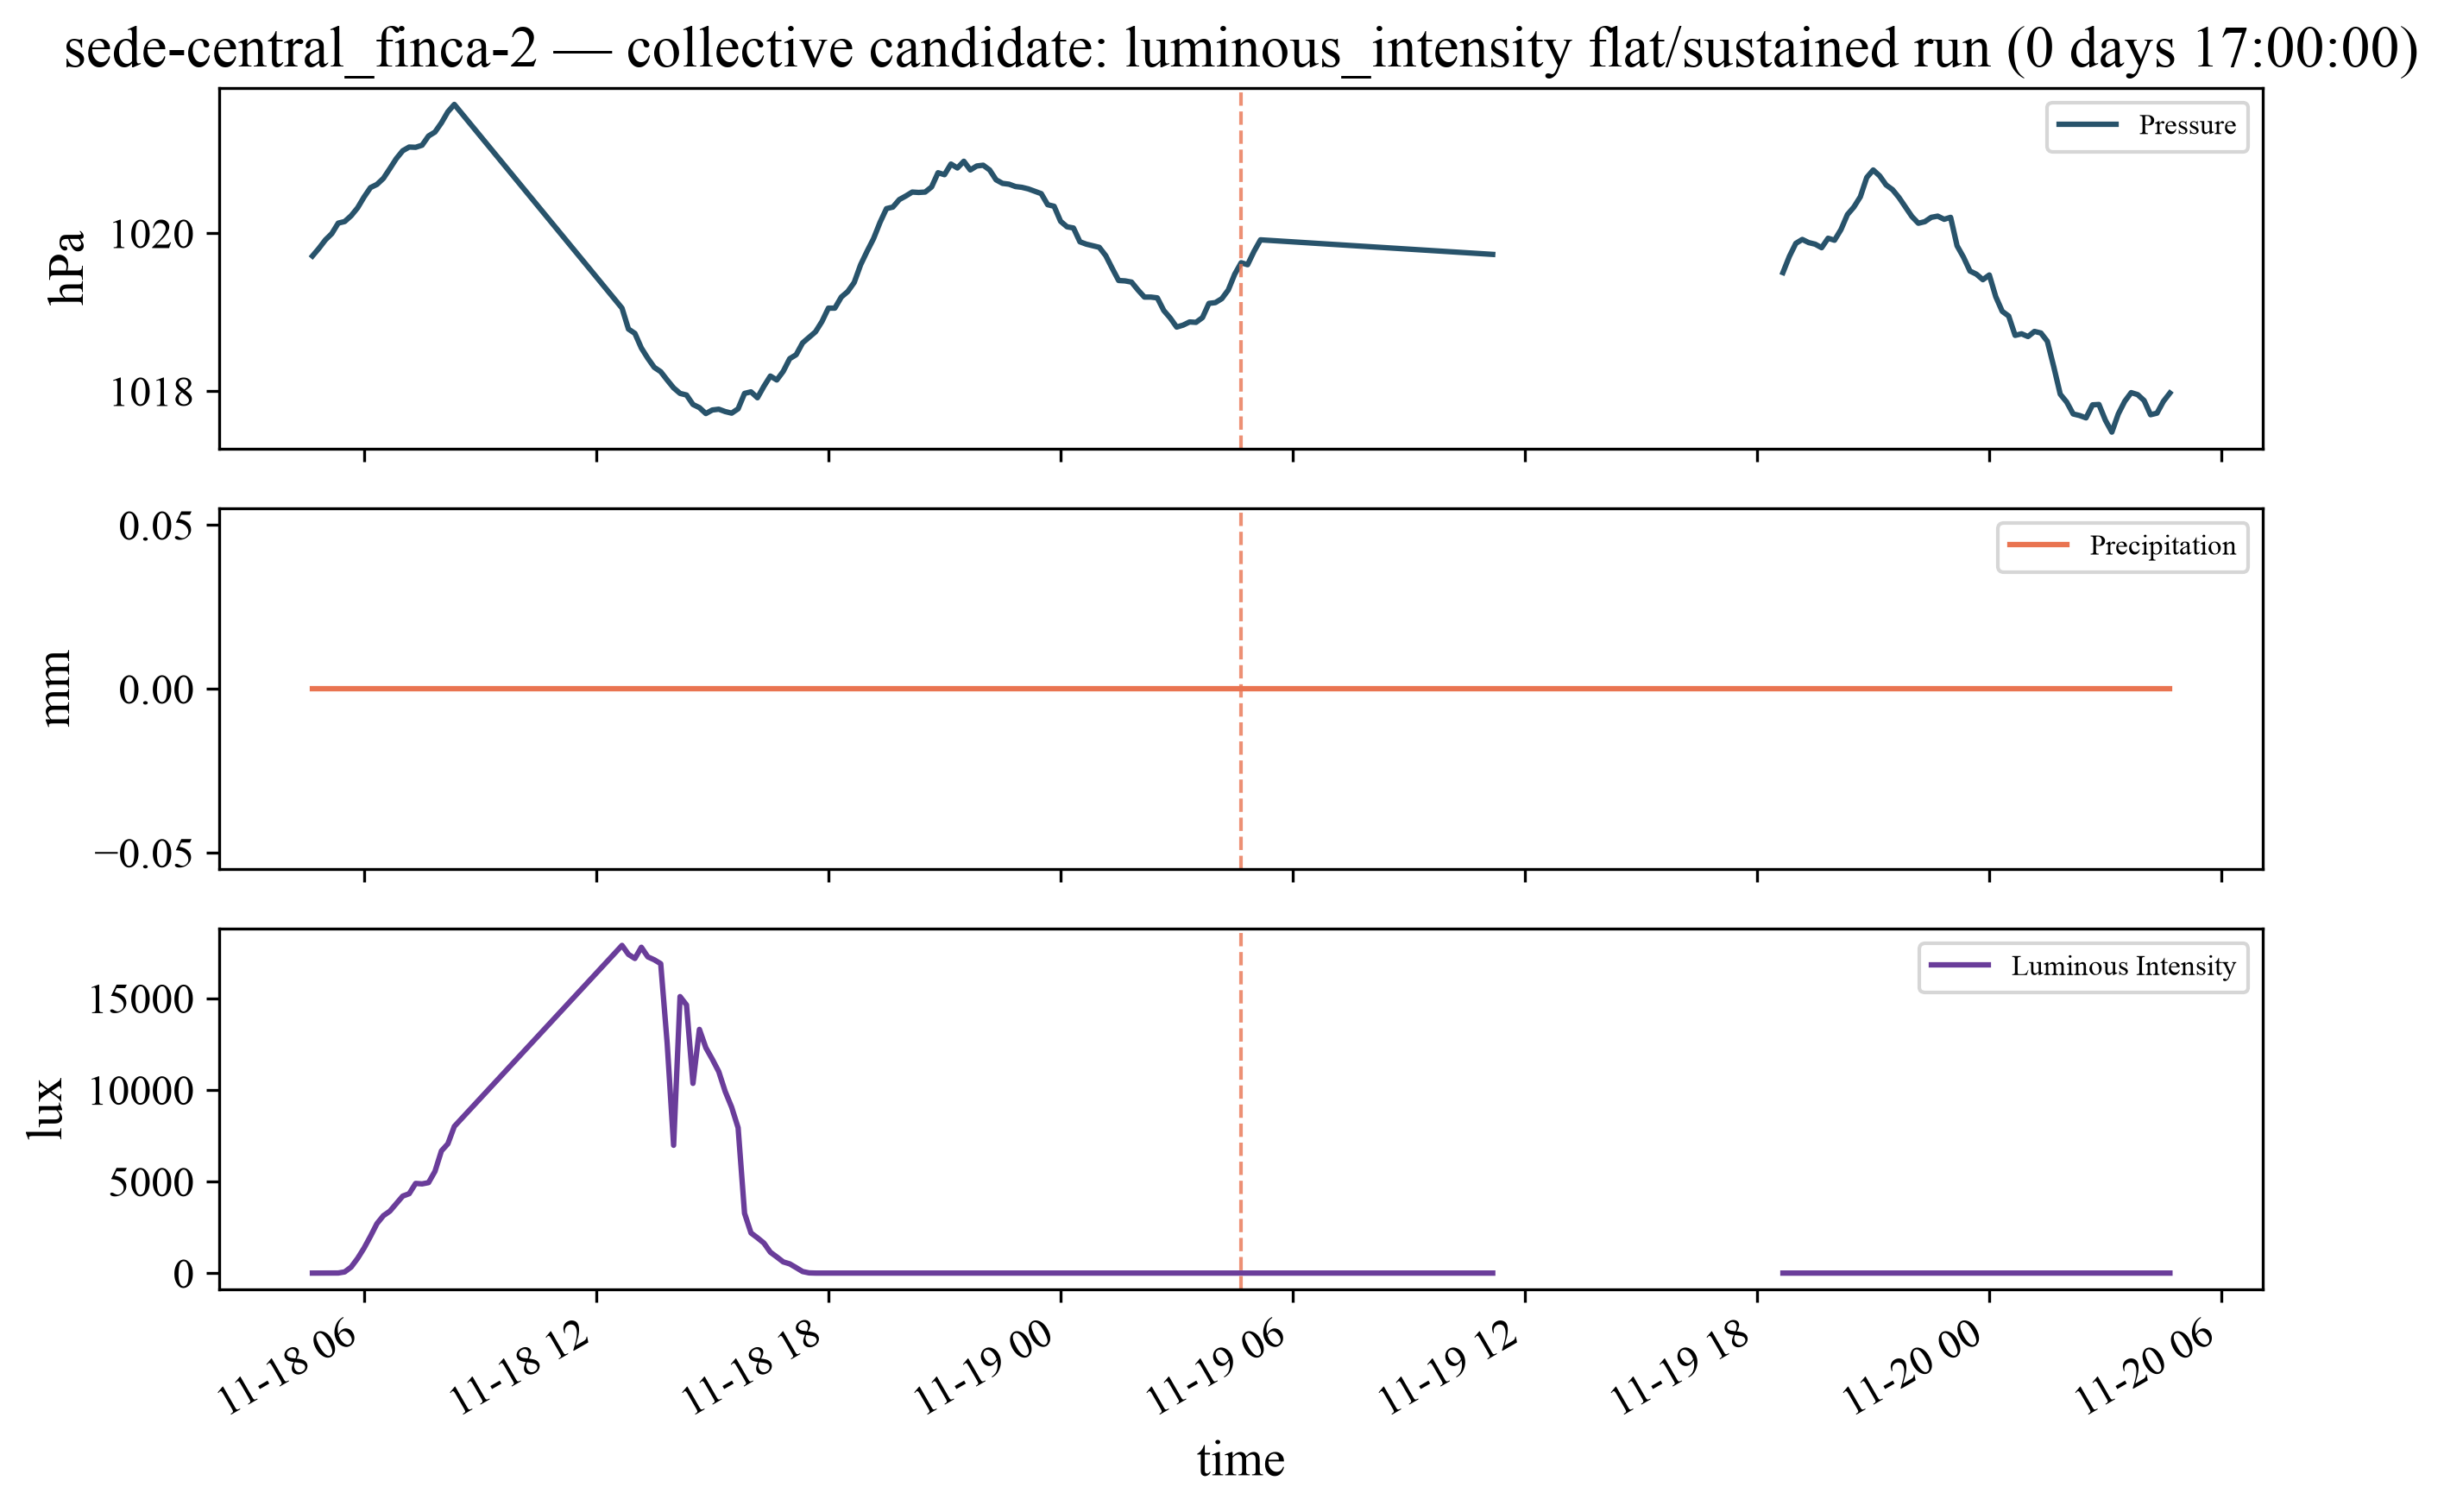

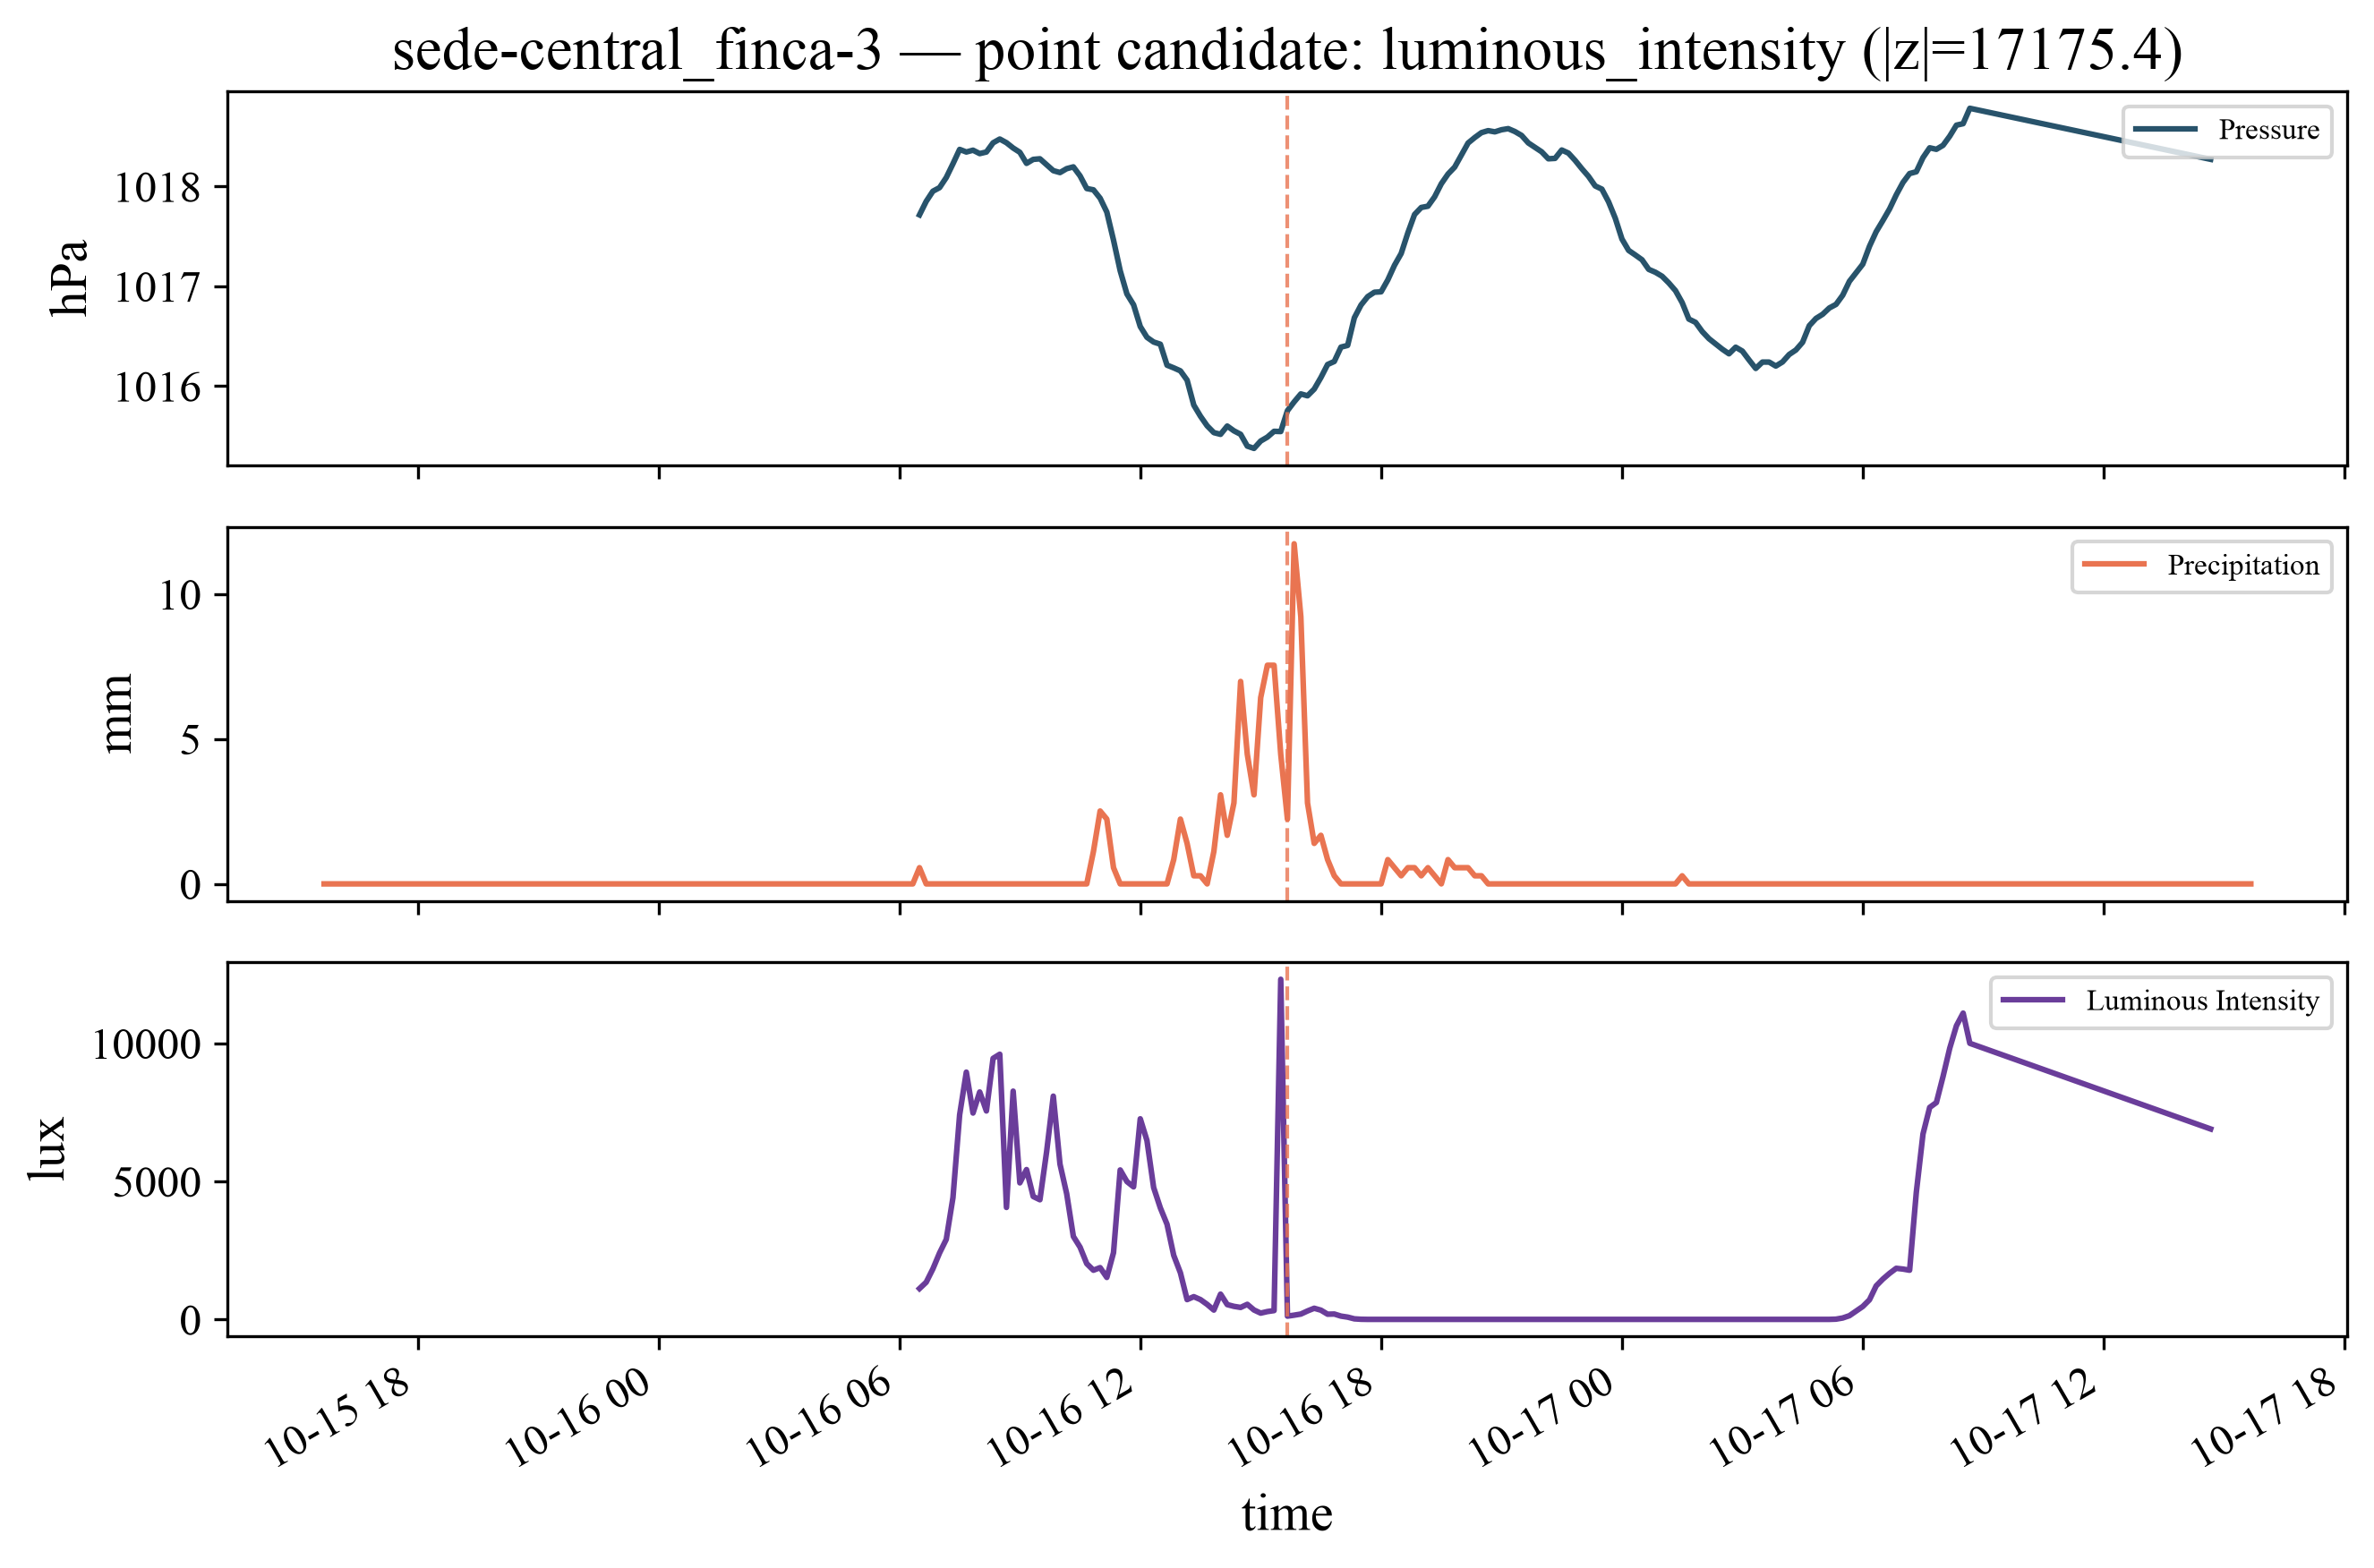

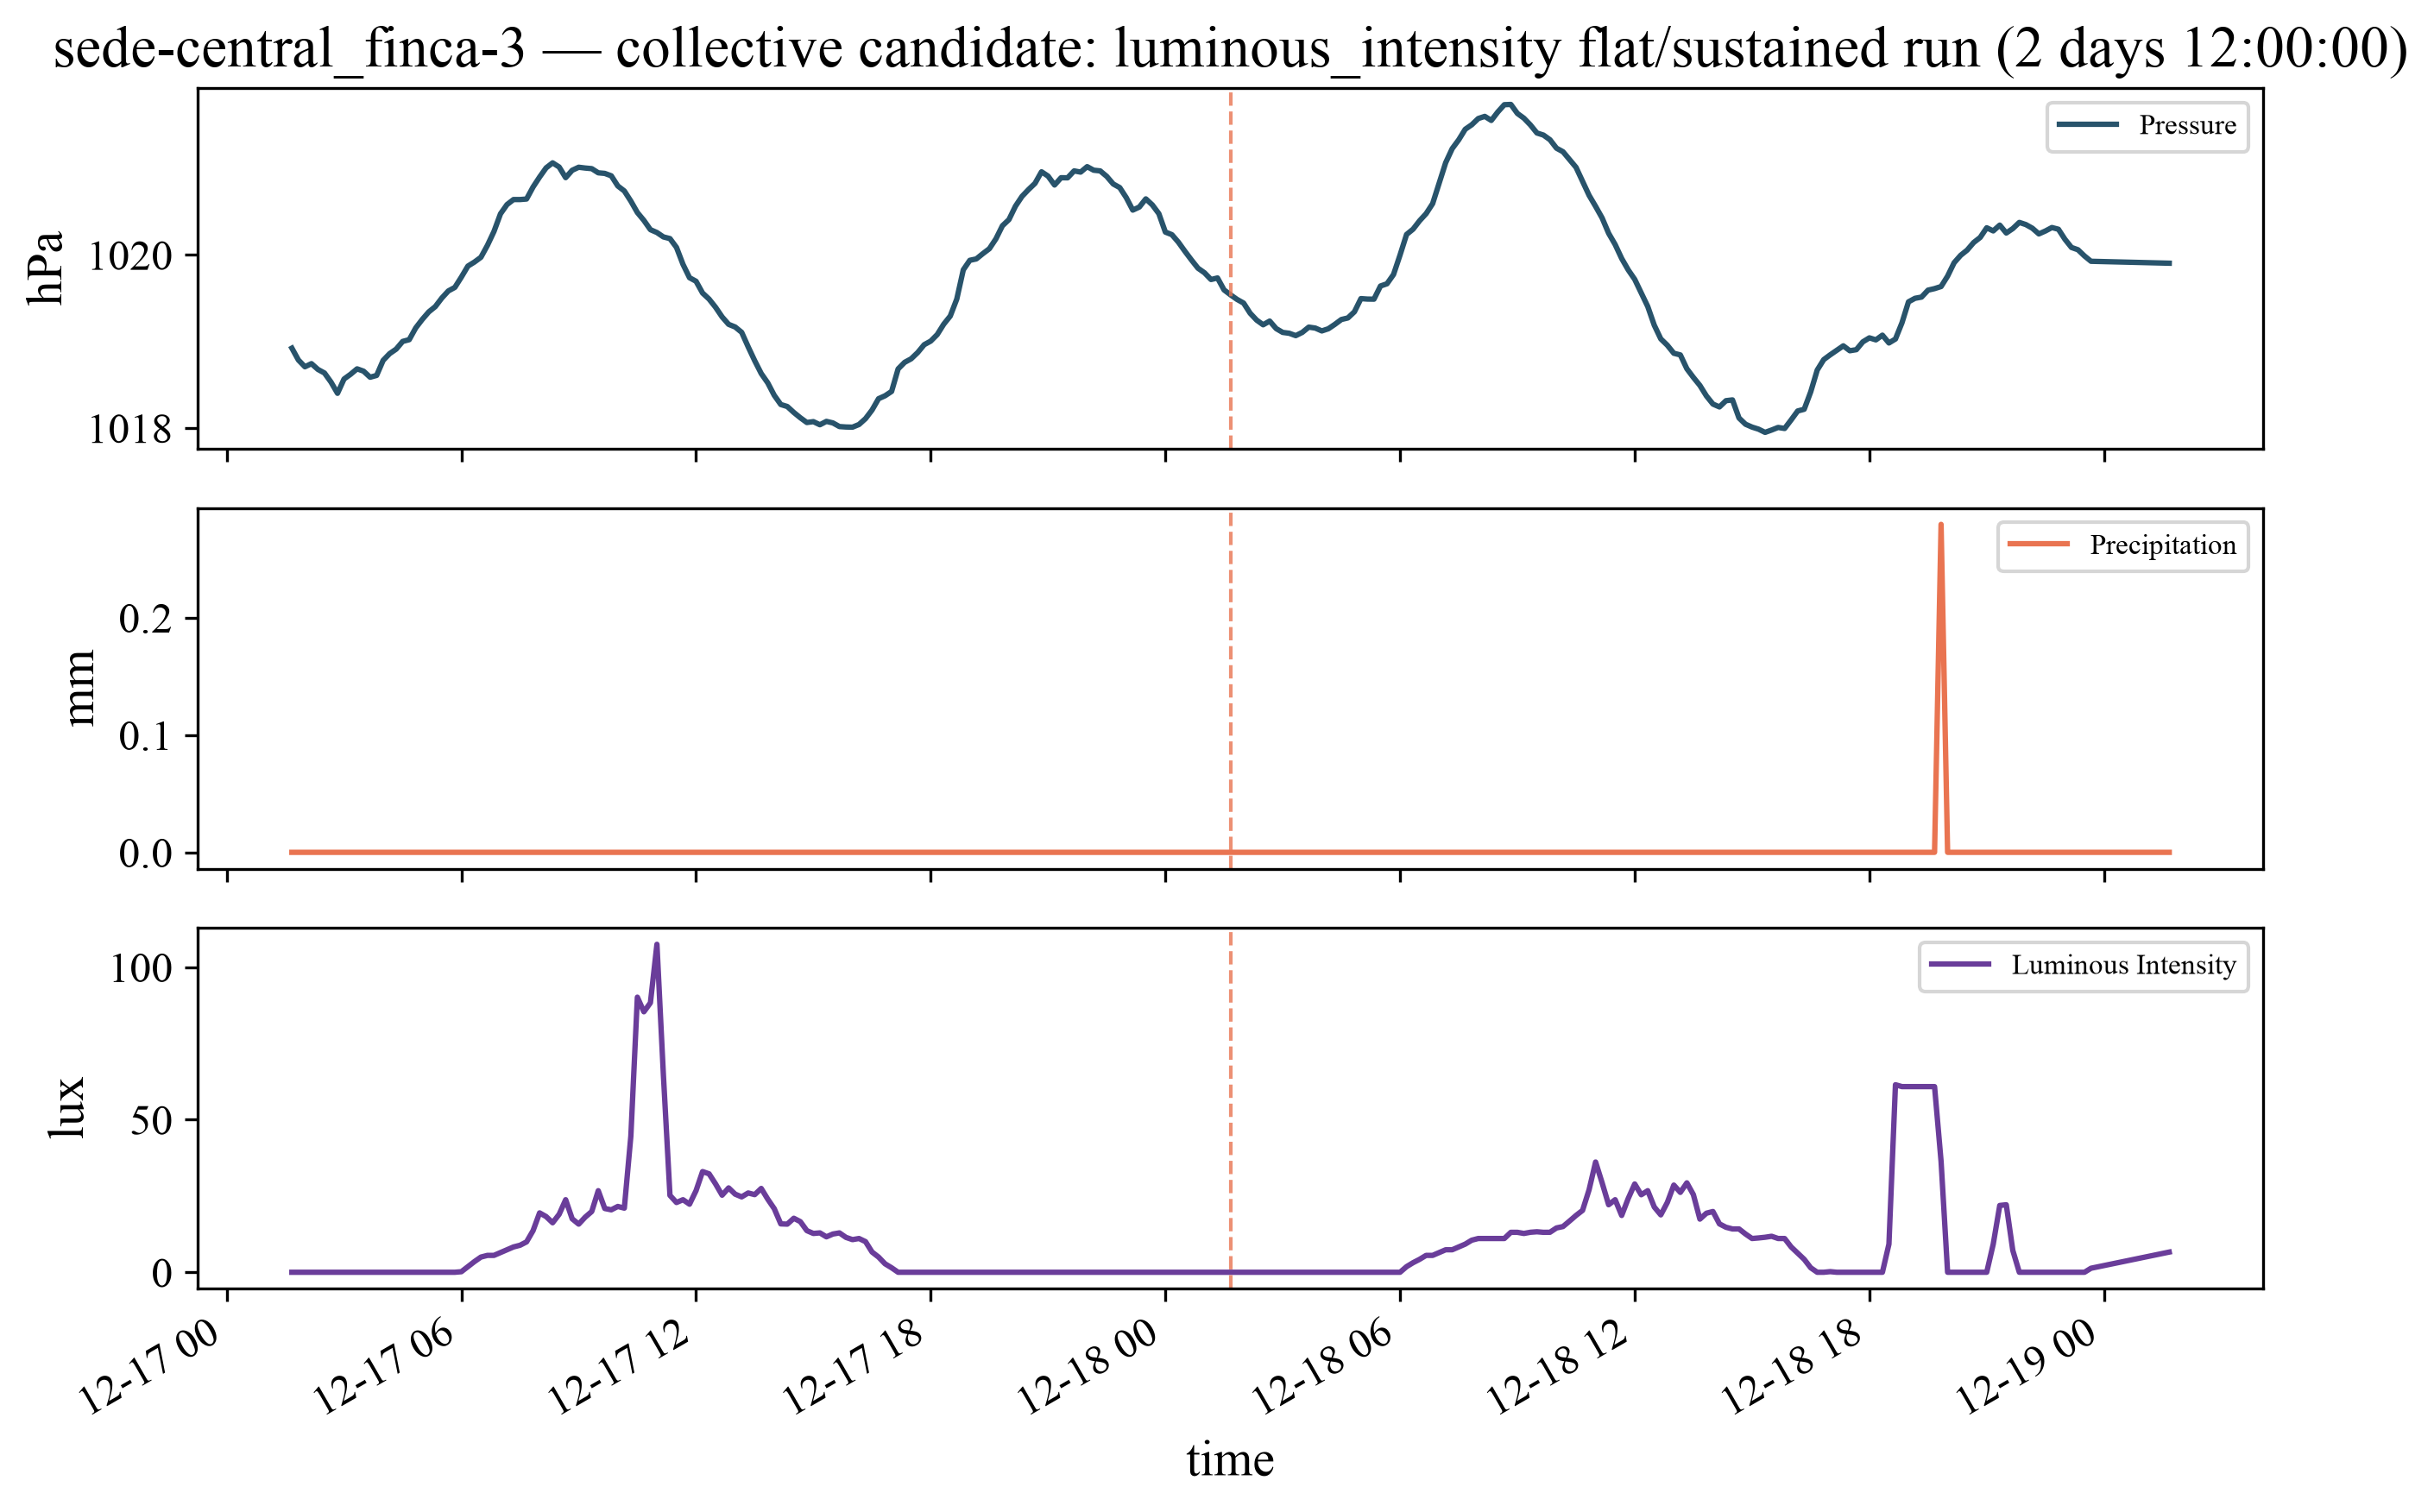

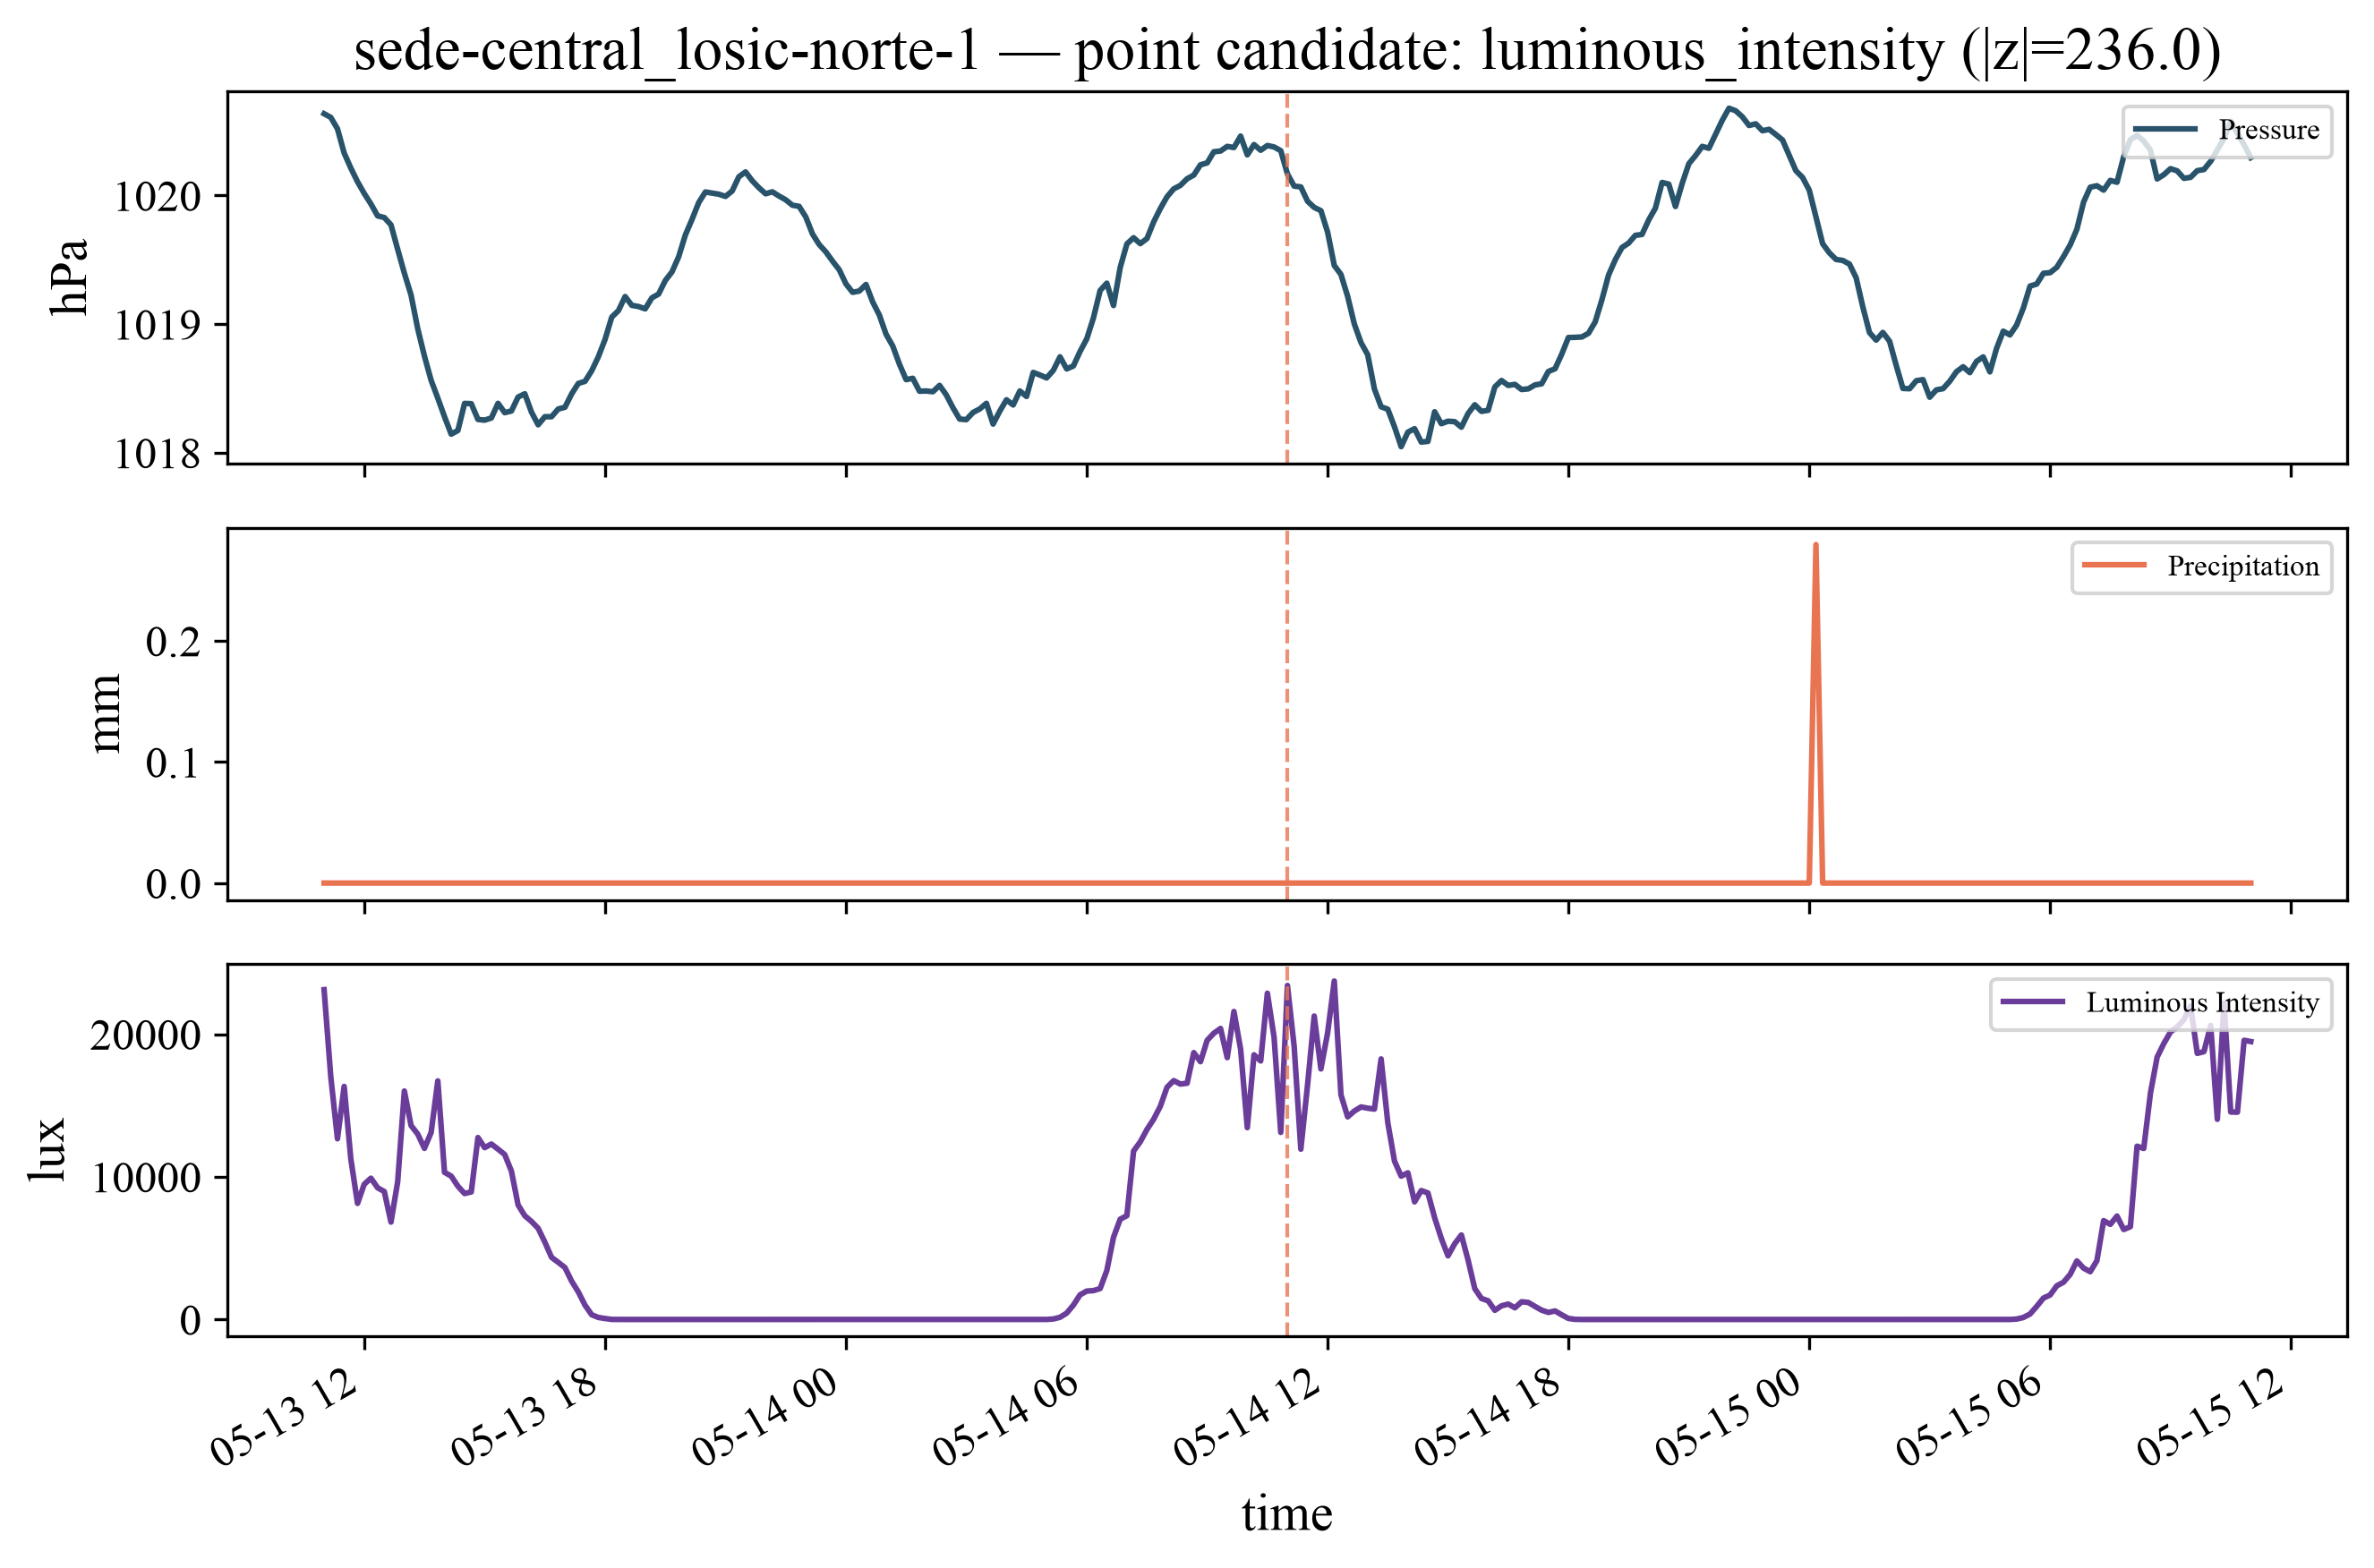

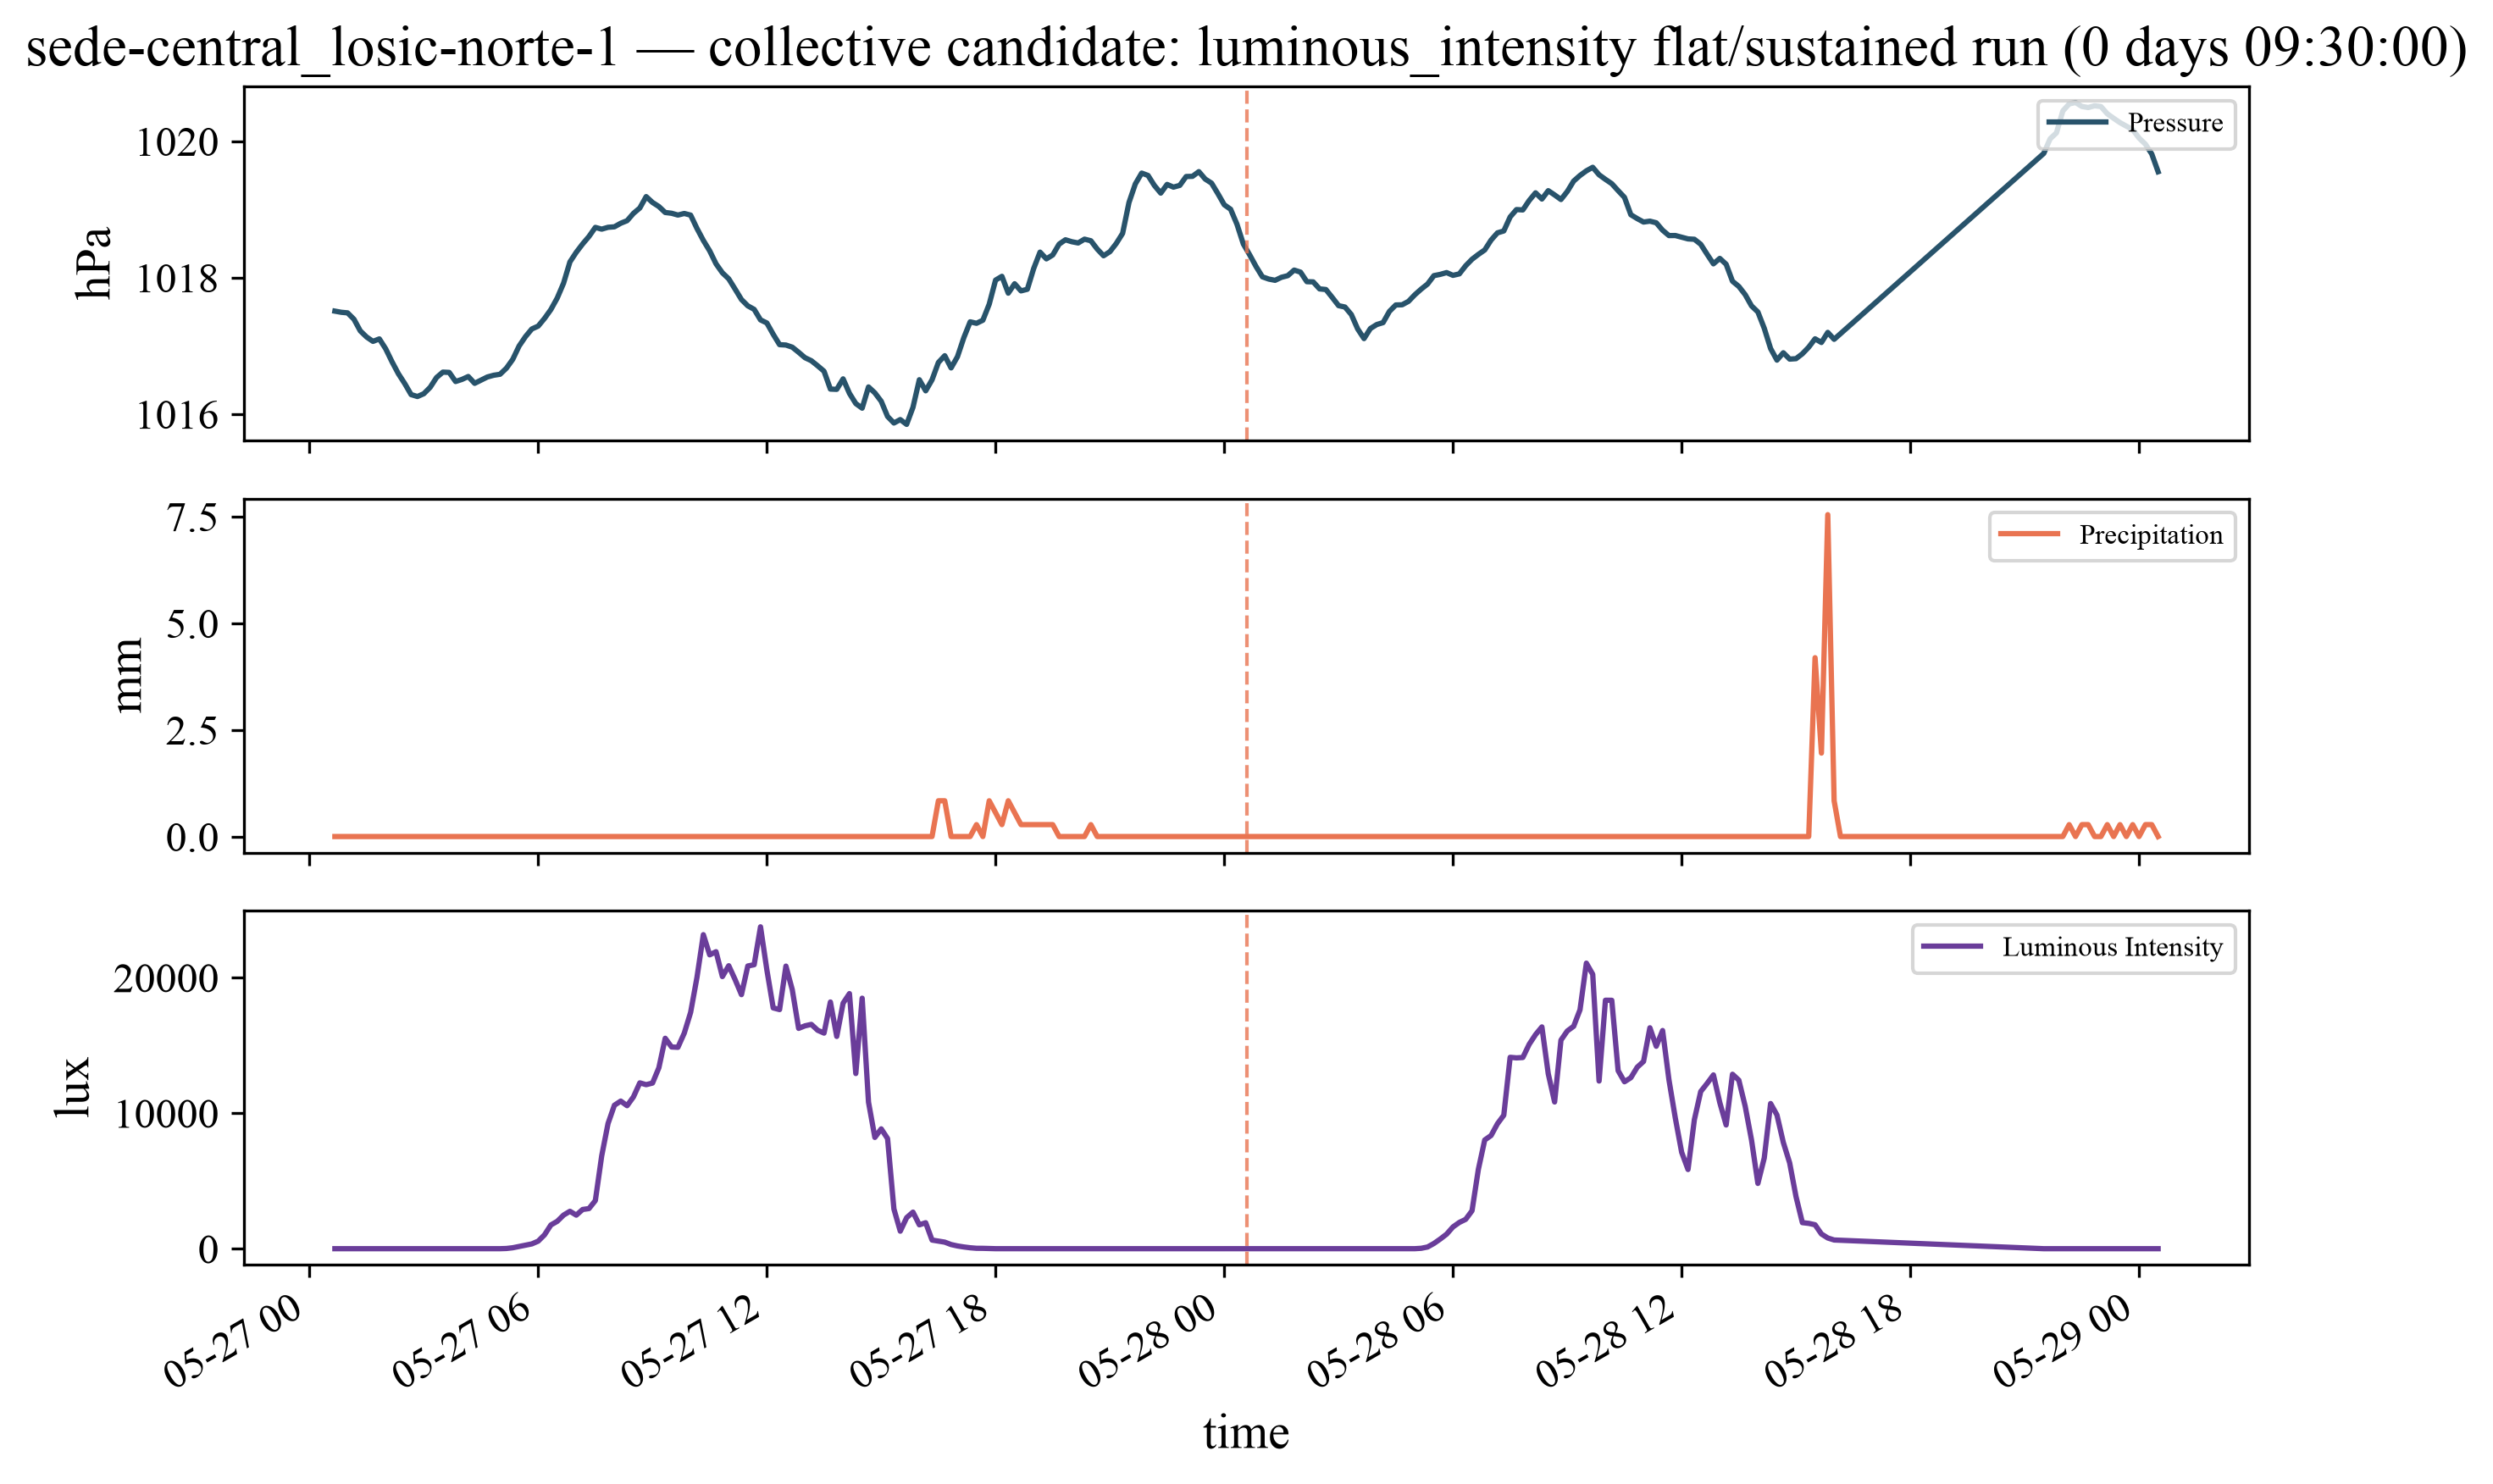

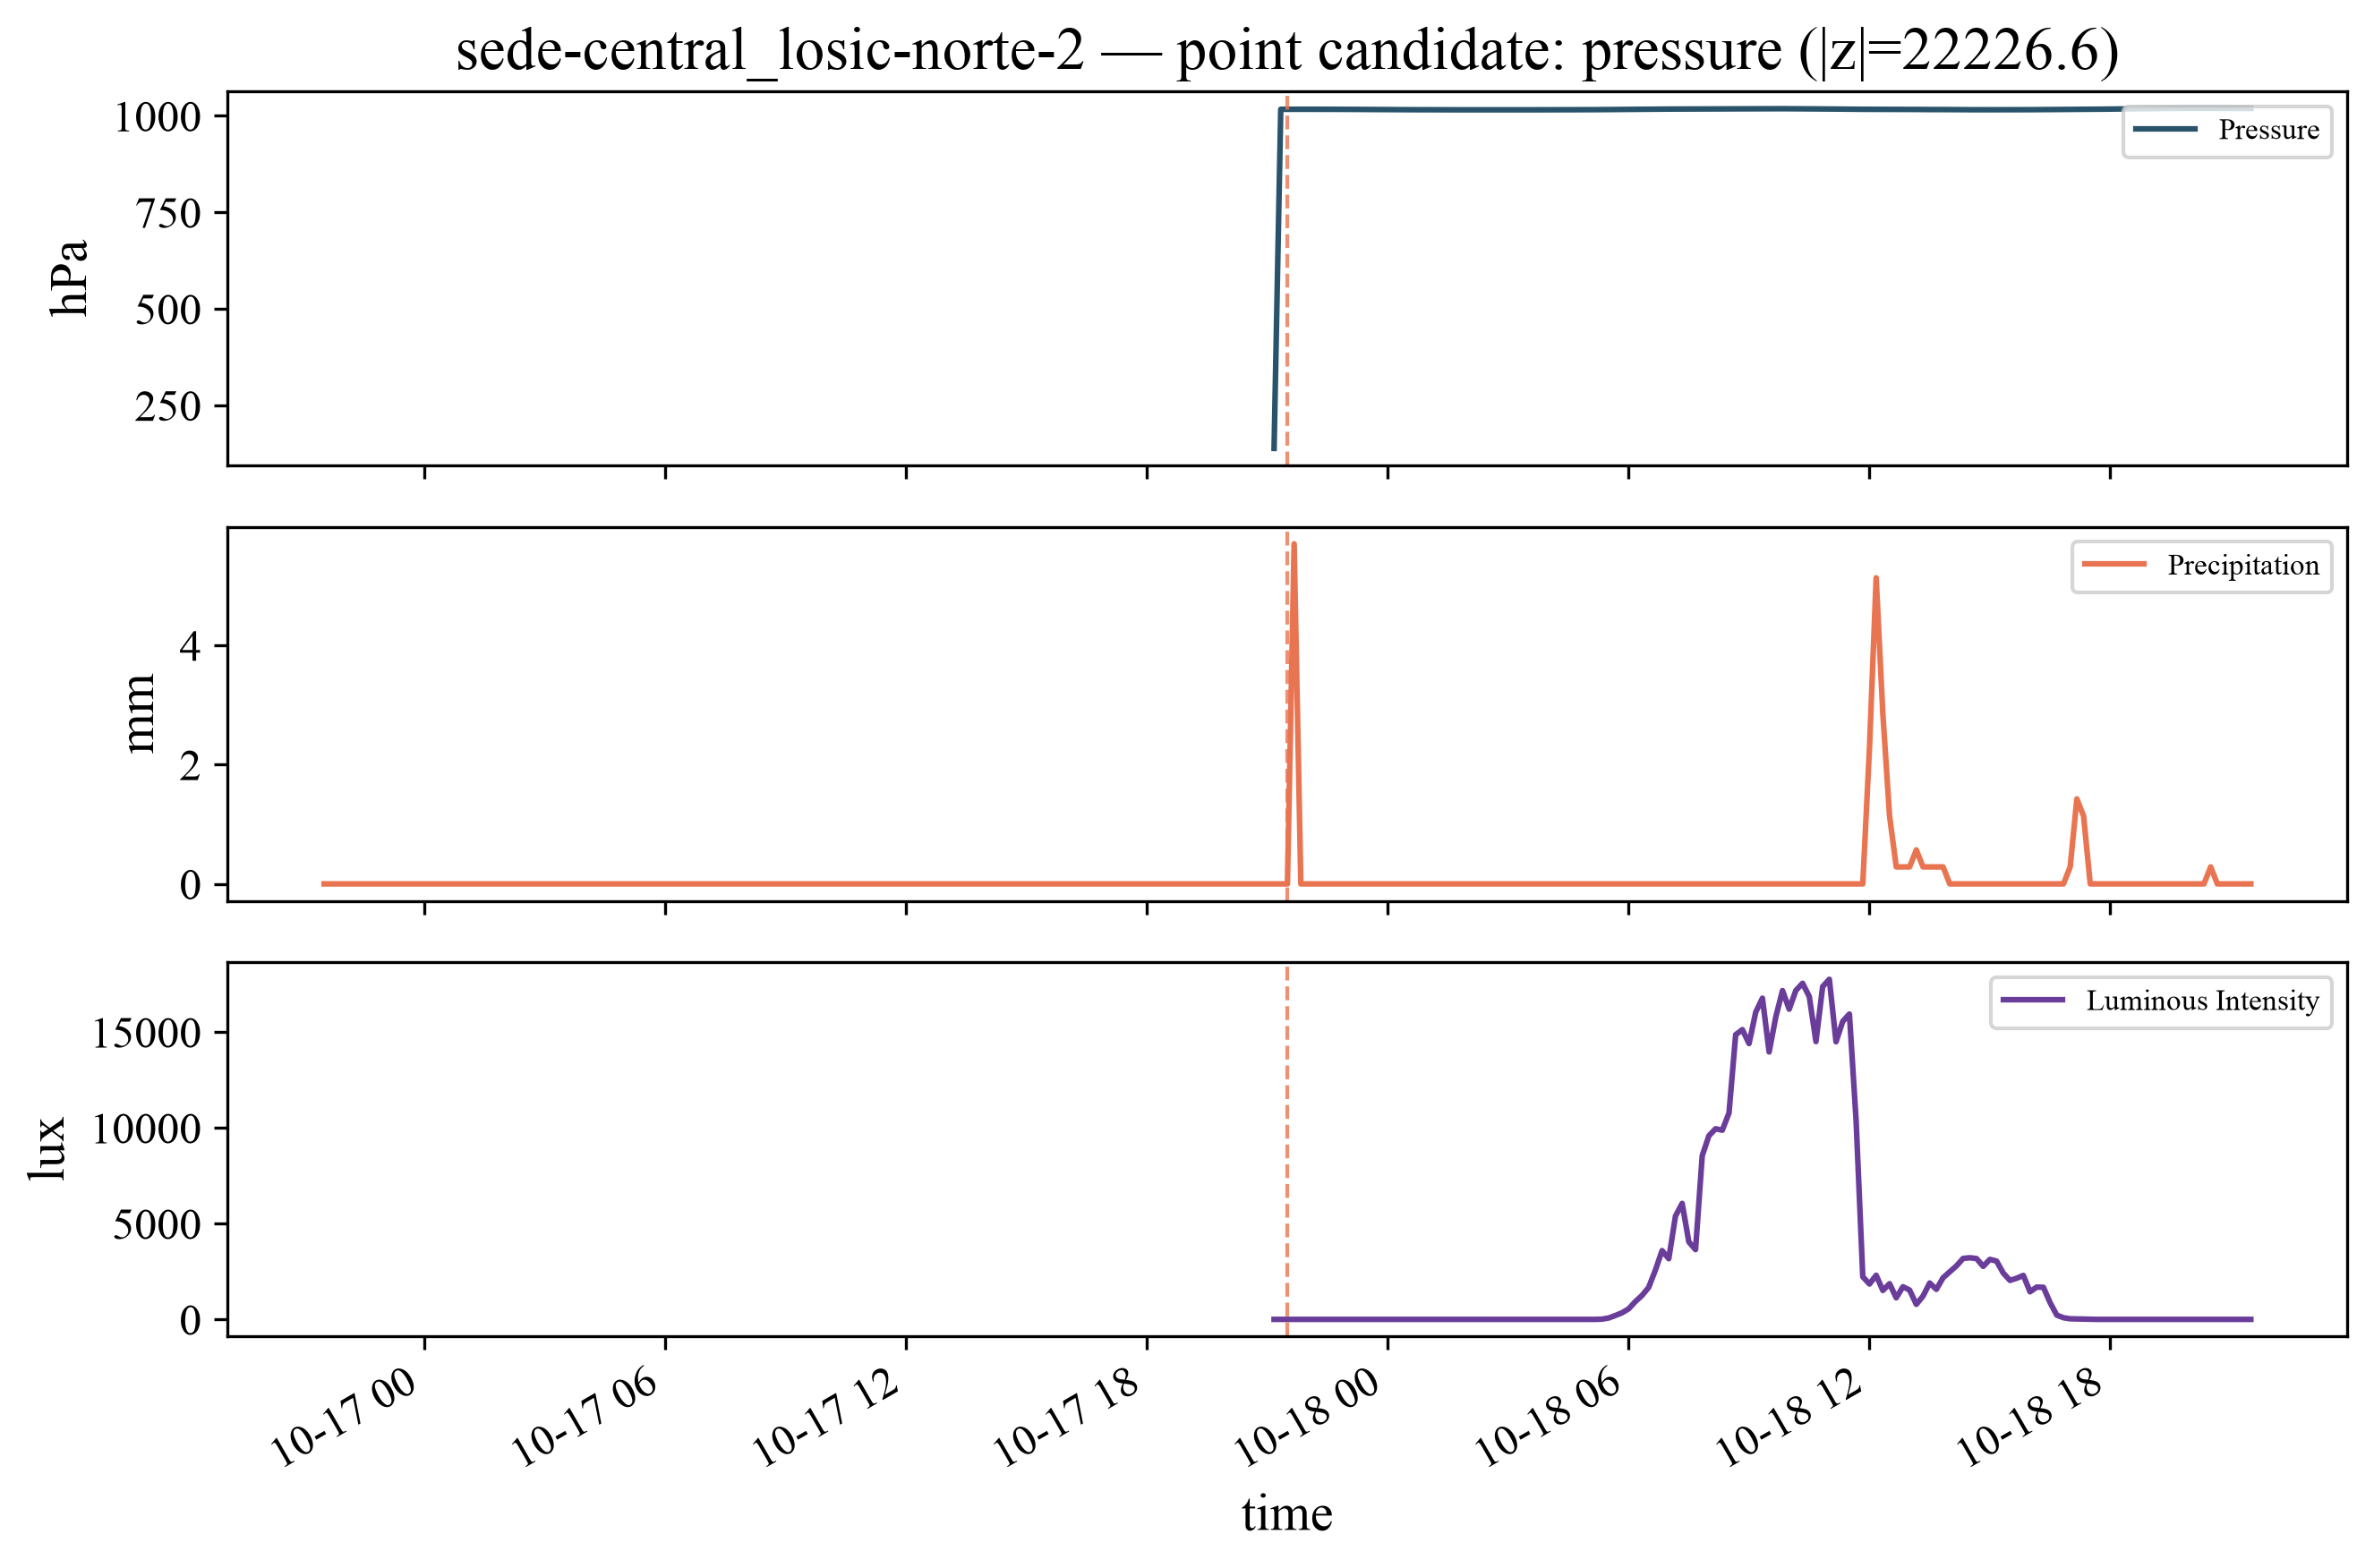

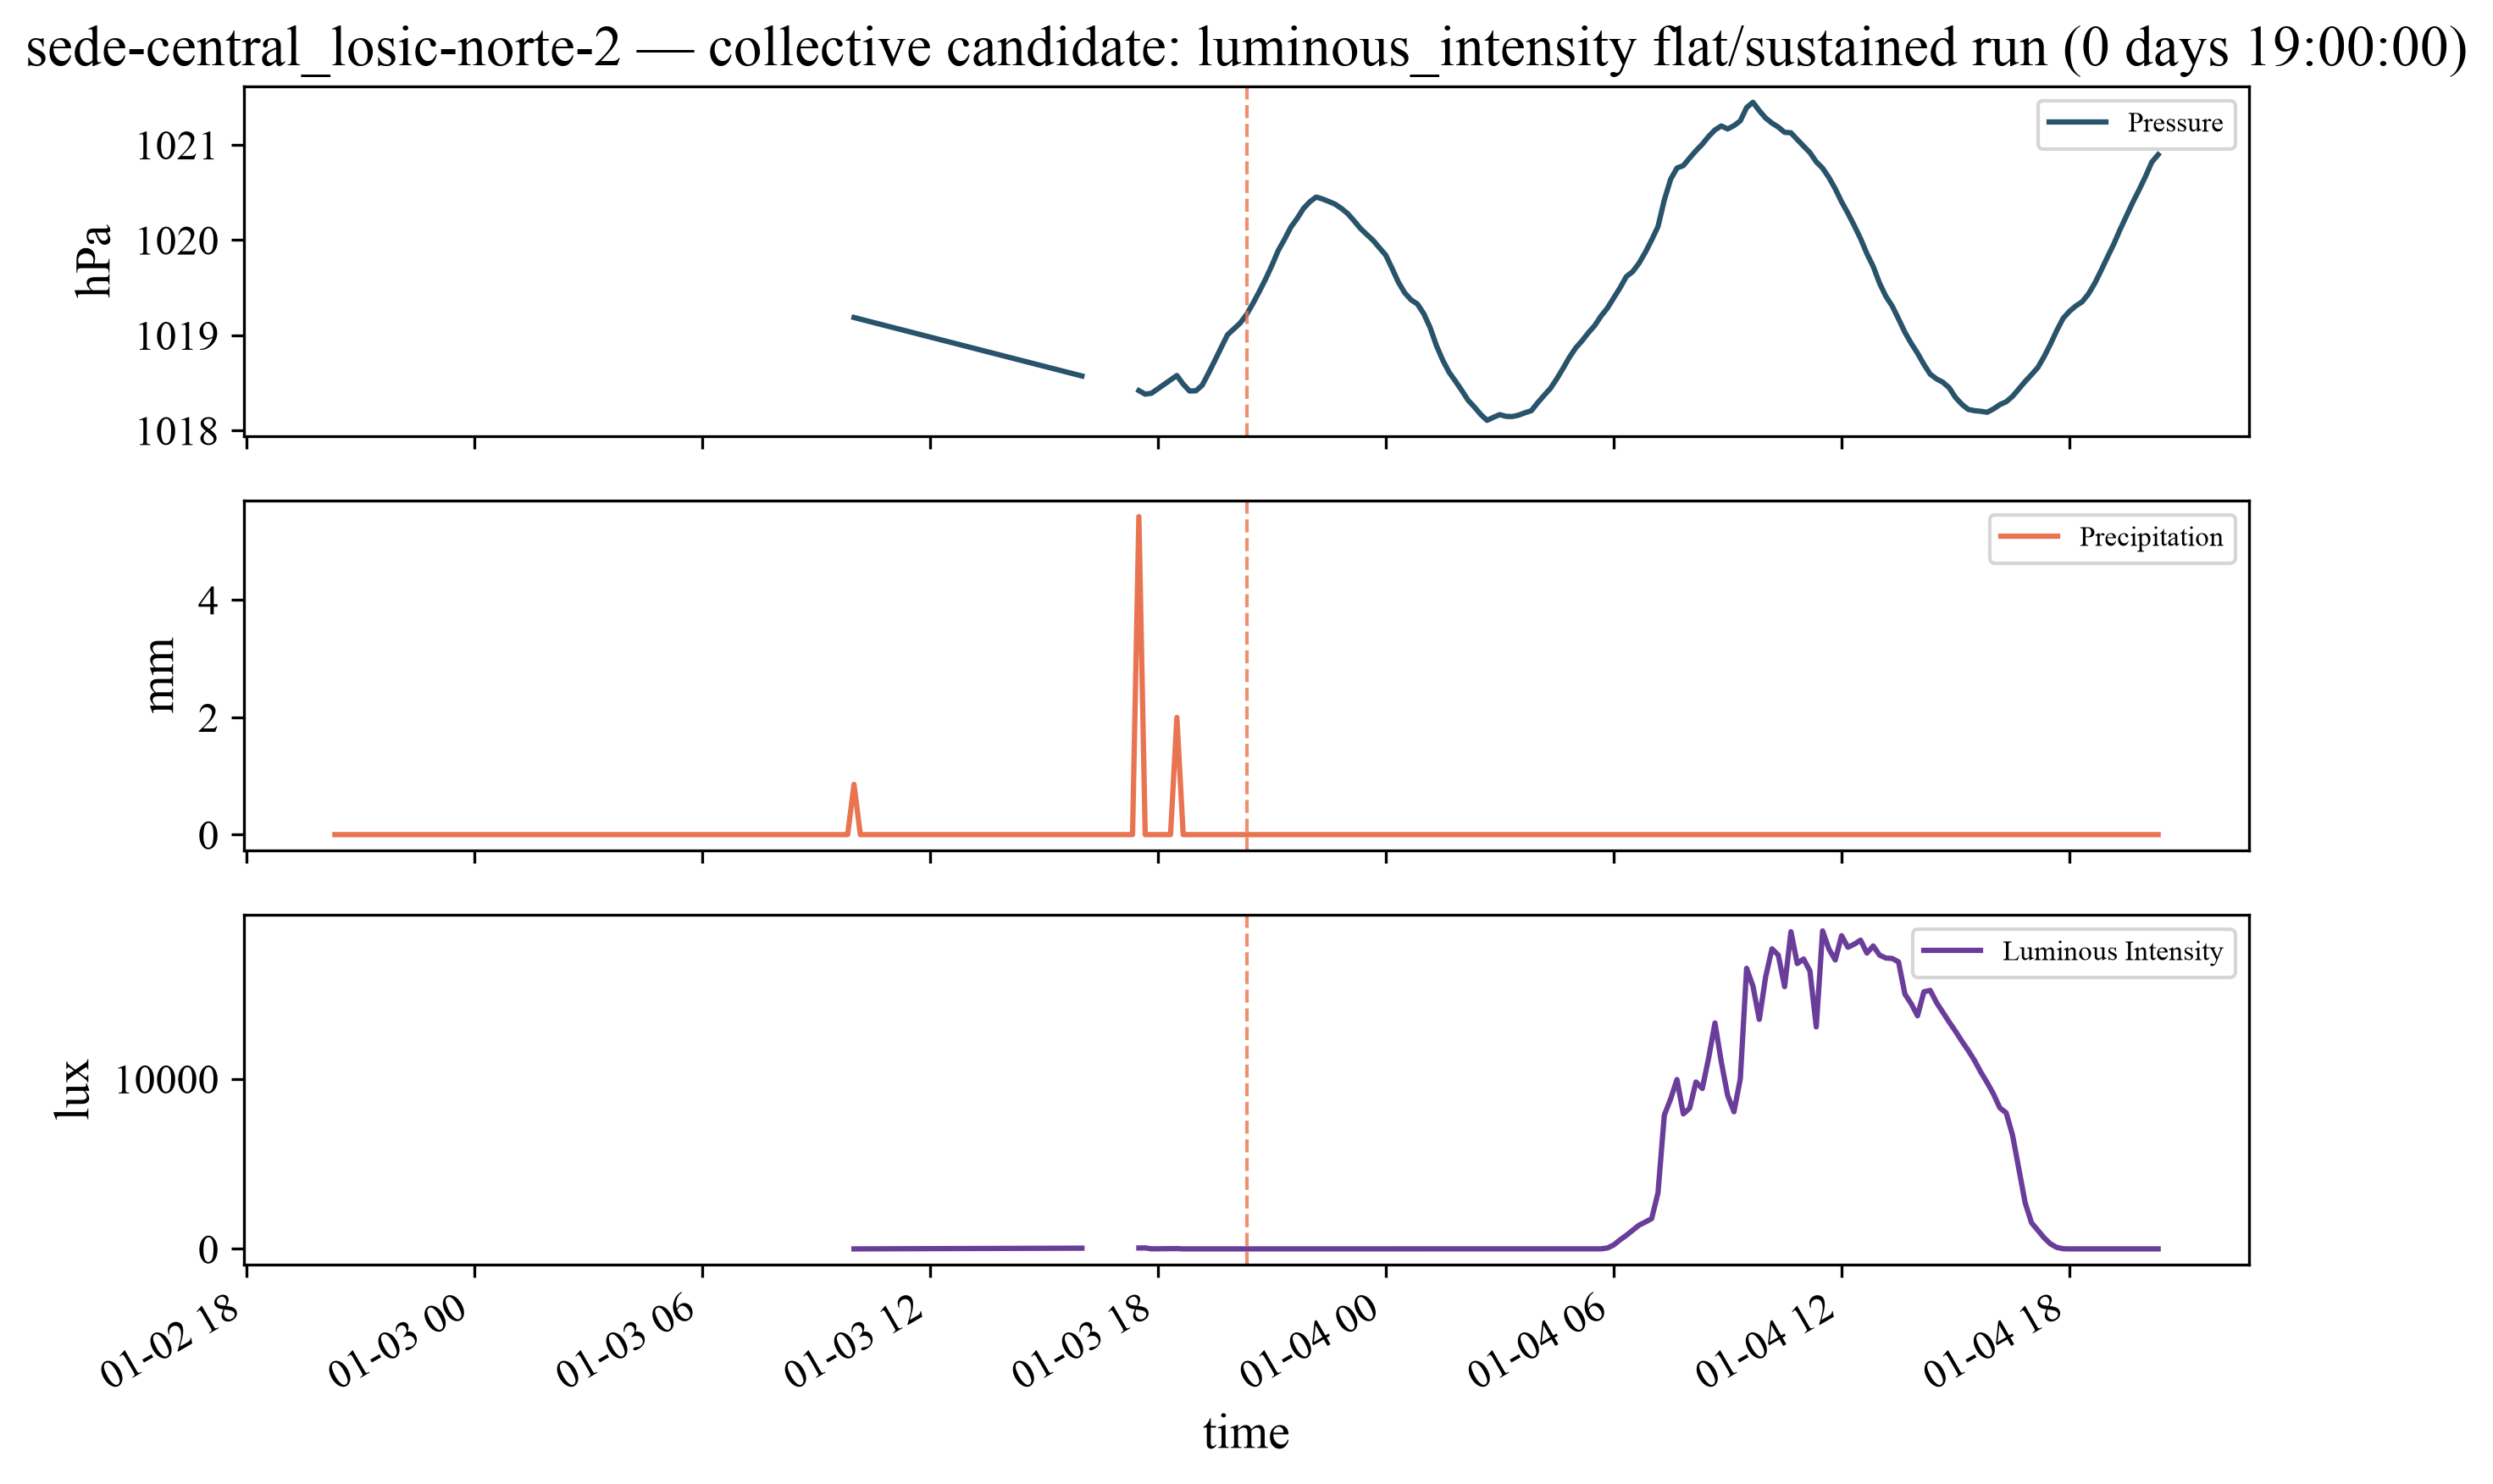

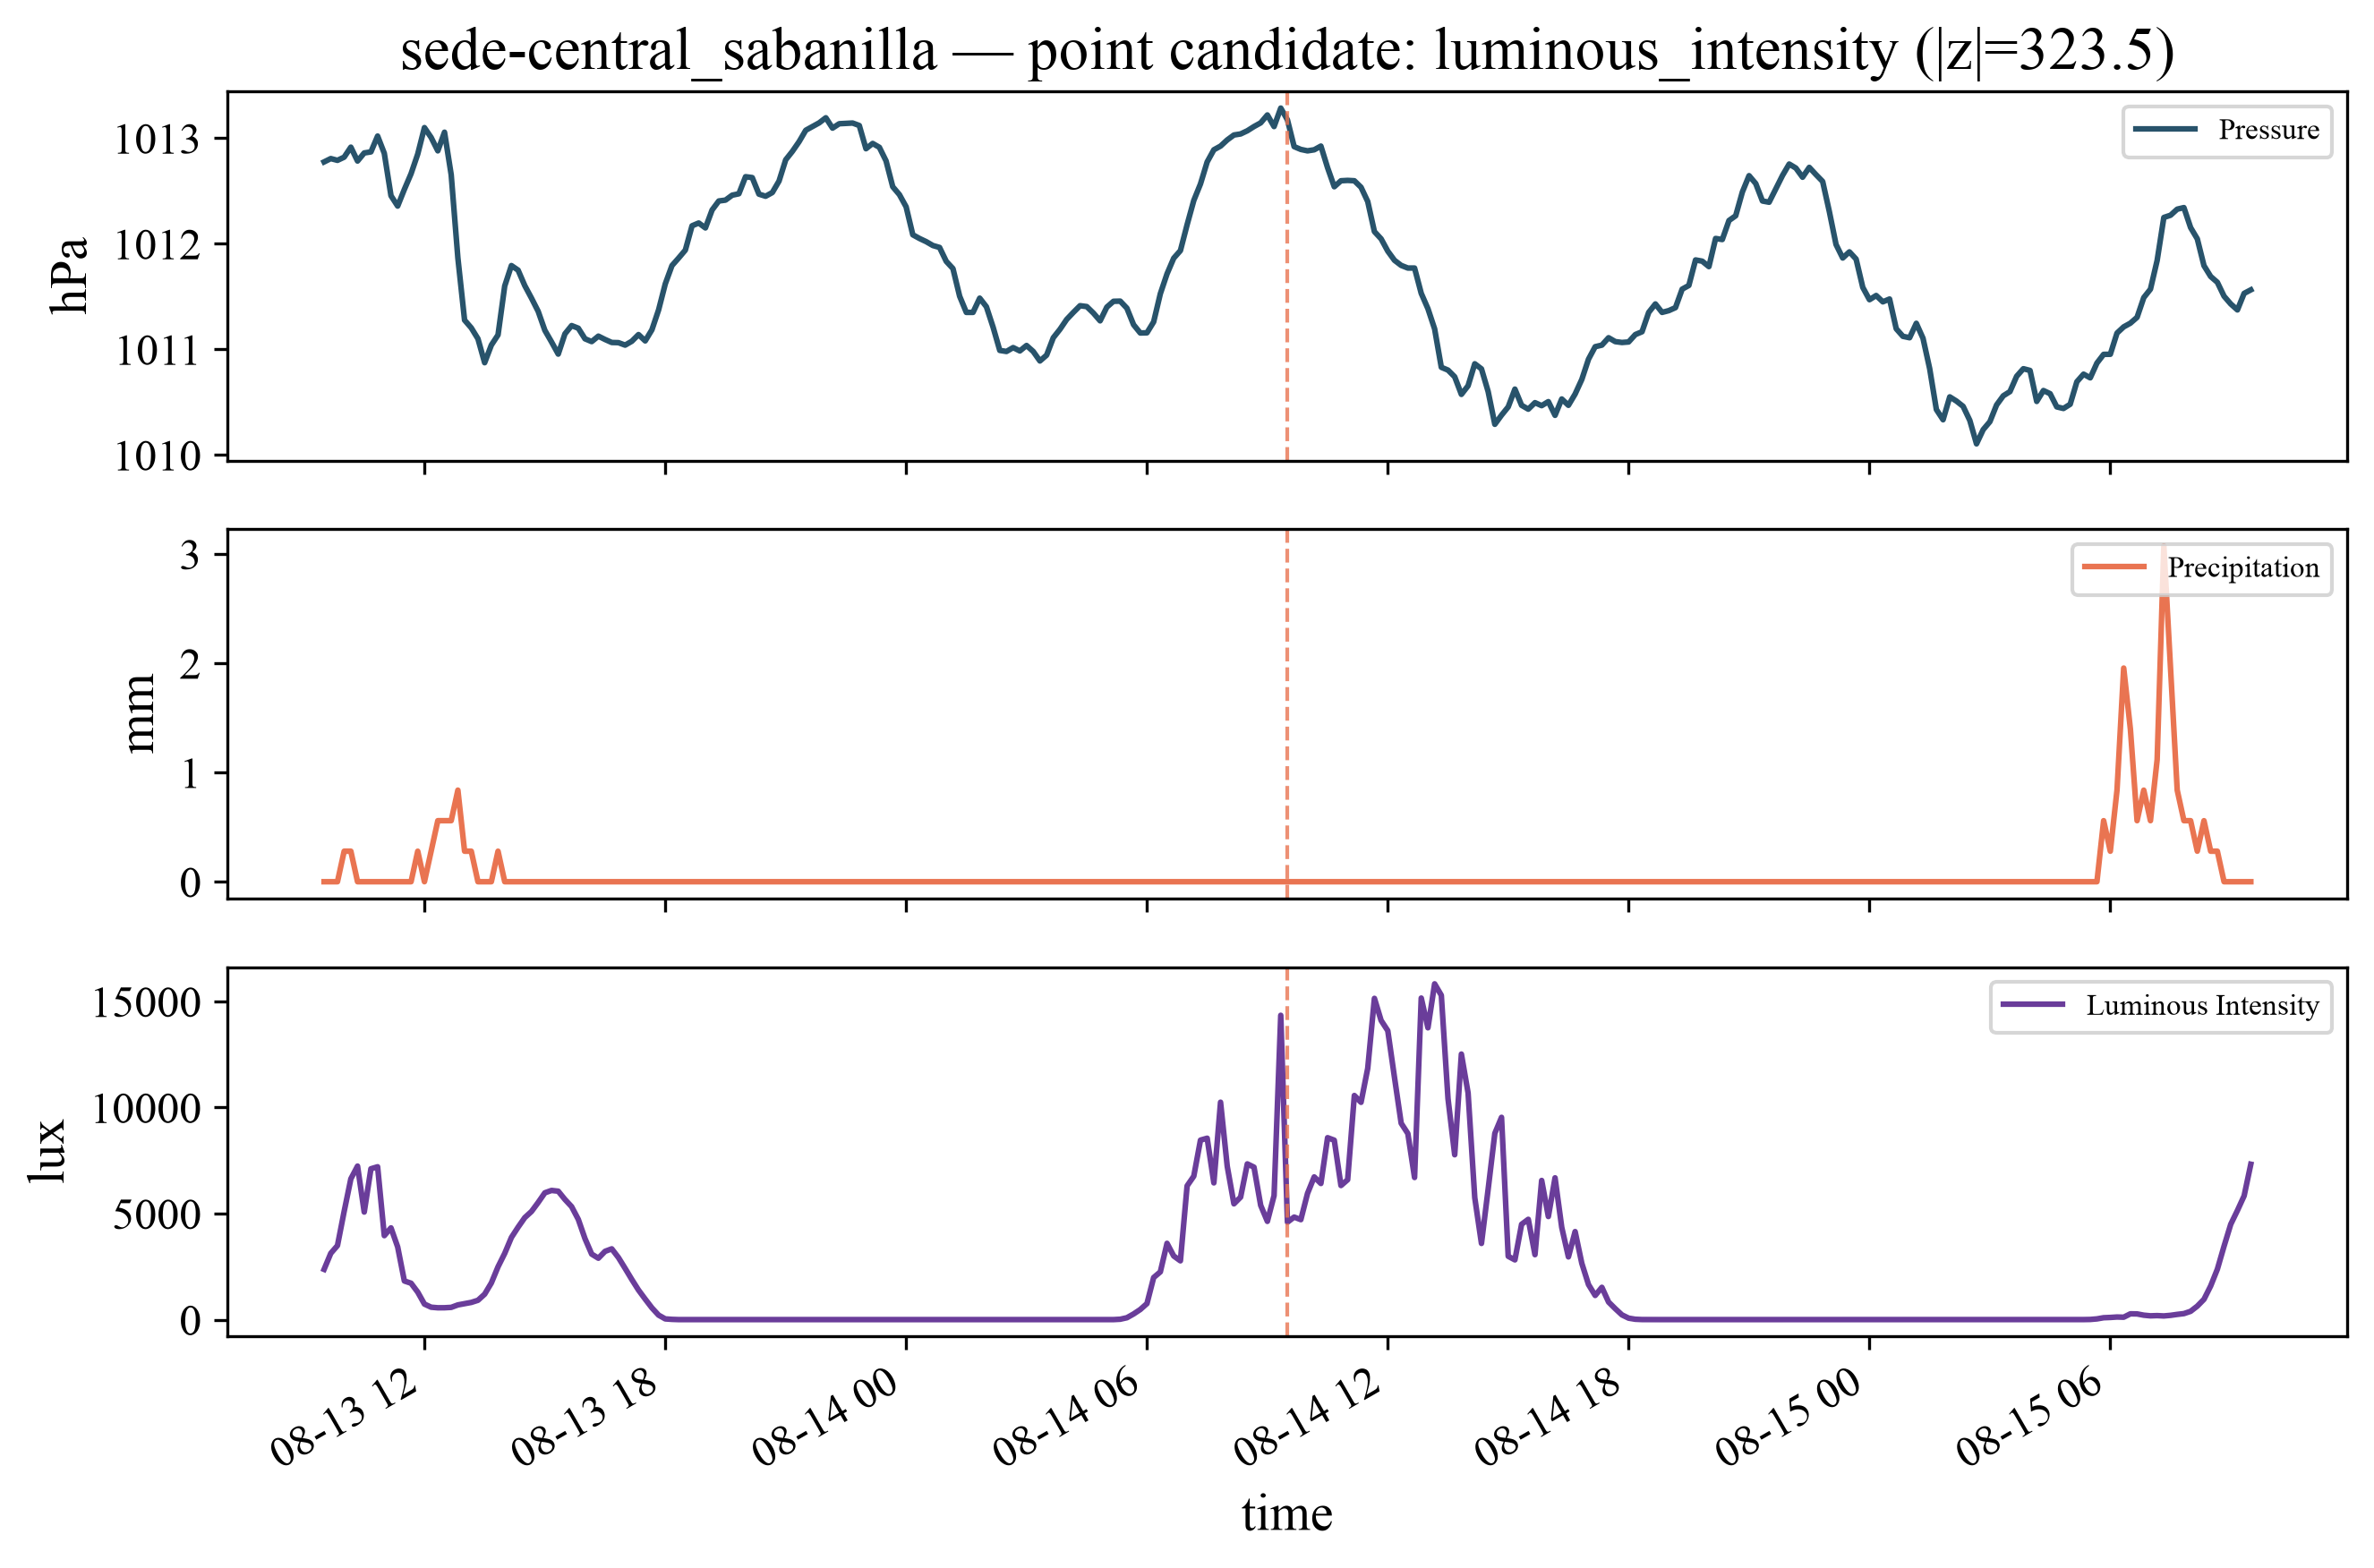

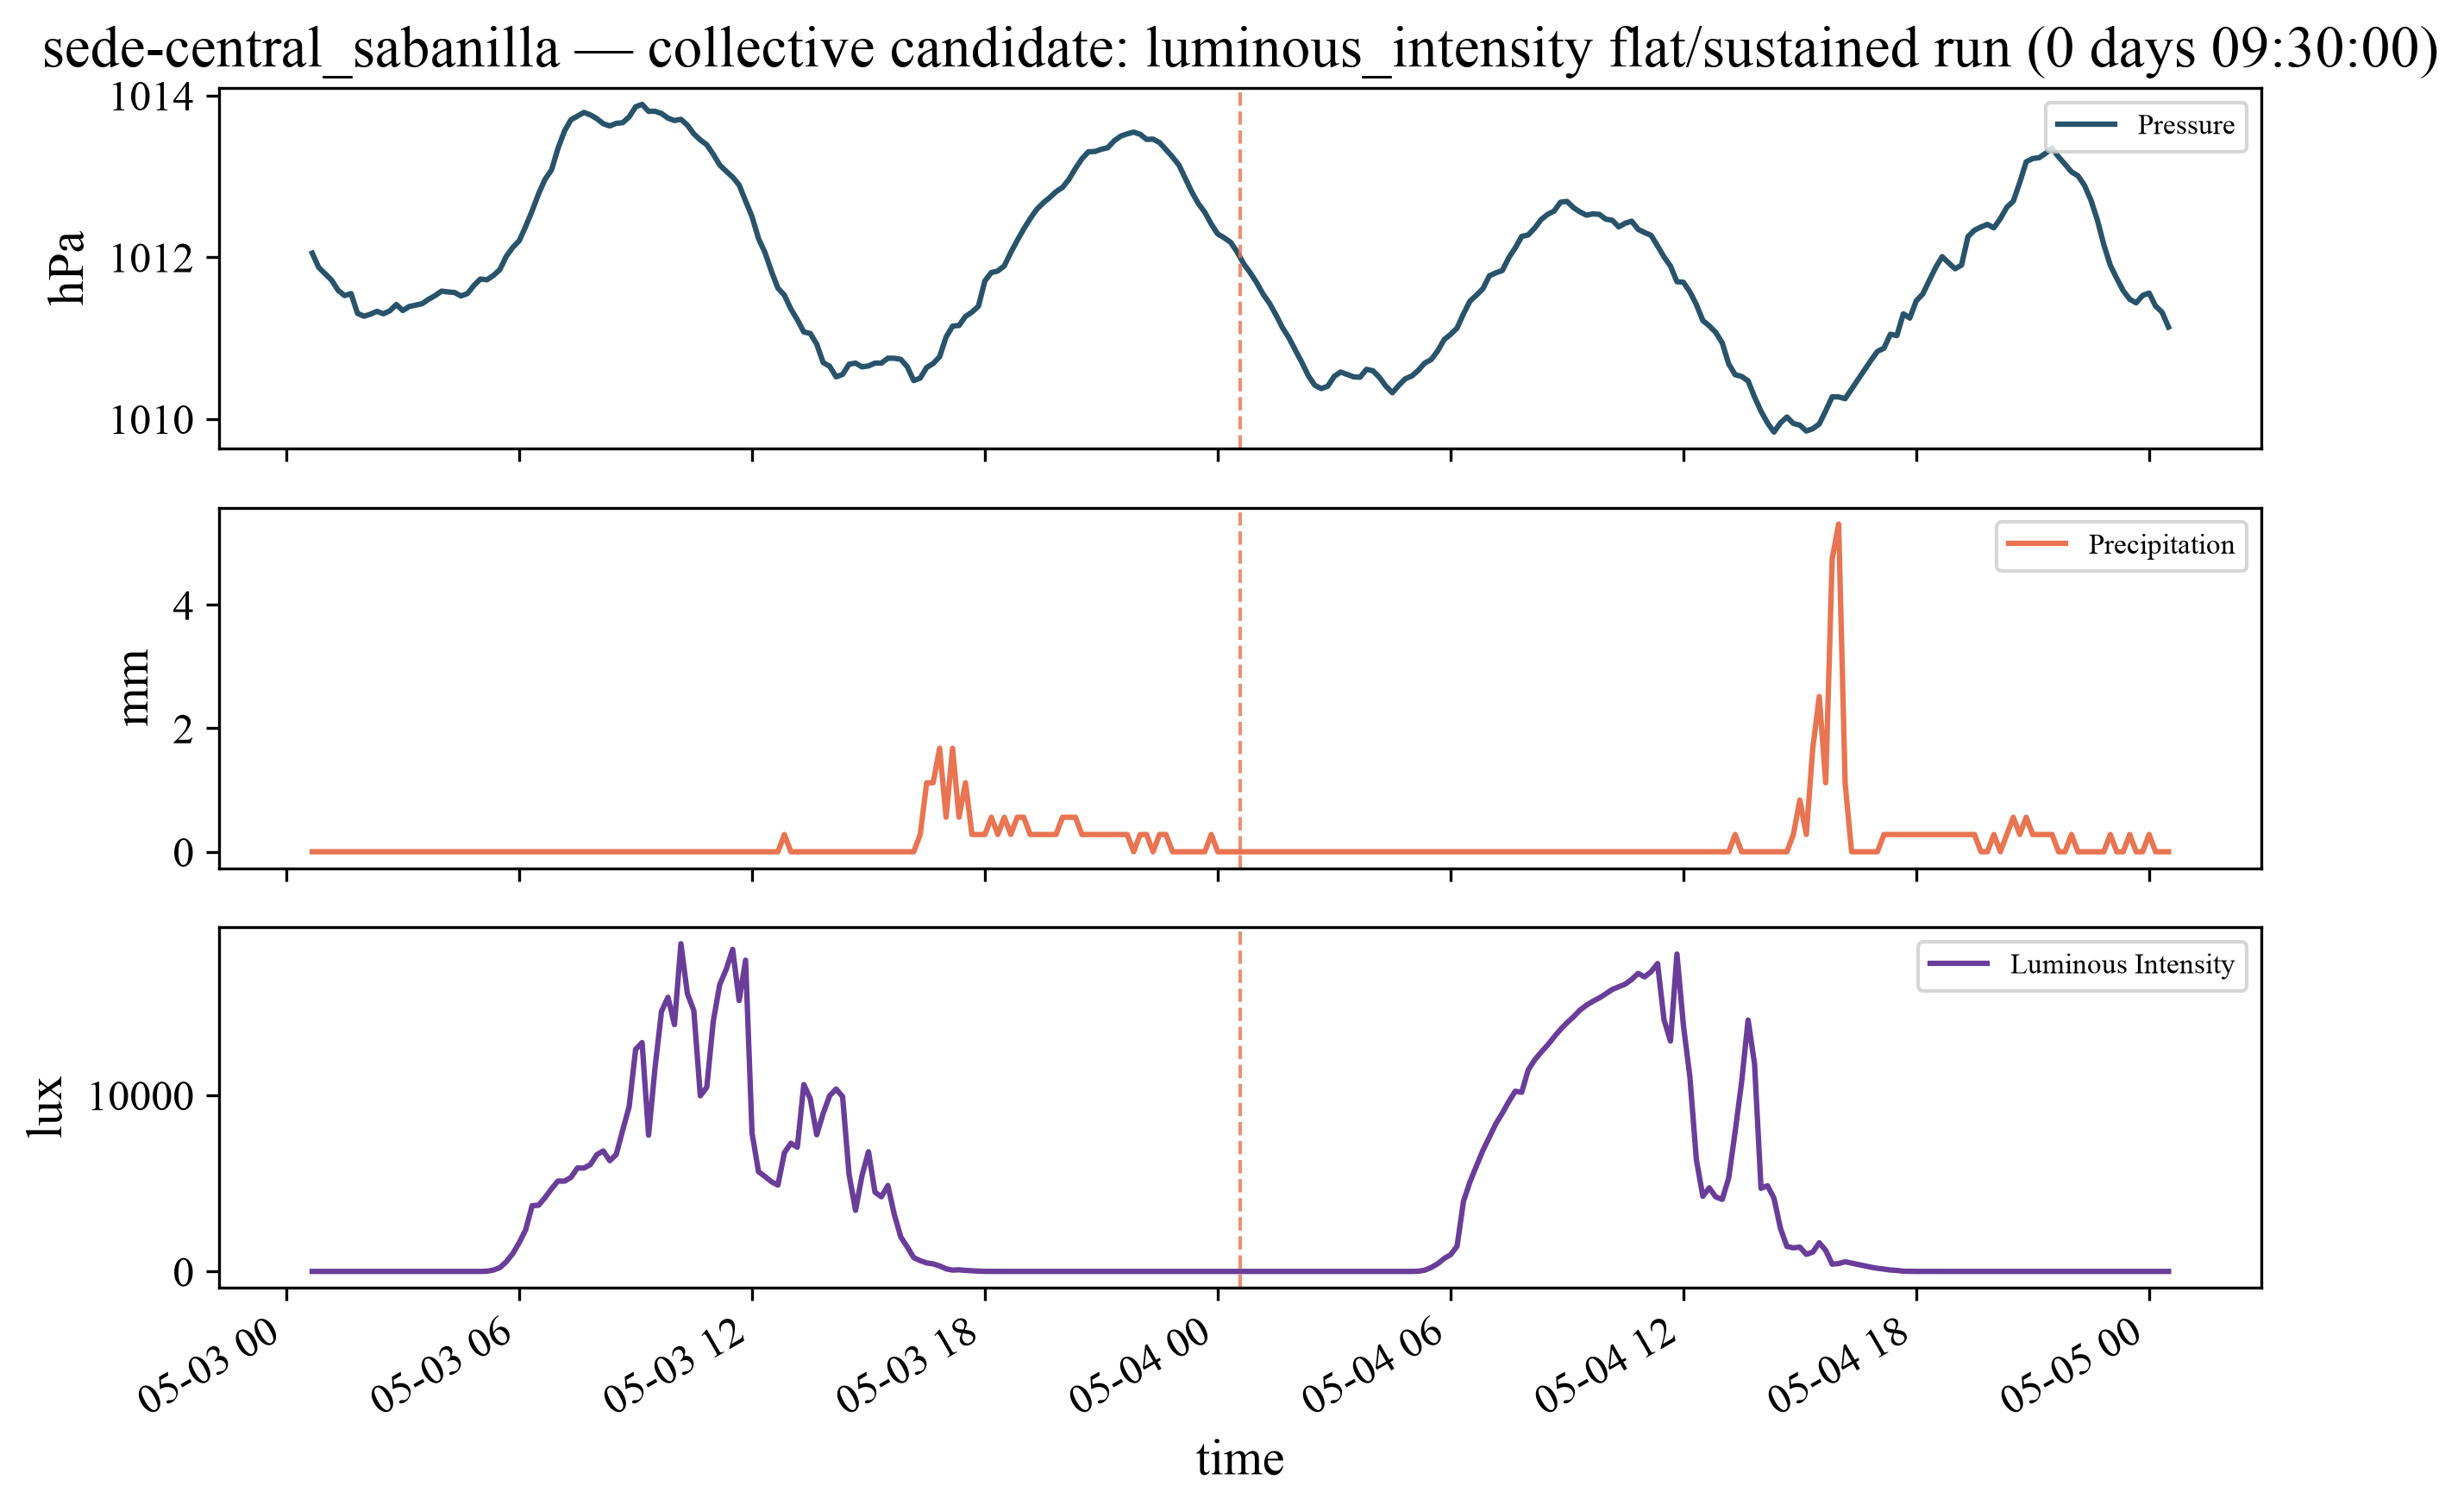

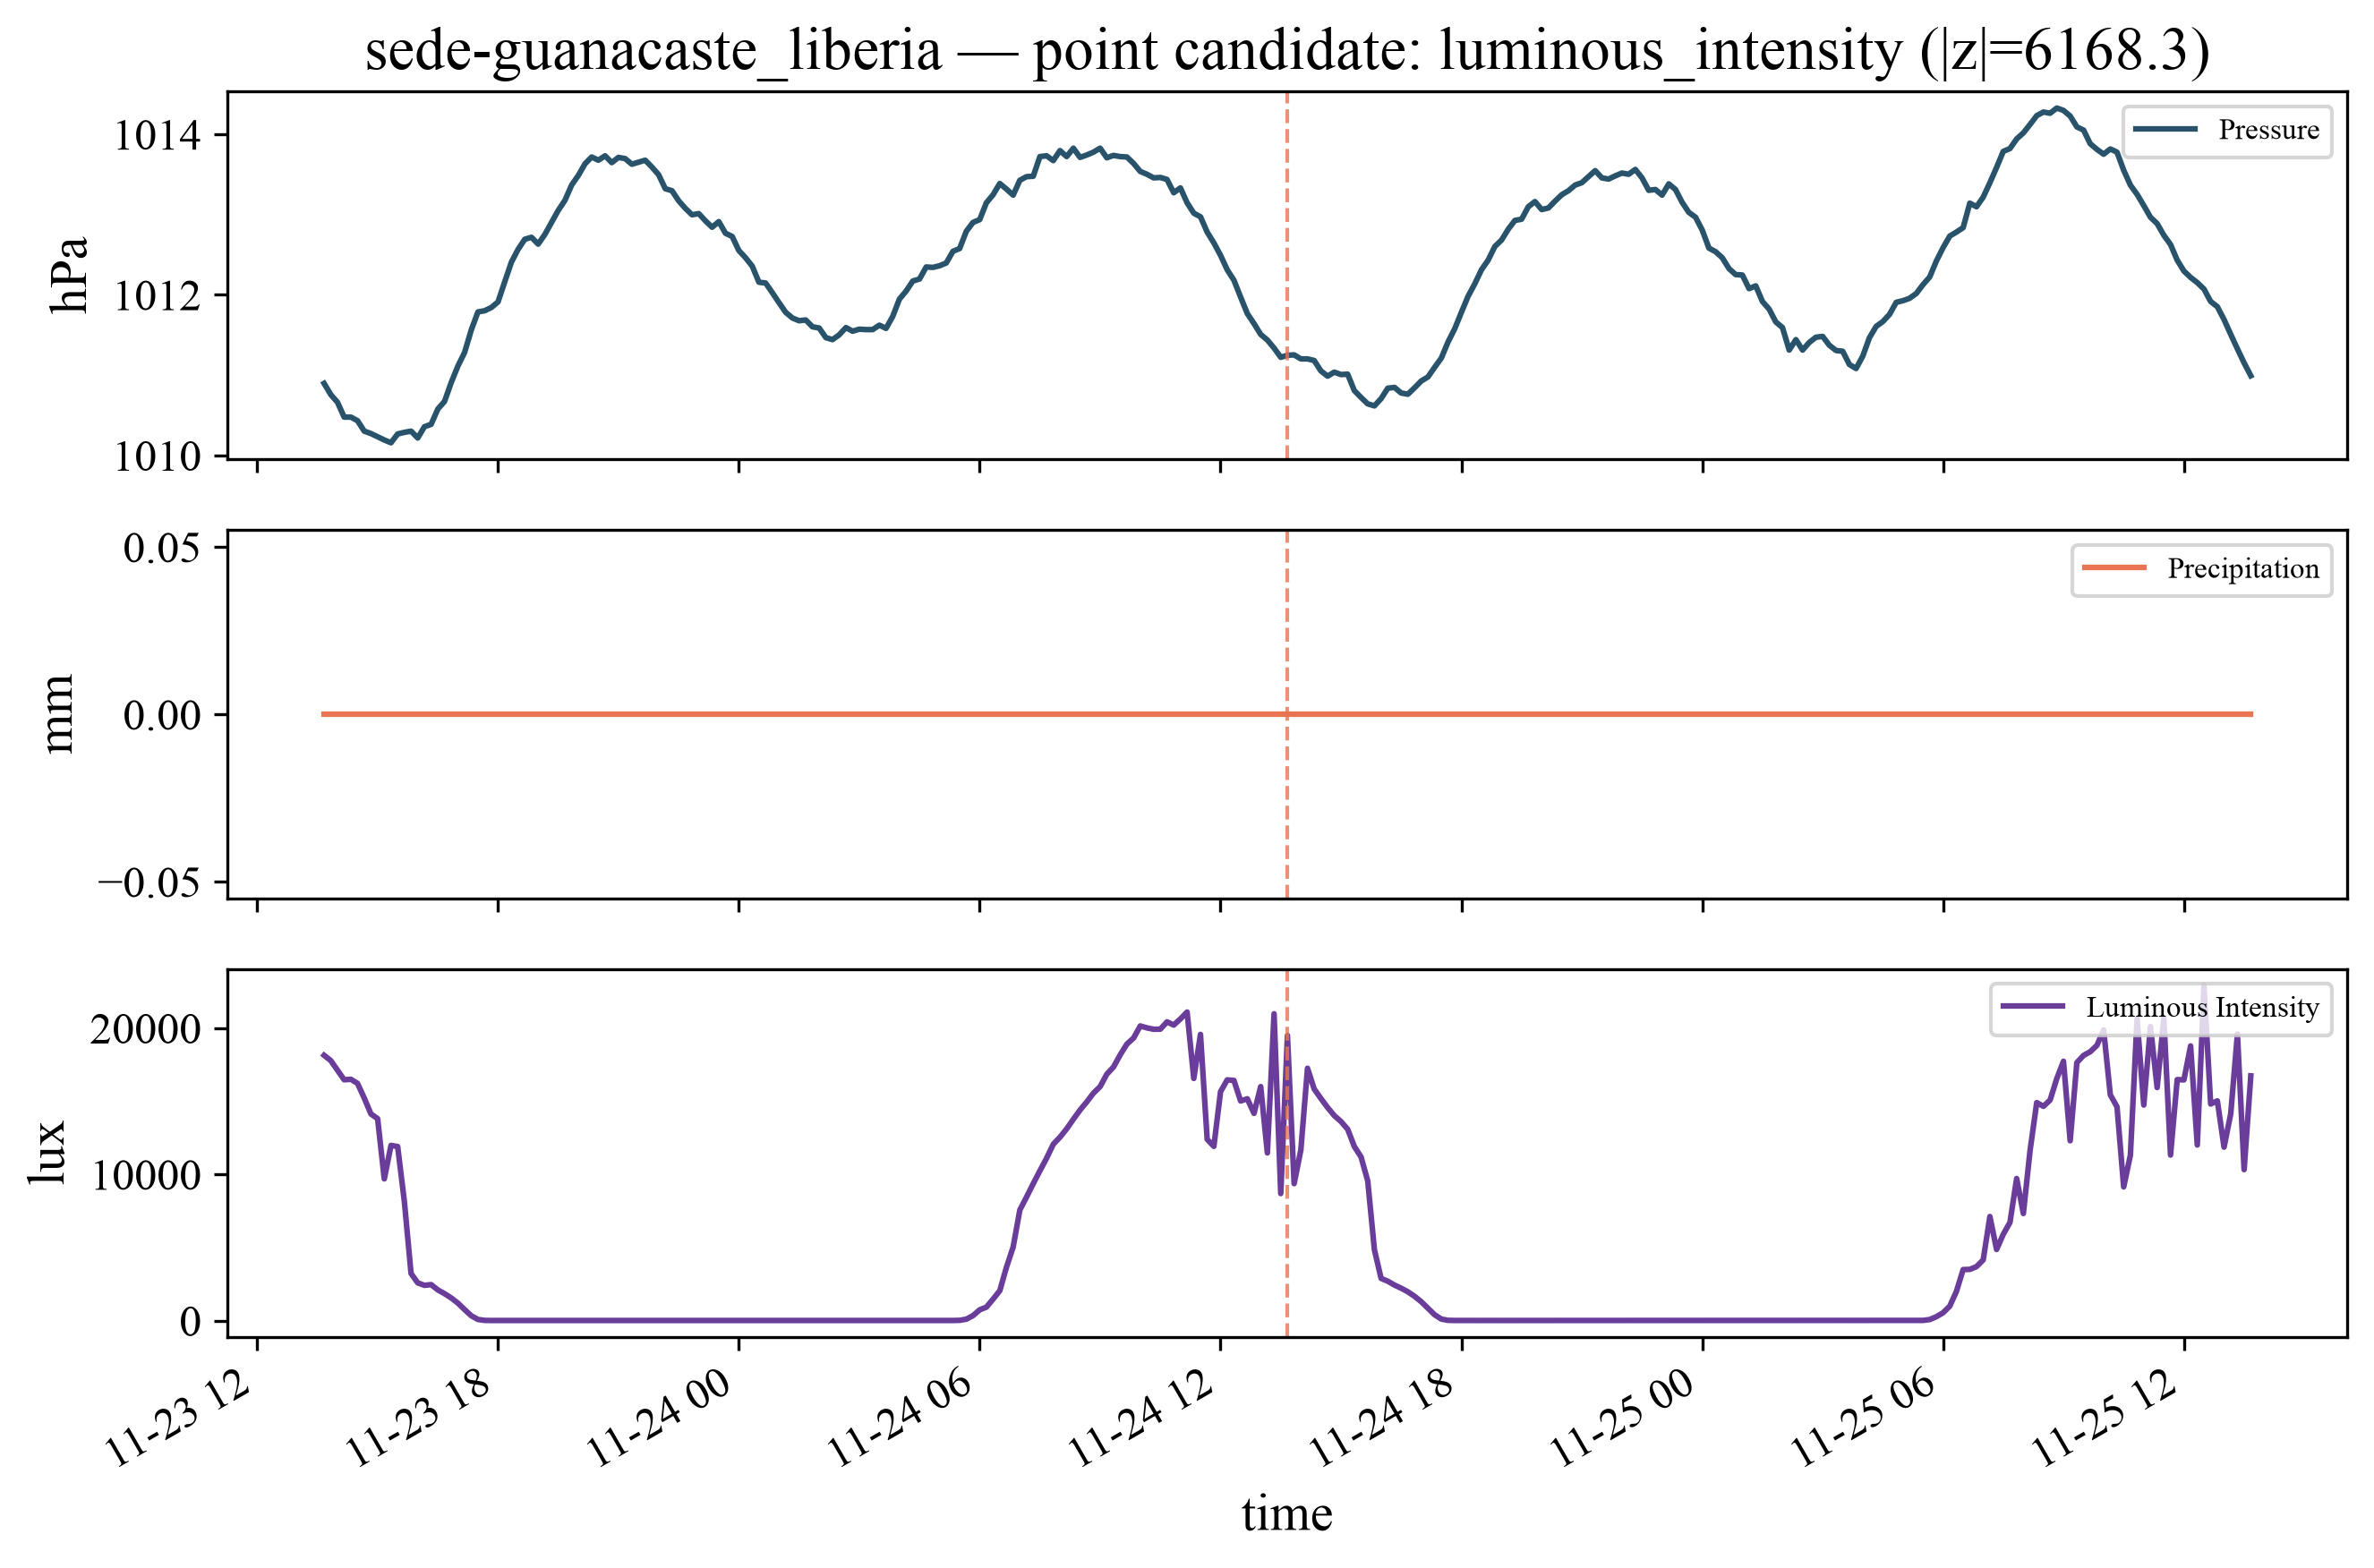

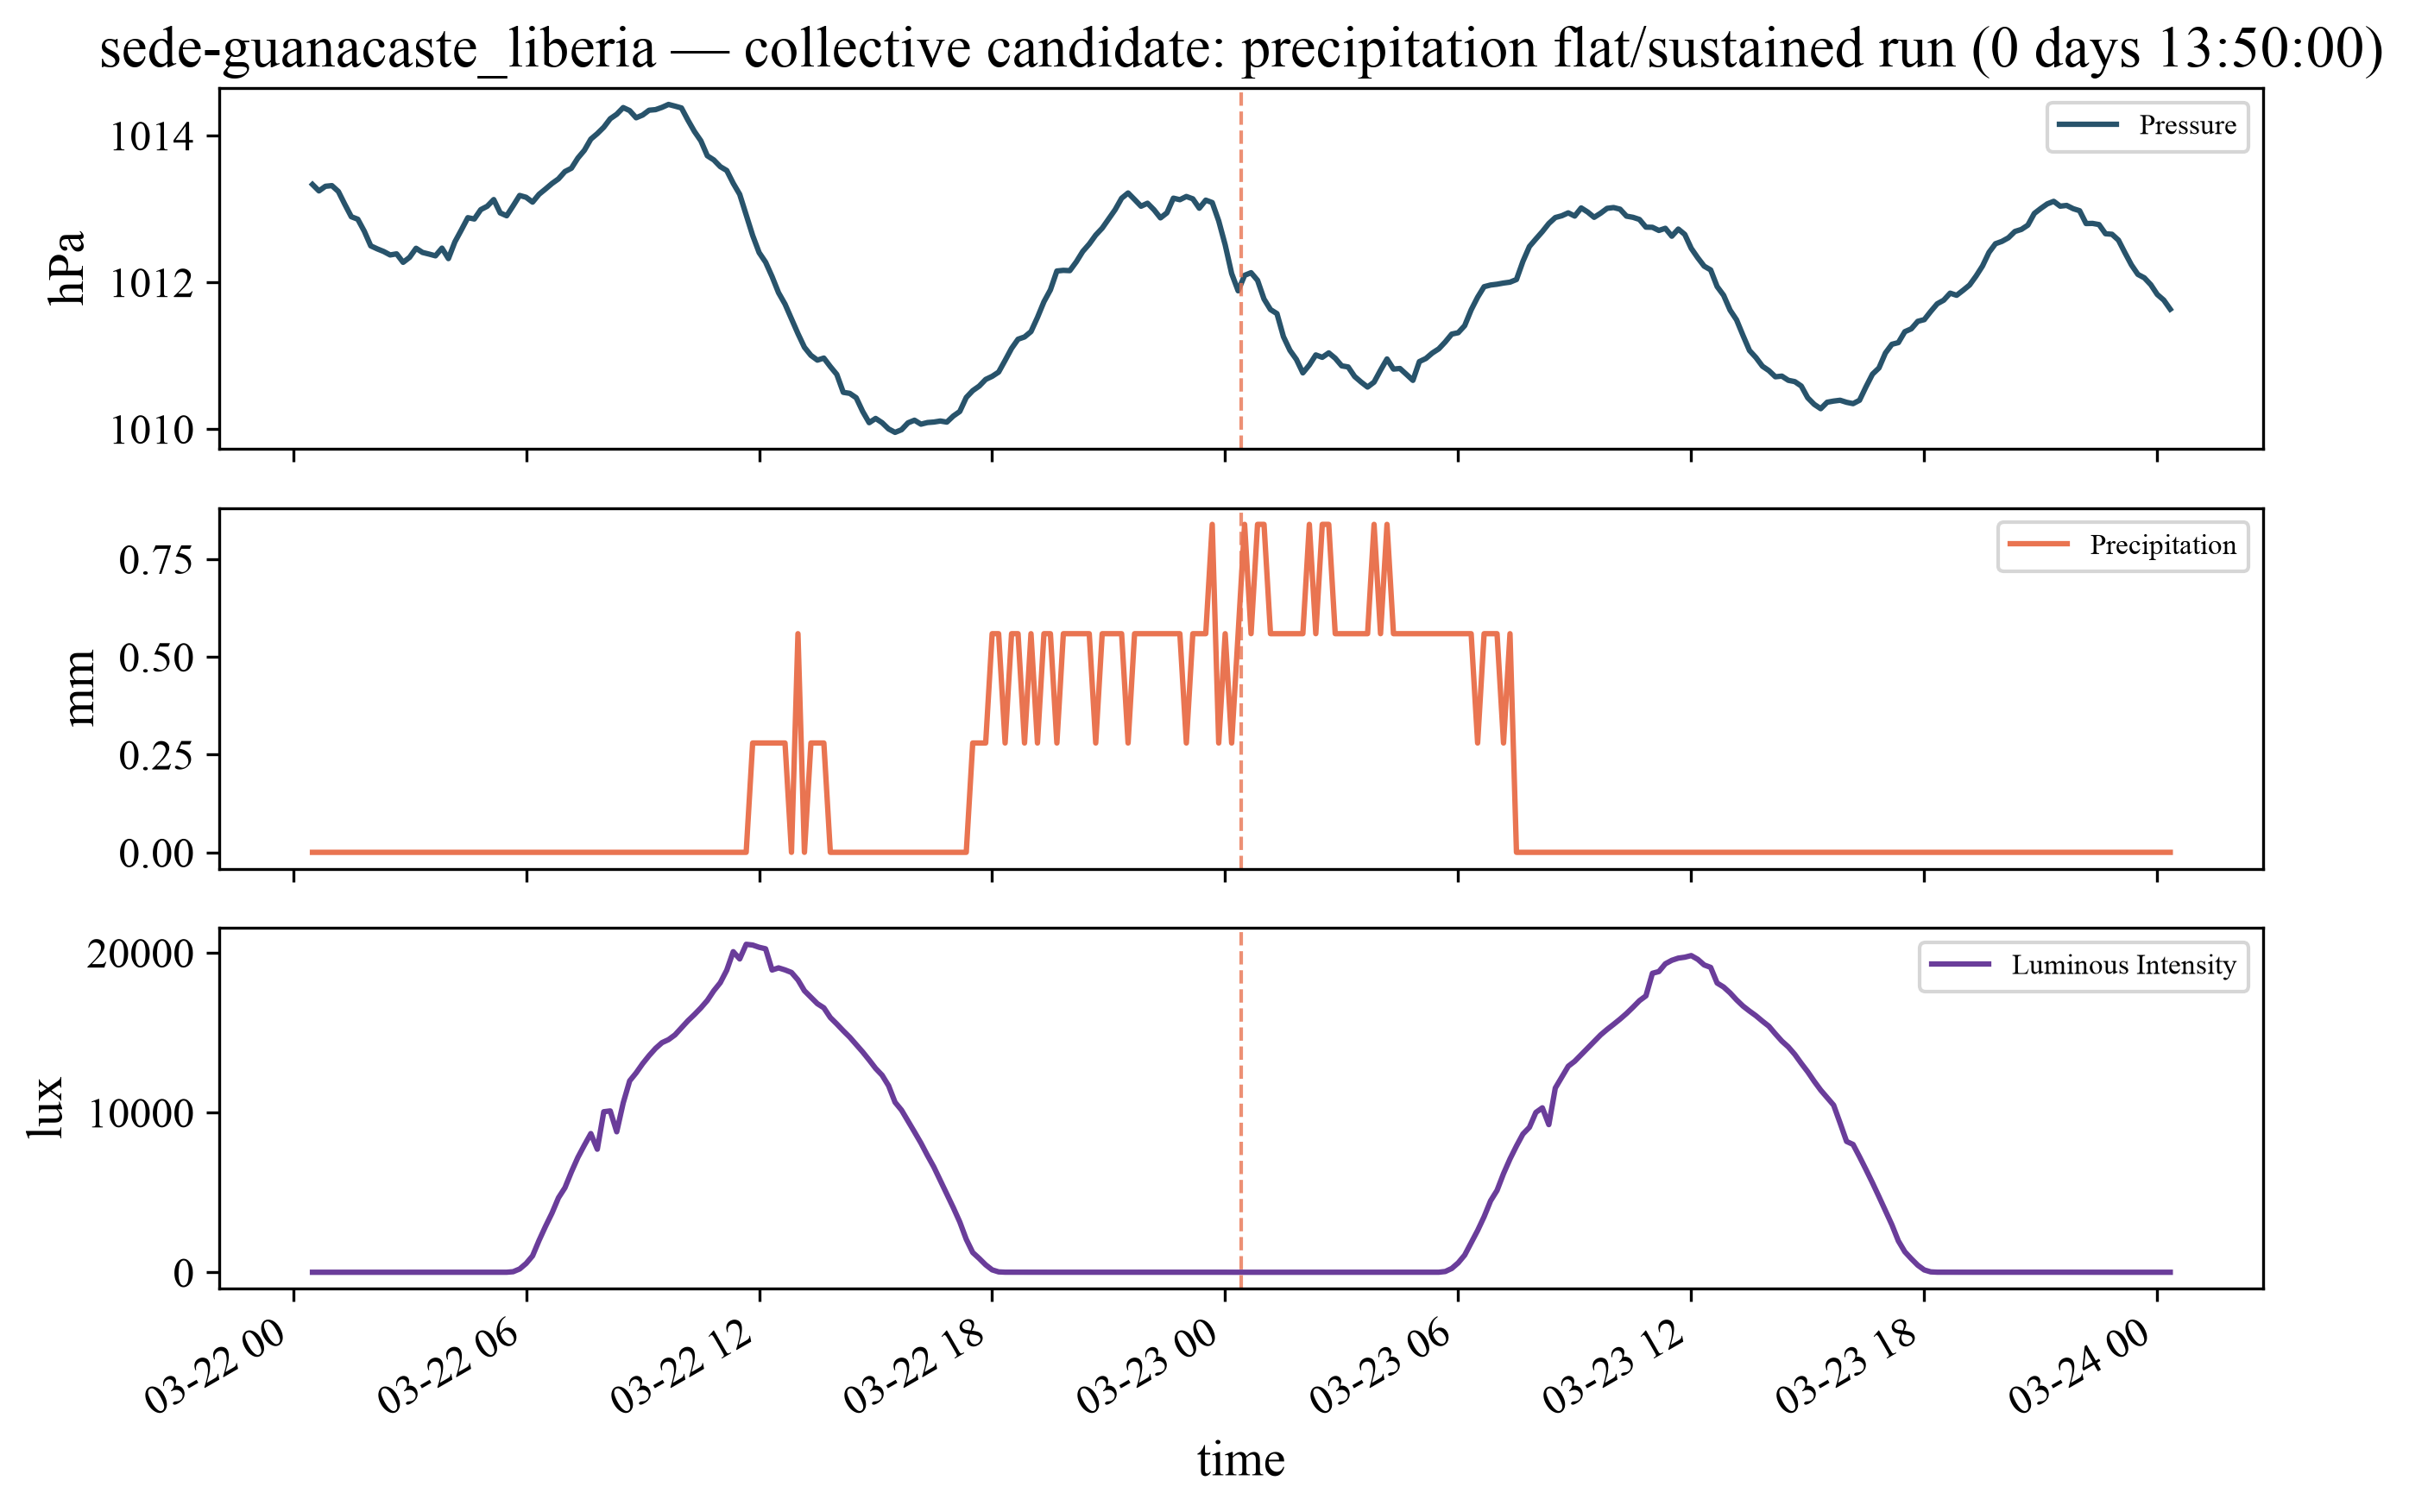

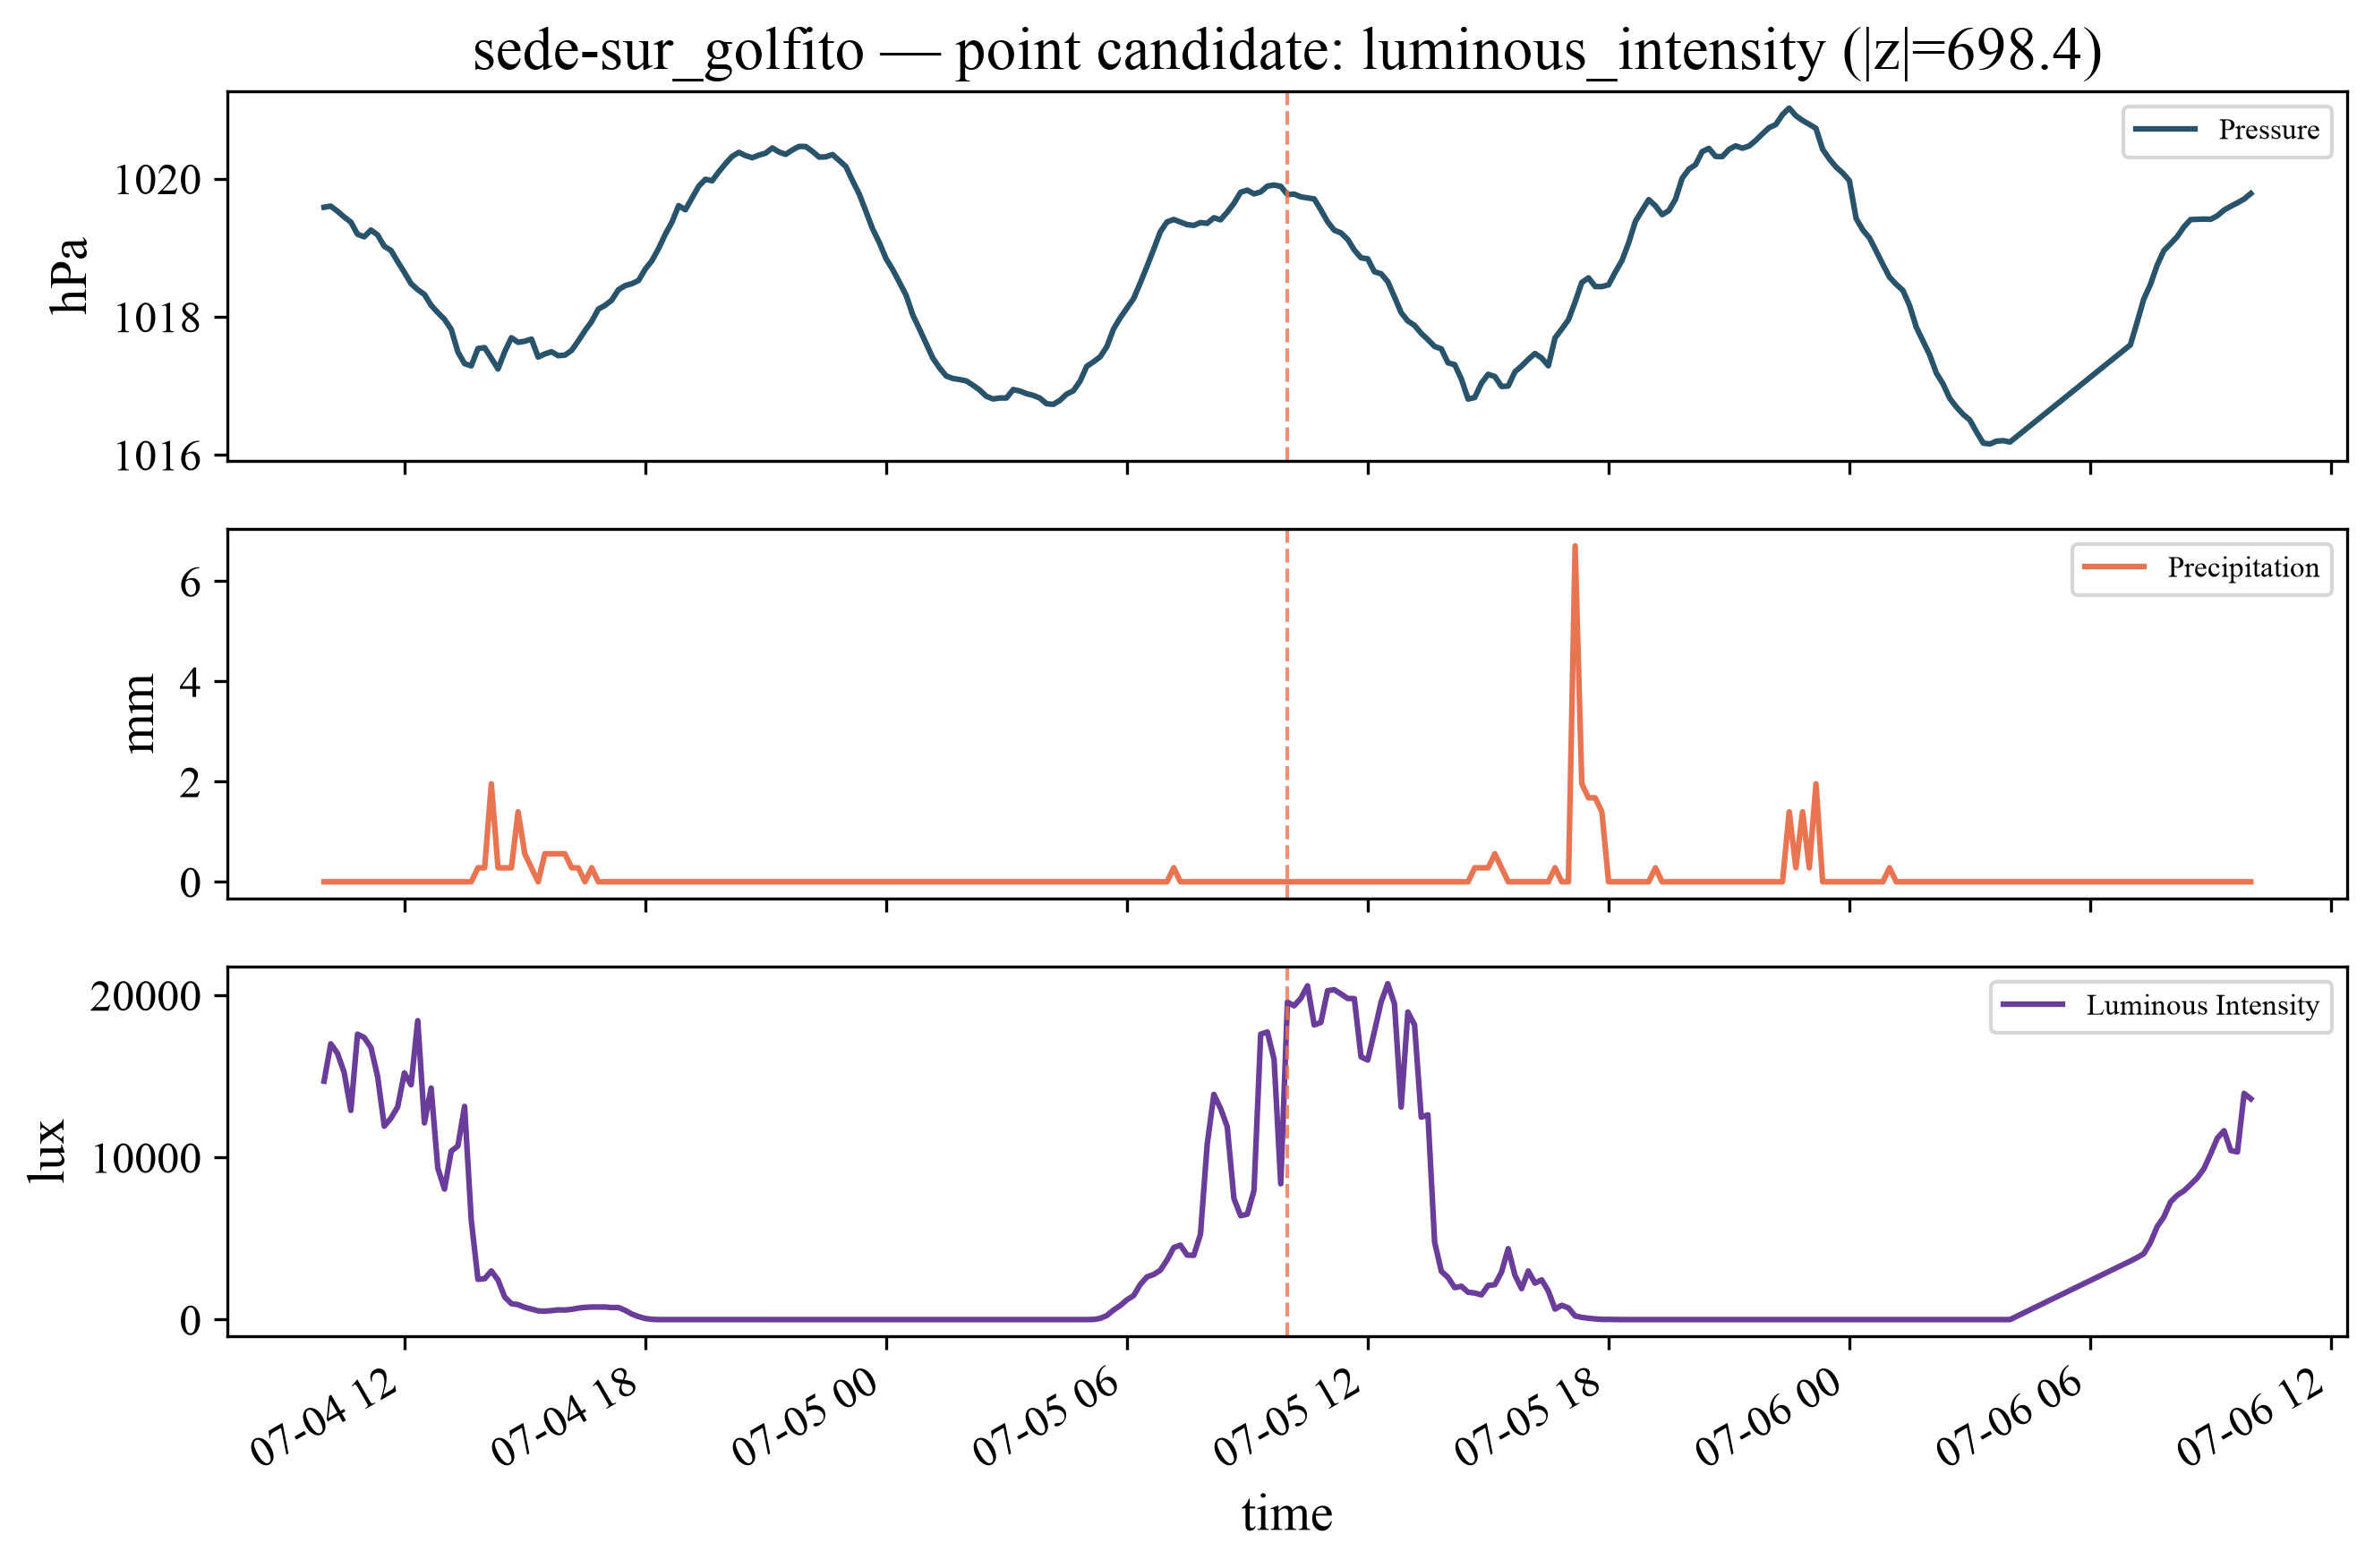

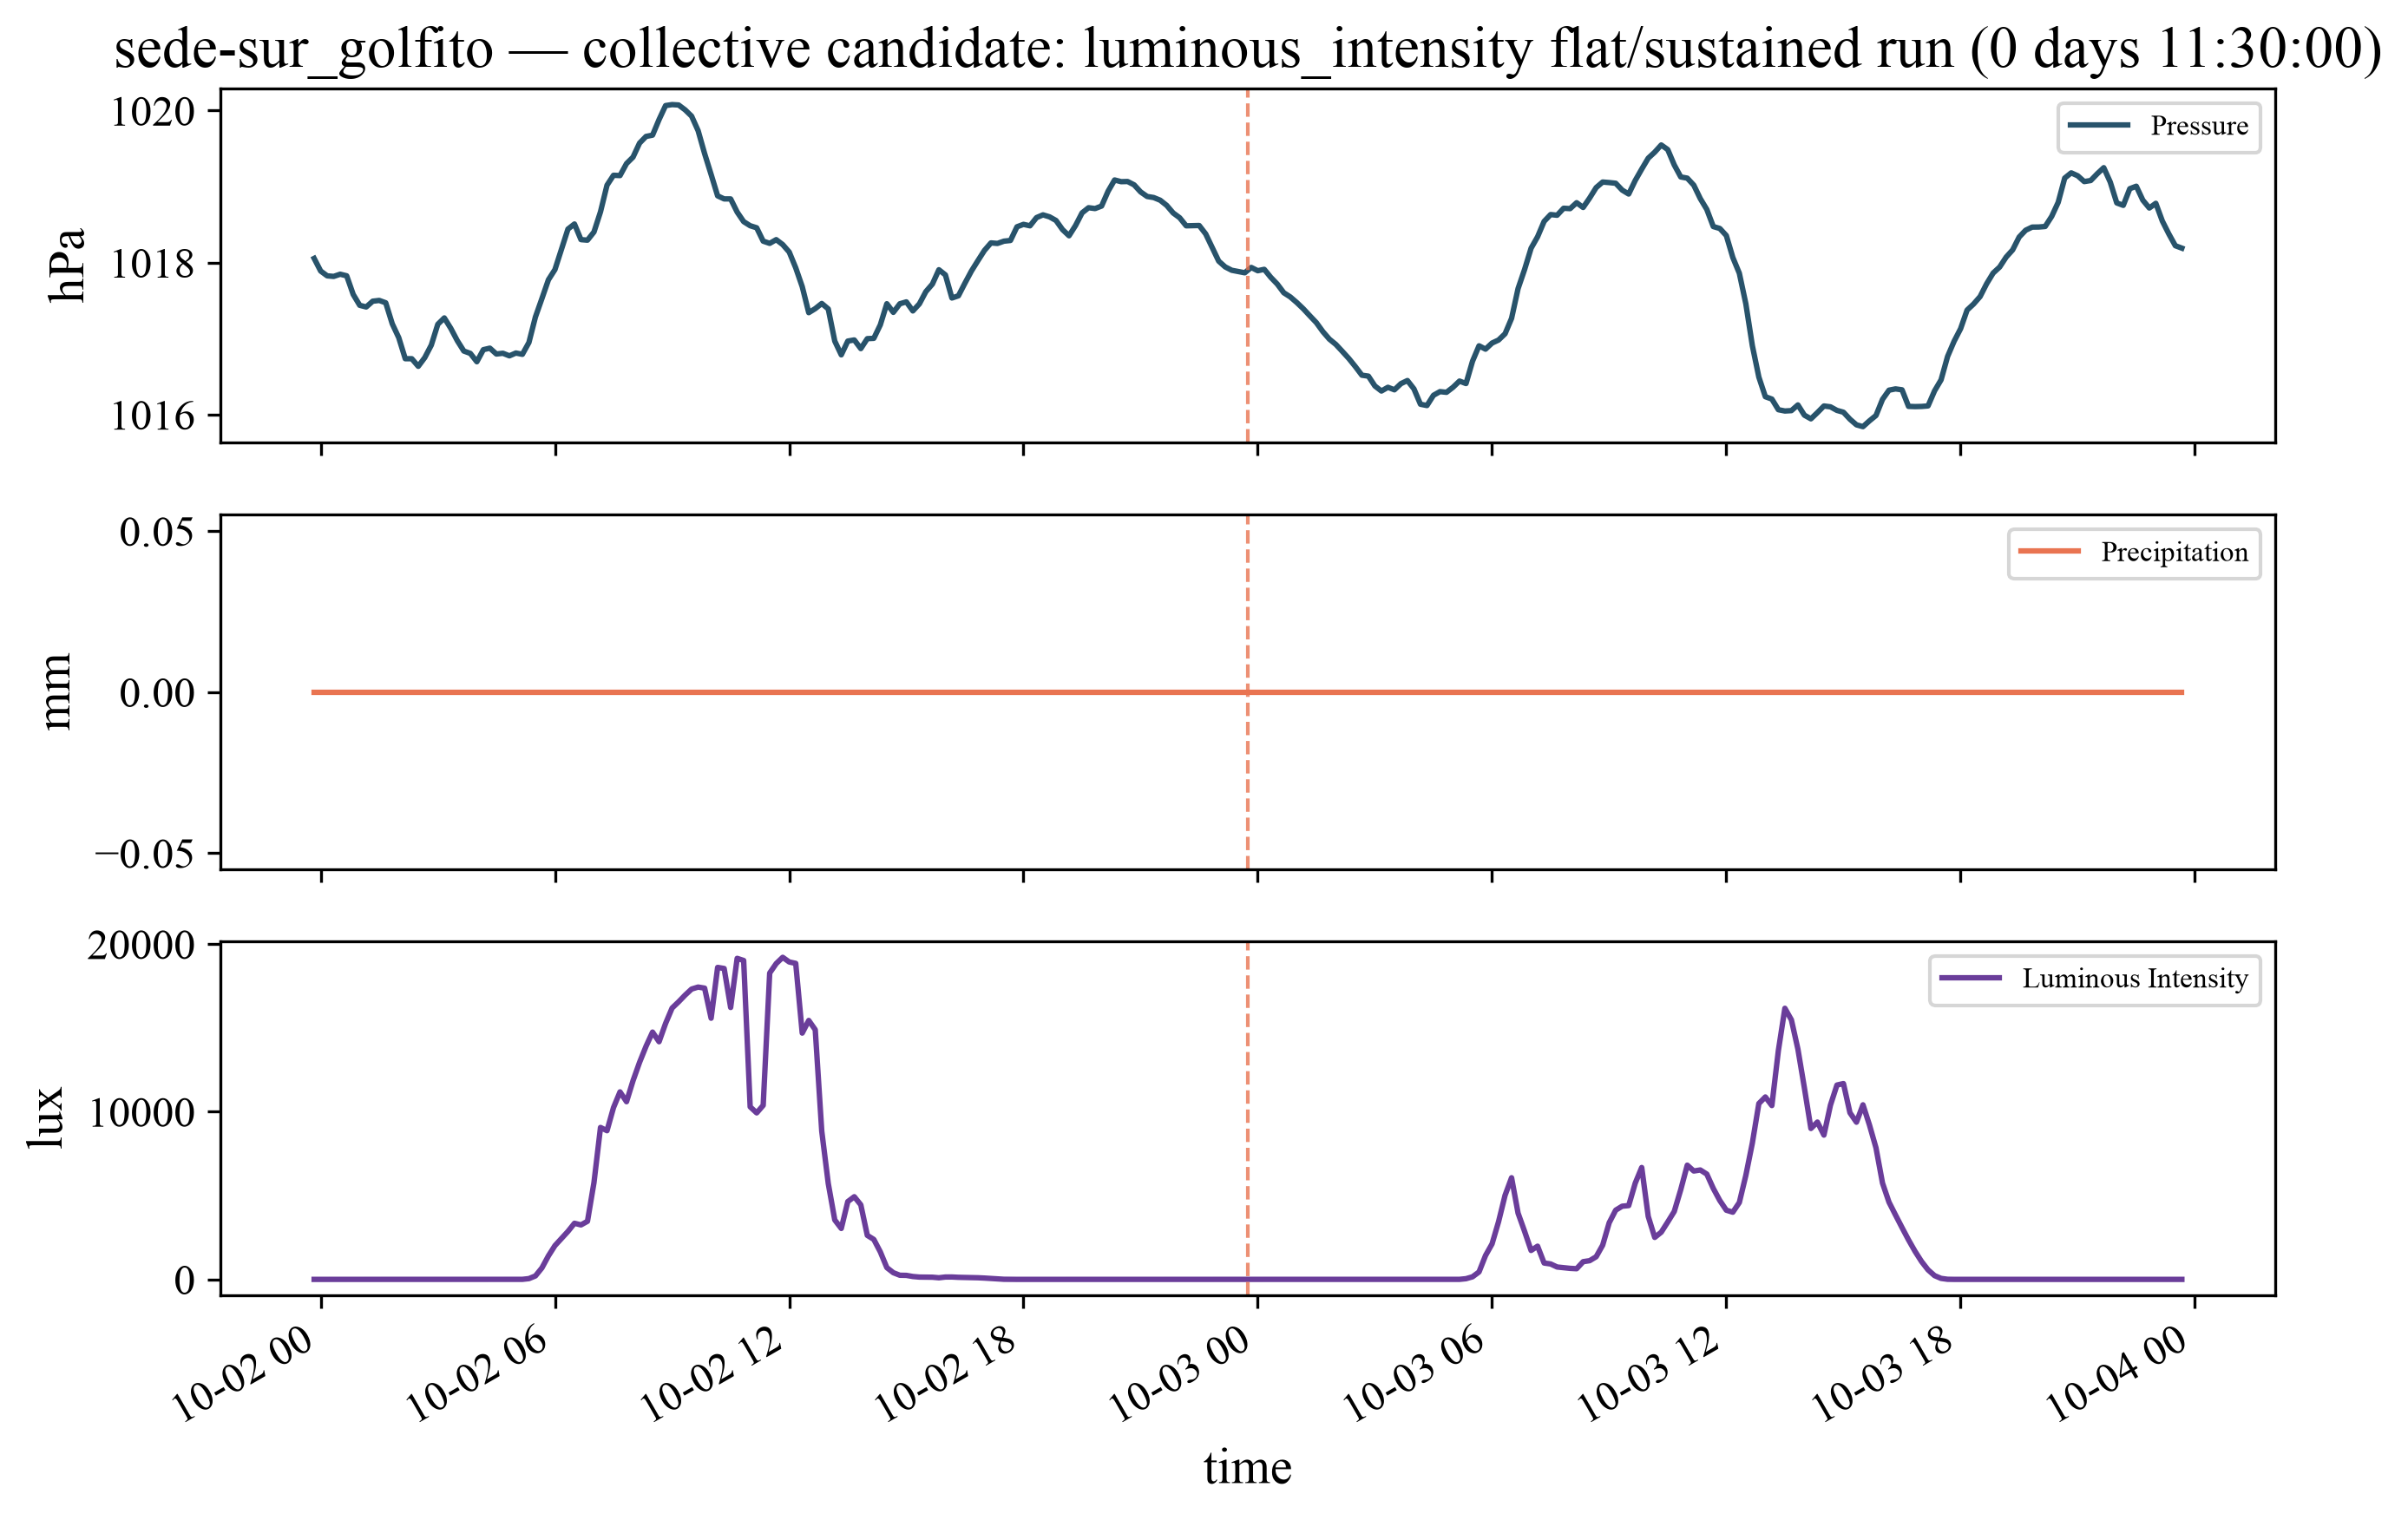

In [5]:
def plot_episode(station: str, df10: pd.DataFrame, center: pd.Timestamp, label: str, half_span=pd.Timedelta("24h")):
    window = df10.loc[center - half_span: center + half_span]
    fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
    cols = ["pressure", "precipitation", "luminous_intensity"]
    units = {"pressure": "hPa", "precipitation": "mm", "luminous_intensity": "lux"}
    for ax, col, color_name in zip(axes, cols, PALETTE_ORDER):
        ax.plot(window.index, window[col], color=PALETTE[color_name], label=pretty_label(col))
        ax.axvline(center, color=PALETTE["burnt_sienna"], linestyle="--", linewidth=1, alpha=0.8)
        ax.set_ylabel(units[col])
        ax.legend(loc="upper right", fontsize=8)
    axes[0].set_title(f"{station} — {label}")
    axes[-1].set_xlabel("time")
    fig.autofmt_xdate()
    fig.tight_layout()
    return fig


for station, ep in episodes.items():
    df10 = ep["frame"]
    if ep["point"]:
        p = ep["point"]
        plot_episode(station, df10, p["time"], f"point candidate: {p['column']} (|z|={abs(p['z']):.1f})")
        plt.show()
    if ep["collective"]:
        c = ep["collective"]
        mid = c["start"] + c["duration"] / 2
        plot_episode(station, df10, mid, f"collective candidate: {c['column']} flat/sustained run ({c['duration']})")
        plt.show()


Reading the plots above: for each station, the **point** panel should
show one channel spiking or dropping for a single bin with neighbors back at
baseline (matching the point criteria above); the **collective** panel
should show a multi-hour flat plateau or, for `precipitation`, a long
sustained nonzero run, with no single bin in that stretch looking unusual on
its own. Where a candidate instead looks like an ordinary data gap edge or a
real, plausible weather transition, that is itself useful information — not
every automatically-ranked candidate will actually match its intended
criterion, and that mismatch will matter for interpreting Step 6/7 later.


## Criteria summary

| Variable | Anomaly type | Criterion | Provisional example |
|---|---|---|---|
| `pressure` | Point | Single-bin deviation from trailing 6h rolling mean by several robust SDs, neighbors back at baseline | Largest robust-z second-difference step, `pressure` column, per station (table above) |
| `pressure` | Contextual | Normal marginal value but missing the expected ~3.3-4.5h inverse-lagged response to `luminous_intensity` (only trustworthy under ~5% post-fill missing) | Not auto-detected here — requires a lag-aware scan, deferred to Step 6/7 |
| `pressure` | Collective/temporal | Sustained multi-hour trend steeper/longer than the station's historical rate-of-change distribution, no single step abnormal | Longest 3h-flat run *or* — if a drift, not a plateau, is present — visible in the point-candidate plot's surrounding window |
| `precipitation` | Point | Single bin's mm value far outside the station's historical max, with no plausible build/decay around it | Largest single-bin `precipitation` value inconsistent with surrounding bins (visible in episode plots when it dominates the panel) |
| `precipitation` | Contextual | Daytime nonzero bin not accompanied by the expected simultaneous `luminous_intensity` drop (criterion much weaker/unusable at night) | Not auto-detected here — requires cross-referencing lux at the same timestamp, deferred to Step 6/7 |
| `precipitation` | Collective/temporal | Sustained run of small nonzero bins with atypical total duration, no single bin's value abnormal | Longest consecutive-nonzero run, per station (table above) |
| `luminous_intensity` | Point | Extreme outlier in the full 24h-pooled marginal distribution, isolated (neighbors back at prior level) | Largest robust-z `diff()` step, `luminous_intensity` column, per station (table above) |
| `luminous_intensity` | Contextual | Value unremarkable in the full distribution but wrong for its specific hour (e.g. mid-range at solar noon or midnight) | Not auto-detected here — requires an hour-of-day-conditioned scan, deferred to Step 6/7 |
| `luminous_intensity` | Collective/temporal | Multi-hour flat plateau missing the normal diurnal rise/fall envelope, no single reading abnormal | Longest 3h-flat run, per station (table above); likely overlaps `sede-central_finca-2`'s known pre-2025-05-20 dead-sensor period |

This table is the actual deliverable of this notebook.


## What this notebook does *not* confirm

None of the criteria above are validated here, and this notebook cannot do
so on its own:

- The three **contextual** criteria (marked "not auto-detected" in the
  summary table) are stated but not illustrated with an automatically-found
  example — a proper contextual scan needs an hour-of-day/lag-conditioned
  detector, which is exactly what Step 6 builds. Nothing here should be read
  as evidence a contextual anomaly of this shape actually exists at any
  station.
- The point/collective provisional examples are simple magnitude/duration
  rankings on raw data, not the output of Z-score, LOF, Isolation Forest,
  Autoencoder, or LSTM/GRU — whether the real detectors actually flag these
  same episodes, flag different ones, or disagree with each other on them is
  unknown until Step 6 builds all five and Step 7 compares their outputs
  against the predictions stated above.
- Because there is no emergency-alert or other label data in this project
  (confirmed in the recap), there is no ground truth this notebook — or
  Step 7 — can check detector output against for "real event vs. false
  positive." What Step 7 *can* check is internal consistency: does each
  detector family flag the kinds of episodes its criterion predicts, and
  does it plausibly miss the kinds it isn't built to catch. That is the only
  validation this line of work supports, and it is deferred entirely to
  Step 7, not attempted here.
